# RETAIL DEMAND FORECASTING

#### by Santhi Prasanna Peesa

Retail is a cornerstone of the global economy, influencing consumer behavior, regional economies, and business strategies. Predicting future sales for a company is one of the most important aspects of strategic planning. This project focuses on understanding and modeling the complexities of retail sales, such as the impact of holidays, markdown events, and regional variations, all of which play critical roles in shaping sales trends.

From a data science perspective, retail datasets provide an excellent opportunity to apply diverse analytical techniques, including time series analysis, feature engineering, and predictive modeling. These datasets encapsulate real-world challenges, making them invaluable for enhancing technical and problem-solving skills.


### Introduction 

In the retail industry, one of the most significant challenges faced by chain stores is effective supply chain management. A critical component involves determining the best way to meet the requirements generated from demand planning. The objective is to balance supply and demand in a way that aligns with the financial and service goals of the organization.

If decision-makers can accurately forecast weekly or monthly product demand, they can optimize supply chain operations. This includes reducing overstocking, minimizing waste, and planning logistics more efficiently. Achieving this would lead to substantial cost savings and improved operational efficiency for the organization.

### Project Motivation

This project involves analyzing a rich dataset containing historical sales data for 45 Walmart stores from 2010 to 2012. The data includes weekly sales figures, markdown events, and external factors such as fuel prices, unemployment rates, and CPI (Consumer Price Index). These variables provide a holistic view of how internal and external factors influence sales performance, offering a chance to explore the following:

### Key Aspects

#### Time Series Analysis:
Examining temporal trends, seasonality, and patterns in weekly sales.

#### Store Performance Evaluation:
Identifying the best-performing stores and understanding factors driving their success.

#### Predictive Modeling:
Using techniques such as SARIMAX, multiple linear regression, Lasso Regression and Gradient Boosting Trees to forecast weekly sales at the department and store level.

#### Detailed Factor Analysis:
Assessing the impact of external variables like CPI, unemployment, and fuel prices on sales.
The inclusion of markdown events and holiday sales adds a layer of complexity to the analysis, reflecting real-world scenarios where strategic decisions hinge on limited historical data and evolving market dynamics.

## UNDERSTANDING DATA

There are 3 Datasets 

#### Stores:

- Store: The store number. Range from 1–45.
- Type: Three types of stores ‘A’, ‘B’ or ‘C’.
- Size: Sets the size of a Store would be calculated by the no. of products available in the particular store ranging from 34,000 to 210,000.

primary key is Store

#### Sales:

- Date: The date of the week where this observation was taken.

- Weekly_Sales: The sales recorded during that Week.

- Store: The store which observation in recorded 1–45

- Dept: One of 1–99 that shows the department.

- IsHoliday: Boolean value representing a holiday week or not.

primary key is a combination of (Store,Dept,Date).

#### Features:

- Temperature: Temperature of the region during that week.

- Fuel_Price: Fuel Price in that region during that week.

- MarkDown1:5 : Represents the Type of markdown and what quantity was available during that week.

- CPI: Consumer Price Index during that week.

- Unemployment: The unemployment rate during that week in the region of the store.

primary key here is a combination of (Store,Date)

## DATA IMPORTING AND QUERYING

I will load all 3 datasets and merge them  into one big dataset that gives whole data. 

In [1]:
import itertools
import numpy as np
import scipy.stats as stats
import warnings
warnings.filterwarnings("ignore")
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import calendar
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn import metrics
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso, LinearRegression, LassoCV
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsRegressor
from statsmodels.tsa.seasonal import seasonal_decompose
import statsmodels.api as sm
import random
import sqlite3
from itertools import cycle, islice
from sklearn.ensemble import GradientBoostingRegressor
# Import timedelta from datetime library
from datetime import timedelta


ss = StandardScaler()

In [2]:
# Define data source locations
sales_history_path = r'C:\Users\91939\Downloads\walmart-recruiting-store-sales-forecasting\train.csv'
market_factors_path = r'C:\Users\91939\Downloads\walmart-recruiting-store-sales-forecasting\features.csv'
outlet_details_path = r'C:\Users\91939\Downloads\walmart-recruiting-store-sales-forecasting\stores.csv'

# Load datasets
historical_sales = pd.read_csv(sales_history_path)
market_factors = pd.read_csv(market_factors_path)
outlet_details = pd.read_csv(outlet_details_path)

# Display initial rows of the main dataset
print("Retail Sales Historical Data Preview:")
historical_sales.head()

Retail Sales Historical Data Preview:


,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


In [3]:
# Display summary statistics of the market factors dataset
print("\nMarket Factors Dataset Summary:")
market_factors.head()


Market Factors Dataset Summary:


,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,2010-02-12,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,2010-02-19,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,2010-02-26,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,2010-03-05,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False


In [4]:
print("\nOutlet Details Overview:")
outlet_details.sample(5)


Outlet Details Overview:


,Store,Type,Size
38,39,A,184109
9,10,B,126512
33,34,A,158114
17,18,B,120653
36,37,C,39910


In [5]:
historical_sales.shape

(421570, 5)

### Grouping data by Store

Since I'm only intrested in predicting weekly Store level sales I will group the dataframes such that Department level data gets eliminated and aggregate department level sales to give the store level sales.

In [6]:
sales_by_outlet_date = historical_sales.groupby(["Store", "Date"])["Weekly_Sales"].sum()
sales_summary = sales_by_outlet_date.reset_index()

#### Merging all the datasets into one for easier analysis.

In [7]:
# Merge sales summary with outlet details
combined_data = pd.merge(
    sales_summary,
    outlet_details,
    how='inner',
    on='Store',
    suffixes=('_sales', '_outlet')
)

# Further merge with market factors
final_dataset = pd.merge(
    combined_data,
    market_factors,
    how='inner',
    on=['Store', 'Date'],
    suffixes=('', '_market')
)

In [8]:
final_dataset.shape

(6435, 15)

The dataframe with 421570 rows has come down to 6435 rows after group by and merge

## DATA CLEANING

In [9]:
final_dataset.head()

,Store,Date,Weekly_Sales,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,2010-02-05,1643690.90,A,151315,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,2010-02-12,1641957.44,A,151315,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,2010-02-19,1611968.17,A,151315,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,2010-02-26,1409727.59,A,151315,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,2010-03-05,1554806.68,A,151315,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False


#### Some basic encoding and feature Extraction


This is only basic level for our initial EDA. Later, I will be doing Feature engineering as required by the analyses methods.

In [10]:
# Encoding the holiday indicator as its categorical: yes/ No

from sklearn.preprocessing import LabelEncoder

holiday_encoder = LabelEncoder()
final_dataset['Holiday_Flag'] = holiday_encoder.fit_transform(final_dataset['IsHoliday'])

# Display the first few rows of the encoded column
print("\nHoliday Encoding Preview:")
print(final_dataset[['IsHoliday', 'Holiday_Flag']].head(10))


Holiday Encoding Preview:
   IsHoliday  Holiday_Flag
0      False             0
1       True             1
2      False             0
3      False             0
4      False             0
5      False             0
6      False             0
7      False             0
8      False             0
9      False             0


In [11]:
# Checking the date column is in object format or datetime
final_dataset.dtypes

Store             int64
Date             object
Weekly_Sales    float64
Type             object
Size              int64
Temperature     float64
Fuel_Price      float64
MarkDown1       float64
MarkDown2       float64
MarkDown3       float64
MarkDown4       float64
MarkDown5       float64
CPI             float64
Unemployment    float64
IsHoliday          bool
Holiday_Flag      int64
dtype: object

In [12]:
#Drop the original IsHoliday column
final_dataset.drop('IsHoliday', axis=1, inplace=True)

In [13]:
#Convert Date column to datetime
final_dataset["Date"] = pd.to_datetime(final_dataset.Date)

#Extract temporal features
final_dataset["Day"] = final_dataset['Date'].dt.day
final_dataset["Month"] = final_dataset['Date'].dt.month
final_dataset['Year'] = final_dataset['Date'].dt.year
final_dataset['Week'] = final_dataset.Date.dt.isocalendar().week

#Convert month numbers to abbreviated names for further analysis
final_dataset['Month'] = final_dataset['Month'].apply(lambda x: calendar.month_abbr[x])
print("\nTemporal features preview:")
print(final_dataset[['Date', 'Day', 'Month', 'Year', 'Week']].head())


Temporal features preview:
        Date  Day Month  Year  Week
0 2010-02-05    5   Feb  2010     5
1 2010-02-12   12   Feb  2010     6
2 2010-02-19   19   Feb  2010     7
3 2010-02-26   26   Feb  2010     8
4 2010-03-05    5   Mar  2010     9


In [14]:
# looking into the null values
final_dataset.isnull().sum()

Store              0
Date               0
Weekly_Sales       0
Type               0
Size               0
Temperature        0
Fuel_Price         0
MarkDown1       4155
MarkDown2       4798
MarkDown3       4389
MarkDown4       4470
MarkDown5       4140
CPI                0
Unemployment       0
Holiday_Flag       0
Day                0
Month              0
Year               0
Week               0
dtype: int64

##### More Than 65% of value are missing in MarkDown values

In [15]:
final_dataset.describe()

,Store,Date,Weekly_Sales,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Holiday_Flag,Day,Year,Week
count,6435.000000,6435,6.435000e+03,6435.000000,6435.000000,6435.000000,2280.000000,1637.000000,2046.000000,1965.000000,2295.000000,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000,6435.0
mean,23.000000,2011-06-17 00:00:00,1.046965e+06,130287.600000,60.663782,3.358607,6855.587430,3218.965504,1349.853021,3303.858142,4435.262240,171.578394,7.999151,0.069930,15.678322,2010.965035,25.818182
min,1.000000,2010-02-05 00:00:00,2.099862e+05,34875.000000,-2.060000,2.472000,0.270000,-265.760000,-29.100000,0.220000,135.160000,126.064000,3.879000,0.000000,1.000000,2010.000000,1.0
25%,12.000000,2010-10-08 00:00:00,5.533501e+05,70713.000000,47.460000,2.933000,1679.190000,37.200000,4.700000,483.270000,1702.565000,131.735000,6.891000,0.000000,8.000000,2010.000000,14.0
50%,23.000000,2011-06-17 00:00:00,9.607460e+05,126512.000000,62.670000,3.445000,4972.590000,187.040000,22.700000,1419.420000,3186.520000,182.616521,7.874000,0.000000,16.000000,2011.000000,26.0
75%,34.000000,2012-02-24 00:00:00,1.420159e+06,202307.000000,74.940000,3.735000,8873.582500,1785.290000,99.987500,3496.080000,5422.080000,212.743293,8.622000,0.000000,23.000000,2012.000000,38.0
max,45.000000,2012-10-26 00:00:00,3.818686e+06,219622.000000,100.140000,4.468000,88646.760000,104519.540000,141630.610000,67474.850000,108519.280000,227.232807,14.313000,1.000000,31.000000,2012.000000,52.0
std,12.988182,NaN,5.643666e+05,63117.022465,18.444933,0.459020,8183.310015,9268.082387,9287.242800,6211.203947,5868.933325,39.356712,1.875885,0.255049,8.755780,0.797019,14.129201


## EXPLORATORY DATA ANALYSIS

In [16]:
#Select numerical columns
quantitative_features = final_dataset.select_dtypes(include=['int64', 'float64'])

#Generate summary statistics
statistical_summary = quantitative_features.describe().transpose()

#Display the summary
print("\nSummary statistics for numerical features:")
print(statistical_summary)


Summary statistics for numerical features:
               count          mean            std         min         25%  \
Store         6435.0  2.300000e+01      12.988182       1.000      12.000   
Weekly_Sales  6435.0  1.046965e+06  564366.622054  209986.250  553350.105   
Size          6435.0  1.302876e+05   63117.022465   34875.000   70713.000   
Temperature   6435.0  6.066378e+01      18.444933      -2.060      47.460   
Fuel_Price    6435.0  3.358607e+00       0.459020       2.472       2.933   
MarkDown1     2280.0  6.855587e+03    8183.310015       0.270    1679.190   
MarkDown2     1637.0  3.218966e+03    9268.082387    -265.760      37.200   
MarkDown3     2046.0  1.349853e+03    9287.242800     -29.100       4.700   
MarkDown4     1965.0  3.303858e+03    6211.203947       0.220     483.270   
MarkDown5     2295.0  4.435262e+03    5868.933325     135.160    1702.565   
CPI           6435.0  1.715784e+02      39.356712     126.064     131.735   
Unemployment  6435.0  7.999151e+

In [17]:
# Aggregate data by week
weekly_aggregates = final_dataset.groupby('Week').agg({
    'Weekly_Sales': 'sum',
    'Size': 'mean',
    'Temperature': 'mean',
    'Fuel_Price': 'mean',
    'MarkDown1': 'sum',
    'MarkDown2': 'sum',
    'MarkDown3': 'sum',
    'MarkDown4': 'sum',
    'MarkDown5': 'sum',
    'CPI': 'mean',
    'Unemployment': 'mean',
    'Holiday_Flag': 'sum',
    'Day': 'first',
    'Year': 'first'
})

# Add the week start date
weekly_aggregates['Week_Start'] = final_dataset.groupby('Week')['Date'].first()

# Import Plotly
import plotly.graph_objects as go

# Create the figure
fig = go.Figure()

# Add the trace for Weekly Sales
fig.add_trace(go.Scatter(
    x=weekly_aggregates.index,
    y=weekly_aggregates['Weekly_Sales'],
    mode='lines',
    name='Weekly Sales',
    line=dict(color='darkviolet', width=2)
))

# Update the layout
fig.update_layout(
    title='Weekly Sales Trend',
    xaxis_title='Week of Year',
    yaxis_title='Total Weekly Sales',
    template='plotly_white',
    xaxis=dict(rangeslider=dict(visible=True))  # Ensures the range slider is visible
)

# Show the figure
fig.show()

# Print sales statistics
print(weekly_aggregates['Weekly_Sales'].describe())

# Find weeks with max and min sales
max_sales_week = weekly_aggregates['Weekly_Sales'].idxmax()
min_sales_week = weekly_aggregates['Weekly_Sales'].idxmin()

print(f"Week with highest sales: Week {max_sales_week}")
print(f"Week with lowest sales: Week {min_sales_week}")


count    5.200000e+01
mean     1.295619e+08
std      2.024704e+07
min      7.943483e+07
25%      1.303218e+08
50%      1.372442e+08
75%      1.410408e+08
max      1.579297e+08
Name: Weekly_Sales, dtype: float64
Week with highest sales: Week 51
Week with lowest sales: Week 4


In [18]:
import plotly.graph_objs as go
fig = go.Figure()
fig.add_trace(go.Scatter(x=weekly_aggregates.index, y=weekly_aggregates['MarkDown1'], name='MarkDown1', mode='lines'))
fig.add_trace(go.Scatter(x=weekly_aggregates.index, y=weekly_aggregates['MarkDown2'], name='MarkDown2', mode='lines'))
fig.add_trace(go.Scatter(x=weekly_aggregates.index, y=weekly_aggregates['MarkDown3'], name='MarkDown3', mode='lines'))
fig.add_trace(go.Scatter(x=weekly_aggregates.index, y=weekly_aggregates['MarkDown4'], name='MarkDown4', mode='lines'))
fig.add_trace(go.Scatter(x=weekly_aggregates.index, y=weekly_aggregates['MarkDown5'], name='MarkDown5', mode='lines'))
fig.update_layout(
title='Markdown Trends Over Weeks',
xaxis_title='Week of Year',
yaxis_title='Markdown Values',
template='plotly_white'
)
fig.update_xaxes(rangeslider_visible=True)
fig.show()
print("\nMarkdown Summary Statistics:")
print(weekly_aggregates[['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']].describe())
max_markdown_week = weekly_aggregates[['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']].sum(axis=1).idxmax()
print(f"\nWeek with highest total markdowns: Week {max_markdown_week}")


Markdown Summary Statistics:
          MarkDown1     MarkDown2     MarkDown3     MarkDown4      MarkDown5
count  5.200000e+01  5.200000e+01  5.200000e+01  5.200000e+01      52.000000
mean   3.005911e+05  1.013355e+05  5.311152e+04  1.248477e+05  195748.593077
std    2.534558e+05  2.866682e+05  3.326037e+05  1.973209e+05  111024.594117
min    0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00       0.000000
25%    1.746349e+05  1.393842e+03  6.967875e+02  3.063862e+04  137153.667500
50%    2.310397e+05  4.950915e+03  1.988535e+03  7.103746e+04  165836.650000
75%    3.551128e+05  3.844519e+04  3.546198e+03  1.239565e+05  249463.535000
max    1.624212e+06  1.770822e+06  2.400306e+06  1.286593e+06  795398.500000

Week with highest total markdowns: Week 5


In [19]:
# Handle missing values in markdown columns, setting all of them to -999 now. 
#Later, I will try different Imputation techniques and choose the best depending on the performance.

markdown_columns = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']
placeholder_value = -999  # Using a distinct placeholder value

for column in markdown_columns:
    final_dataset[column].fillna(placeholder_value, inplace=True)

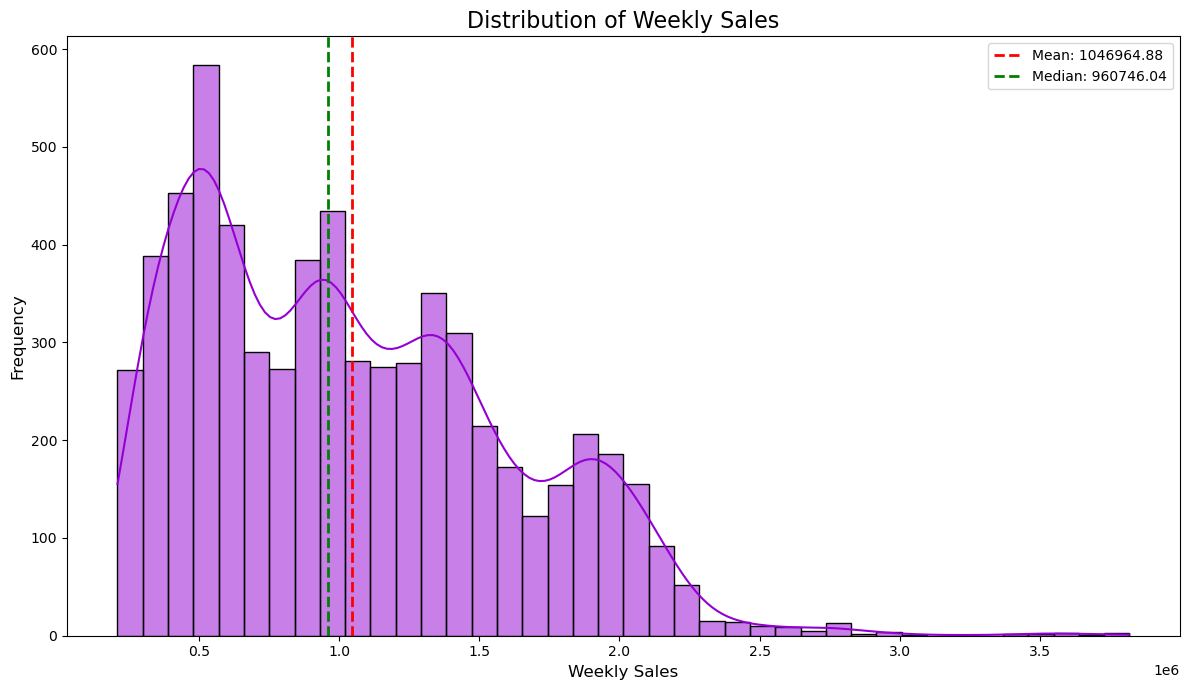

Skewness of Weekly Sales: 0.67
Kurtosis of Weekly Sales: 0.05


In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12, 7))
sns.histplot(final_dataset.Weekly_Sales, kde=True, bins=40, color='darkviolet')
plt.title('Distribution of Weekly Sales', fontsize=16)
plt.xlabel('Weekly Sales', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
#Add vertical lines for mean and median
mean_sales = final_dataset.Weekly_Sales.mean()
median_sales = final_dataset.Weekly_Sales.median()
plt.axvline(mean_sales, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {mean_sales:.2f}')
plt.axvline(median_sales, color='green', linestyle='dashed', linewidth=2, label=f'Median: {median_sales:.2f}')
plt.legend()
plt.tight_layout()
plt.show()
#Calculate skewness and kurtosis
skewness = final_dataset.Weekly_Sales.skew()
kurtosis = final_dataset.Weekly_Sales.kurtosis()
print(f"Skewness of Weekly Sales: {skewness:.2f}")
print(f"Kurtosis of Weekly Sales: {kurtosis:.2f}")

### Inference:
The distribution of Weekly Sales shows a **right-skewed pattern**, with a **mean** of 1,046,964.88 and a **median** of 960,746.04. This indicates that while most stores experience moderate sales volumes, a few stores contribute significantly higher sales. The **skewness** value of 0.67 indicates a slight positive skew, and the **kurtosis** value of 0.05 suggests a near-normal peak height, meaning the sales data is mostly centered around moderate values with a few outliers generating larger sales figures.


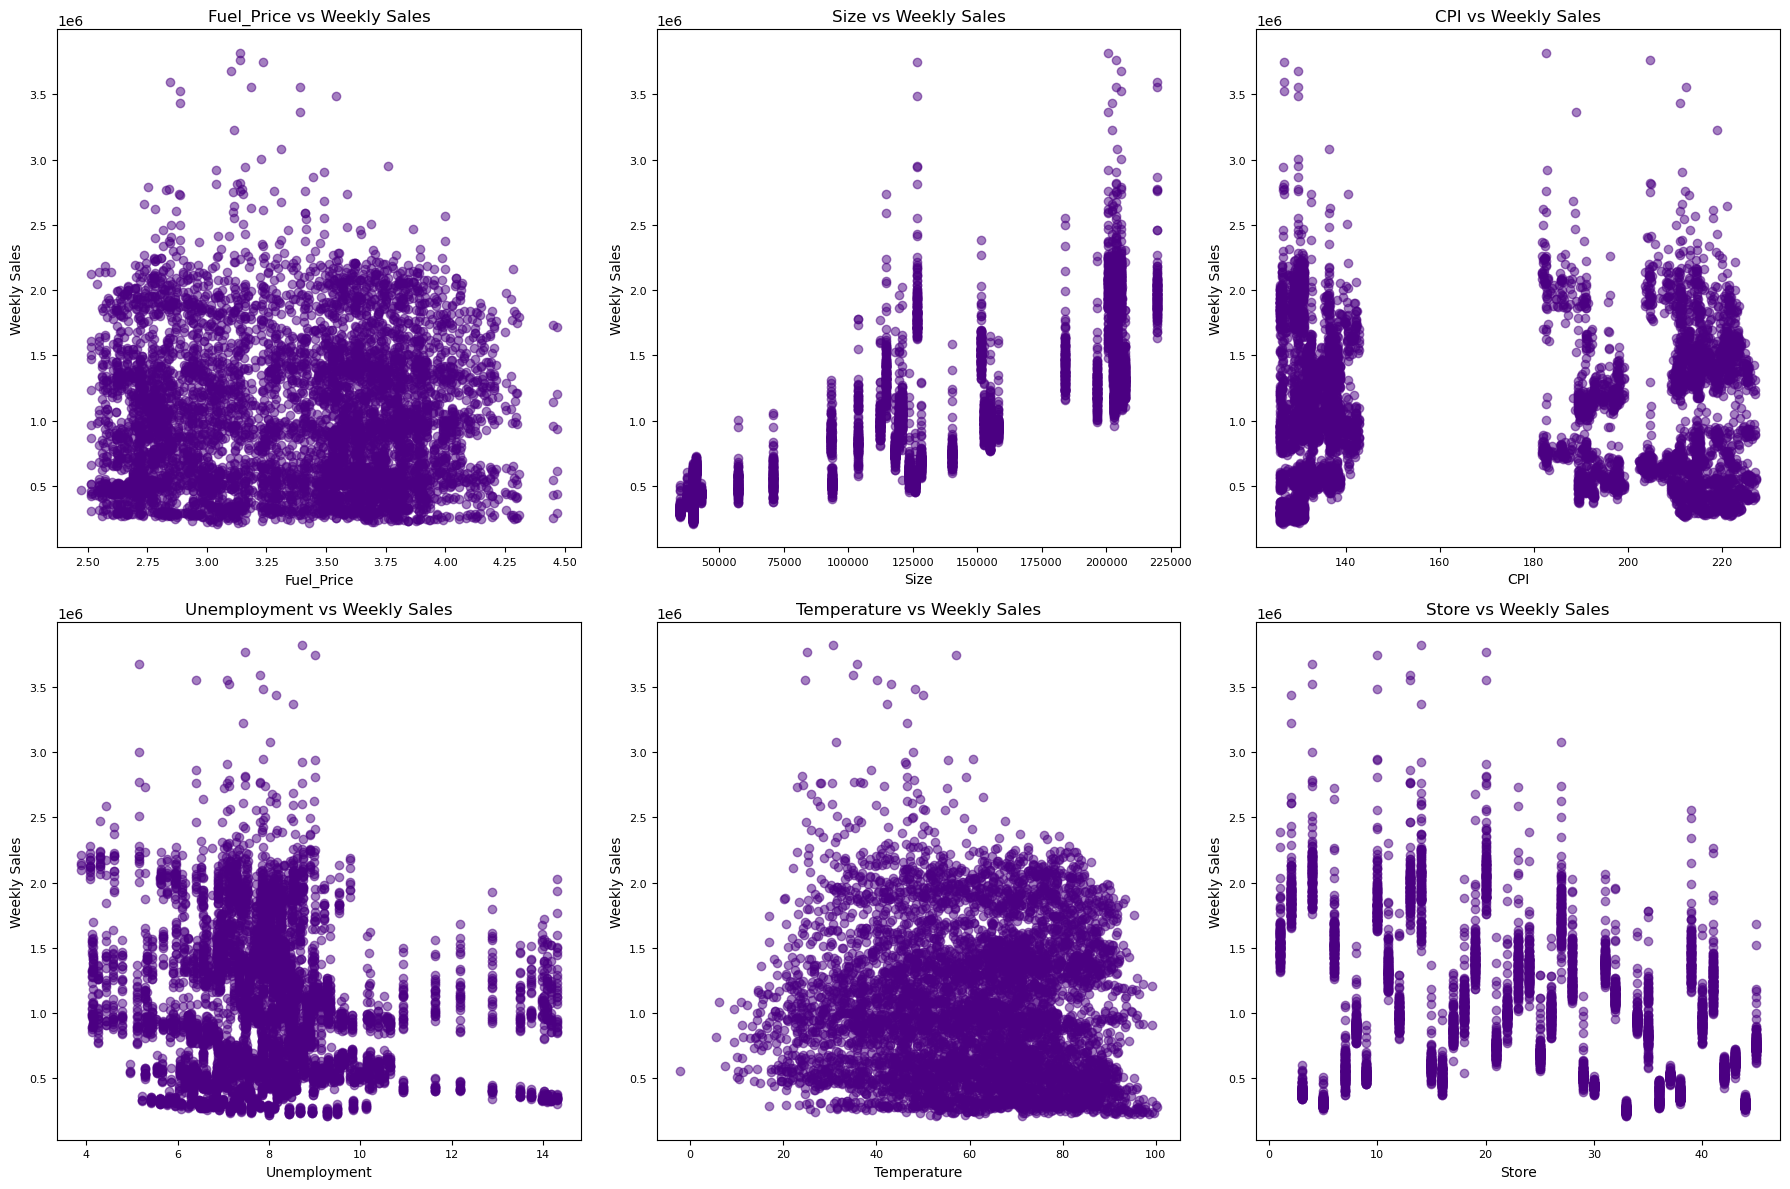

Correlations with Weekly Sales:
Weekly_Sales    1.000000
Size            0.810468
Fuel_Price      0.009464
Temperature    -0.063810
CPI            -0.072634
Unemployment   -0.106176
Store          -0.335332
Name: Weekly_Sales, dtype: float64


In [21]:
import matplotlib.pyplot as plt

# Create a function to generate scatter plots on subplots
def create_scatter_matrix(dataset, features):
    num_features = len(features)
    rows = (num_features + 2) // 3 # Ensure we have enough rows
    fig, axes = plt.subplots(rows, 3, figsize=(18, 6 * rows))
    axes = axes.flatten()

    for idx, feature in enumerate(features):
        axes[idx].scatter(dataset[feature], dataset['Weekly_Sales'], alpha=0.5, color='indigo')
        axes[idx].set_xlabel(feature, fontsize=10)
        axes[idx].set_ylabel('Weekly Sales', fontsize=10)
        axes[idx].set_title(f'{feature} vs Weekly Sales', fontsize=12)
        axes[idx].tick_params(axis='both', which='major', labelsize=8)
    # Remove any unused subplots
    
    for idx in range(num_features, len(axes)):
        fig.delaxes(axes[idx])

    plt.tight_layout()
    plt.show()
#Features to plot
features_to_analyze = ['Fuel_Price', 'Size', 'CPI', 'Unemployment', 'Temperature', 'Store']
#Generate scatter plots
create_scatter_matrix(final_dataset, features_to_analyze)

#Calculate correlations
correlations = final_dataset[features_to_analyze + ['Weekly_Sales']].corr()['Weekly_Sales'].sort_values(ascending=False)
print("Correlations with Weekly Sales:")
print(correlations)



Inference : Store size shows the strongest positive correlation (0.810468) with weekly sales, This might be the highest contributing predictor in the model out of all, while other factors show weaker relationships.

In [22]:
print(final_dataset.dtypes)

Store                    int64
Date            datetime64[ns]
Weekly_Sales           float64
Type                    object
Size                     int64
Temperature            float64
Fuel_Price             float64
MarkDown1              float64
MarkDown2              float64
MarkDown3              float64
MarkDown4              float64
MarkDown5              float64
CPI                    float64
Unemployment           float64
Holiday_Flag             int64
Day                      int32
Month                   object
Year                     int32
Week                    UInt32
dtype: object


In [23]:
final_dataset['Week'] = final_dataset['Week'].astype(int)

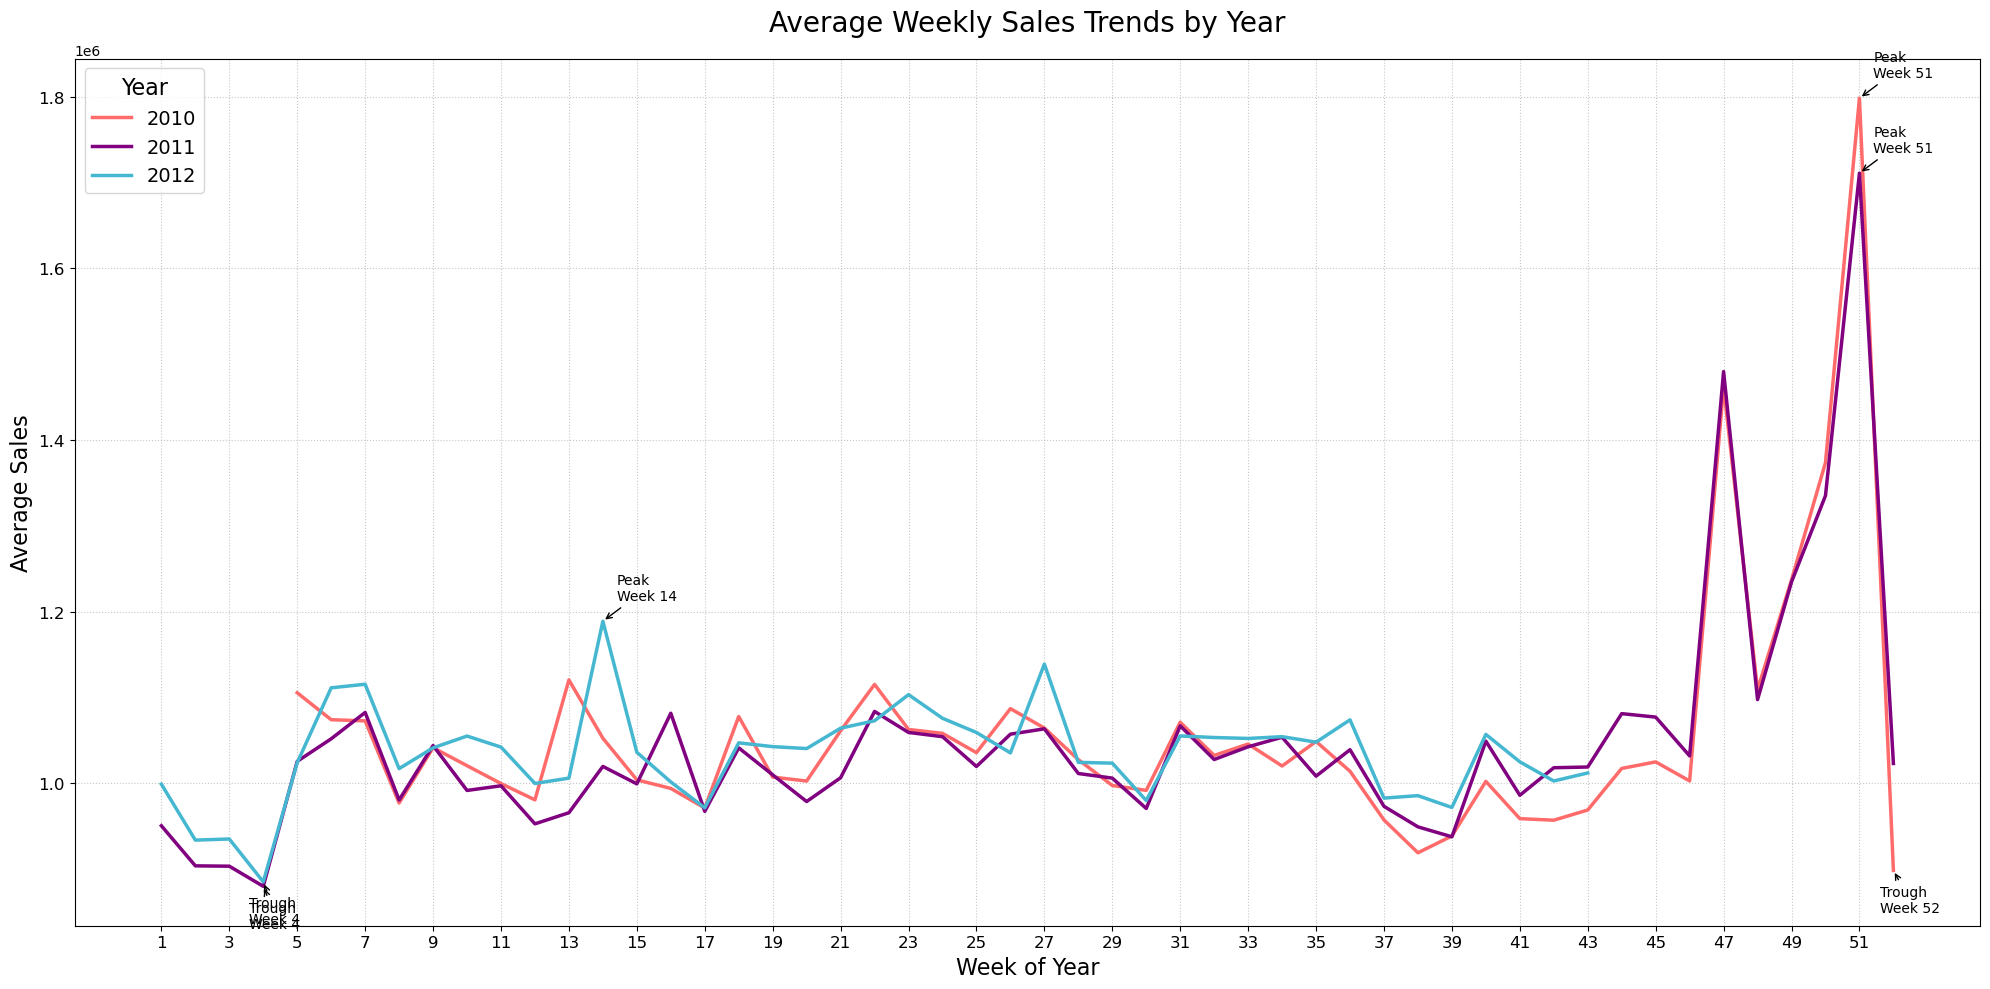

Year-over-year growth from 2010 to 2011: 6.96%
Year-over-year growth from 2011 to 2012: -18.30%


In [24]:
# shows total sales for each week over time.

# Yearly sales dictionary
yearly_sales = {
    year: final_dataset[final_dataset['Year'] == year]
    .groupby('Week')['Weekly_Sales']
    .mean().dropna()
    for year in final_dataset['Year'].unique()
}

# Plotting
plt.figure(figsize=(20, 10))

colors = ['#FF6B6B', '#800080', '#45B7D1']
styles = ['-', '-', '-']


for (year, sales), style, color in zip(yearly_sales.items(), styles, colors):
    sns.lineplot(x=sales.index, y=sales.values, linestyle=style, color=color, linewidth=2.5, label=f"{year}")

# Customize grid and ticks
plt.grid(True, linestyle=':', alpha=0.7)
plt.xticks(np.arange(1, 53, step=2), fontsize=12)
plt.yticks(fontsize=12)

# Adjust legend
plt.legend(loc='upper left', fontsize=14, title='Year', title_fontsize=16)

# Title and labels
plt.title('Average Weekly Sales Trends by Year', fontsize=20, pad=20)
plt.ylabel('Average Sales', fontsize=16)
plt.xlabel('Week of Year', fontsize=16)

# Annotating peak and trough weeks for each year
for year, sales in yearly_sales.items():
    peak_week = sales.idxmax()
    trough_week = sales.idxmin()
    
    # Add peak annotation
    plt.annotate(f'Peak\nWeek {peak_week}', 
                 (peak_week, sales[peak_week]), 
                 xytext=(10, 15), 
                 textcoords='offset points', 
                 fontsize=10, 
                 arrowprops=dict(arrowstyle="->", lw=1, color='black'))
    
    # Add trough annotation
    plt.annotate(f'Trough\nWeek {trough_week}', 
                 (trough_week, sales[trough_week]), 
                 xytext=(-10, -30), 
                 textcoords='offset points', 
                 fontsize=10, 
                 arrowprops=dict(arrowstyle="->", lw=1, color='black'))

plt.tight_layout()
plt.show()

# Calculating year-over-year growth
for year in range(2011, 2013):
    if year - 1 in yearly_sales and year in yearly_sales:
        growth = ((yearly_sales[year].sum() - yearly_sales[year - 1].sum()) /
                  yearly_sales[year - 1].sum()) * 100
        print(f"Year-over-year growth from {year-1} to {year}: {growth:.2f}%")

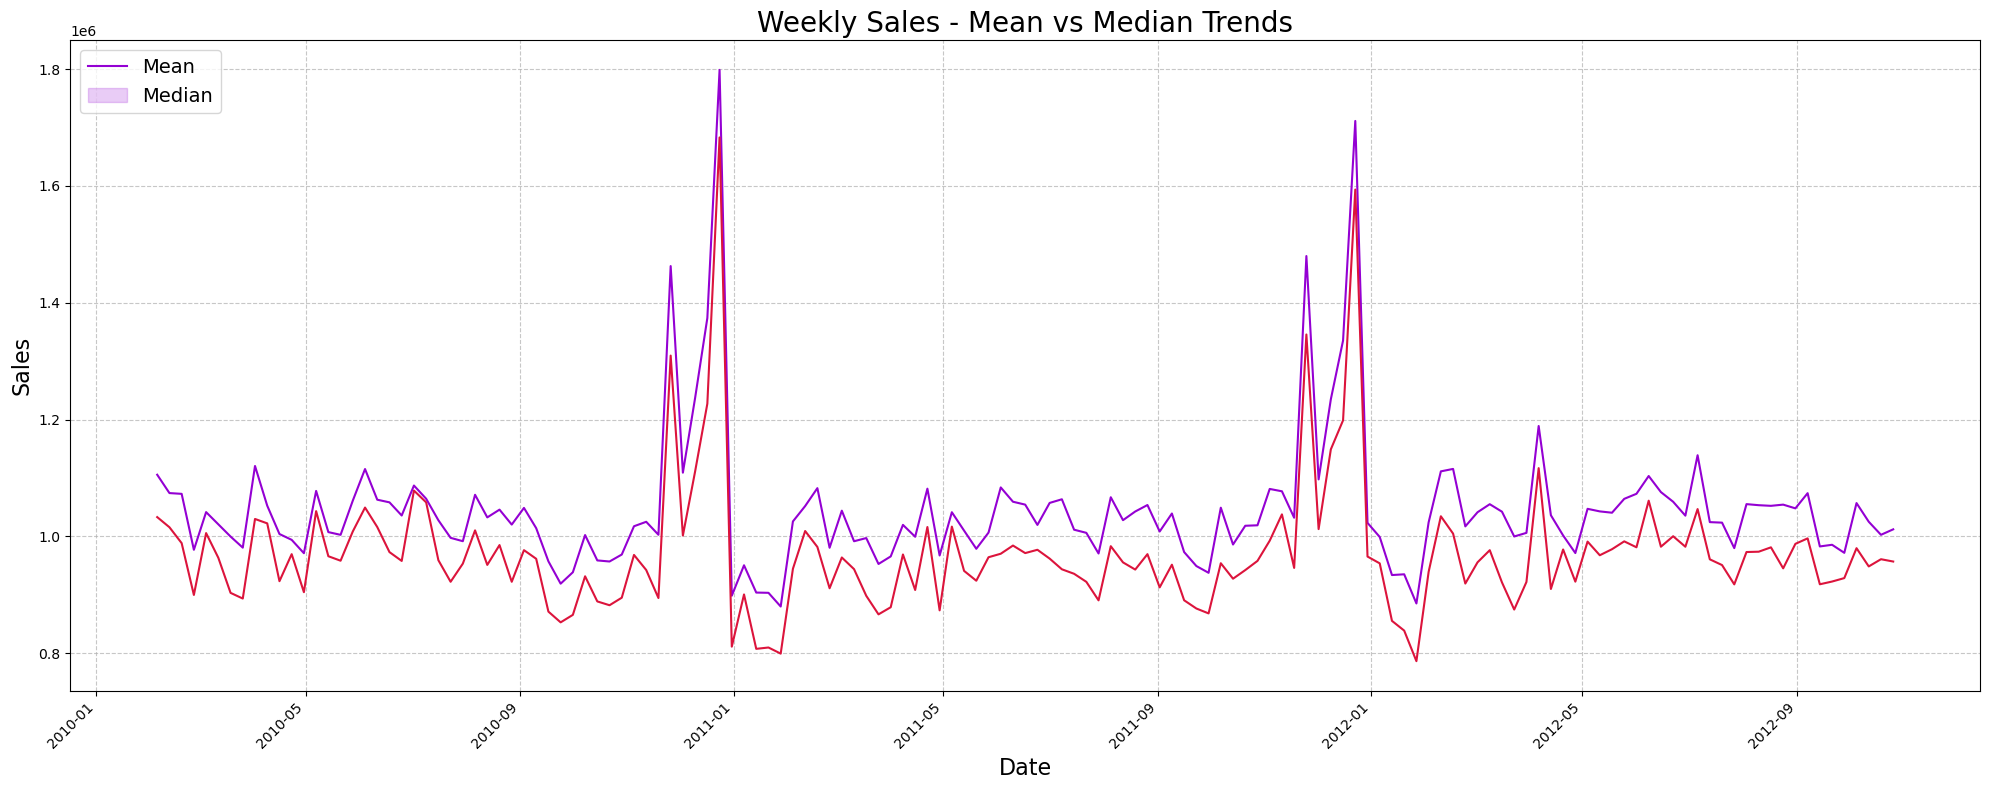

In [25]:
#compares the mean and median of sales over time, visualized as trends based on daily sales data.
weekly_sales_mean = final_dataset['Weekly_Sales'].groupby(final_dataset['Date']).mean()
weekly_sales_median = final_dataset['Weekly_Sales'].groupby(final_dataset['Date']).median()
plt.figure(figsize=(20,8))
sns.lineplot(x=weekly_sales_mean.index, y=weekly_sales_mean.values, color='darkviolet')
sns.lineplot(x=weekly_sales_median.index, y=weekly_sales_median.values, color='crimson')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(['Mean', 'Median'], loc='upper left', fontsize=14)
plt.title('Weekly Sales - Mean vs Median Trends', fontsize=20)
plt.ylabel('Sales', fontsize=16)
plt.xlabel('Date', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Inferences:

#### Sales Patterns:
- Most weekly sales hover around a normalized value of 1.0, suggesting that sales remain relatively stable throughout the years.
- Significant sales spikes occur between weeks 47-51, aligning with the holiday season sales surge.
- The highest peak, around week 51, reaches approximately 1.8, indicating a strong sales boost during the holidays.

#### Year-over-Year Performance:
- **2010 to 2011**: A 6.96% increase in total sales shows steady growth.
- **2011 to 2012**: A 18.3% decline in sales, indicating a drop in overall sales performance during this period.

#### Key Observations:
- Sales patterns exhibit cyclical behavior, with similar trends across all three years.
- The most significant fluctuations in sales occur during the holiday season (weeks 47-51).
- There is a smaller peak around week 15, suggesting a potential spring sales period, possibly driven by seasonal markdowns.


#### Checking the relationship of the other features with weekly sales

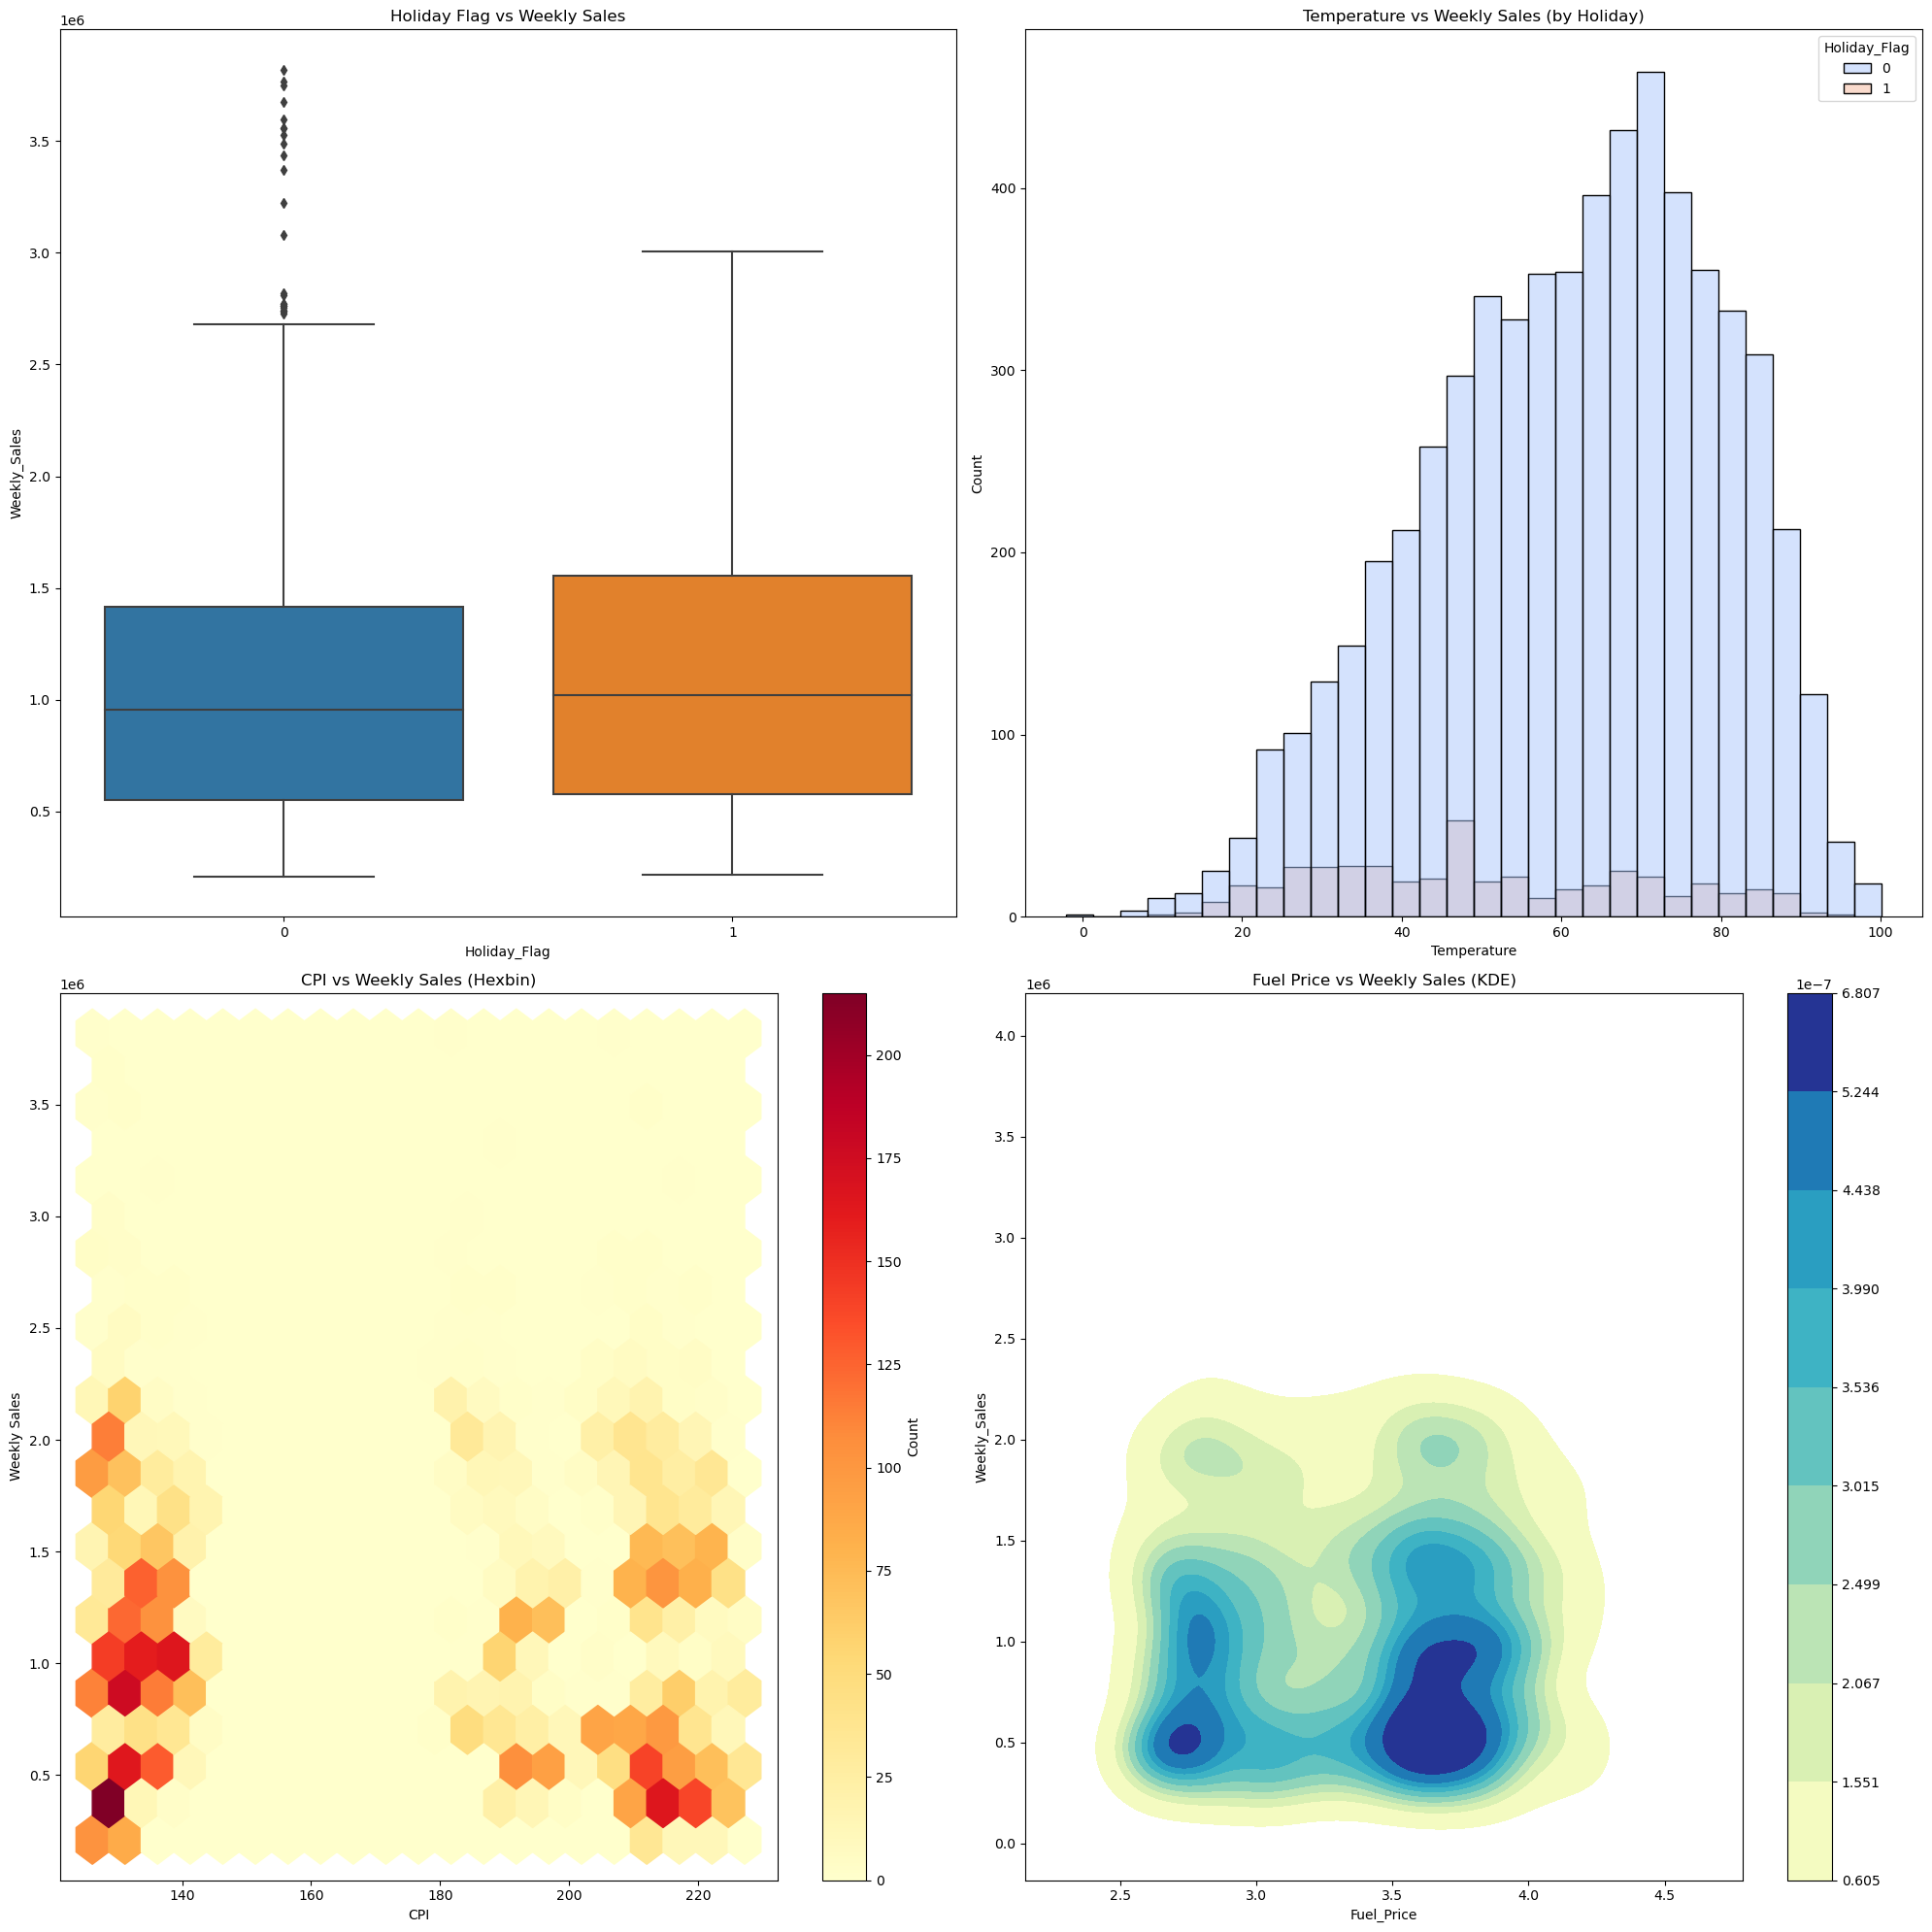

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(20, 20))

# Box plot for Holiday_Flag
sns.boxplot(x='Holiday_Flag', y='Weekly_Sales', data=final_dataset, ax=axes[0, 0])
axes[0, 0].set_title('Holiday Flag vs Weekly Sales')

# Histogram for Temperature, colored by Holiday_Flag
sns.histplot(data=final_dataset, x='Temperature', hue='Holiday_Flag', bins=30, ax=axes[0, 1], palette='coolwarm')
axes[0, 1].set_title('Temperature vs Weekly Sales (by Holiday)')

# Hexbin plot for CPI
hexbin = axes[1, 0].hexbin(final_dataset['CPI'], final_dataset['Weekly_Sales'], gridsize=20, cmap='YlOrRd')
axes[1, 0].set_title('CPI vs Weekly Sales (Hexbin)')
axes[1, 0].set_xlabel('CPI')
axes[1, 0].set_ylabel('Weekly Sales')
fig.colorbar(hexbin, ax=axes[1, 0], label='Count')

# KDE plot for Fuel_Price
sns.kdeplot(data=final_dataset, x='Fuel_Price', y='Weekly_Sales', cmap="YlGnBu", shade=True, cbar=True, ax=axes[1, 1])
axes[1, 1].set_title('Fuel Price vs Weekly Sales (KDE)')

plt.tight_layout()
plt.show()

#### Explaining the ploting Techniques:

Histogram for Temperature:
Instead of a violin plot, we're now using a histogram.
The x-axis shows Temperature, and the y-axis shows Weekly Sales.
The color of the bars is based on the Holiday_Flag, allowing us to see how the distribution of sales across temperatures differs between holiday and non-holiday periods.

Explanations:
Hexbin Plot (CPI vs Weekly Sales):
A hexbin plot divides the plot area into hexagonal bins.
The color of each hexagon represents the number of data points falling within that bin.
In this case, it shows where the concentration of CPI and Weekly Sales data points is highest.

KDE (Kernel Density Estimation) Plot (Fuel Price vs Weekly Sales):
KDE plots show the estimated probability density function of a variable.
In a 2D KDE plot, the color intensity represents the density of data points.
This plot shows how the joint distribution of Fuel Price and Weekly Sales varies, with darker areas indicating higher density of data points.

#### Holiday Impact 
The box plot shows weekly sales distribution by holiday flag (0 vs 1):

Holiday periods (1) show higher median sales and greater variability. Non-holiday periods (0) demonstrate more consistent sales patterns. Several outliers appear in both categories, particularly during holiday periods

#### Temperature Effects
The temperature histogram reveals:
Sales distribution across temperature ranges from 0°F to 100°F
Peak frequency occurs between 60-80°F
Clear bell-shaped distribution with most sales activity in moderate temperature ranges
 
#### CPI vs Weekly Sales
Higher concentration of sales activity (shown in red) at specific CPI ranges
Clusters of high sales appear around CPI values of 140 and 220
Yellow areas indicate moderate sales activity

#### Fuel Price vs Weekly Sales
Dense concentration of sales (shown in blue) at specific fuel price points
Multiple hotspots indicating strong relationships between fuel prices and sales
Gradient pattern suggests complex relationship between fuel prices and sales performance

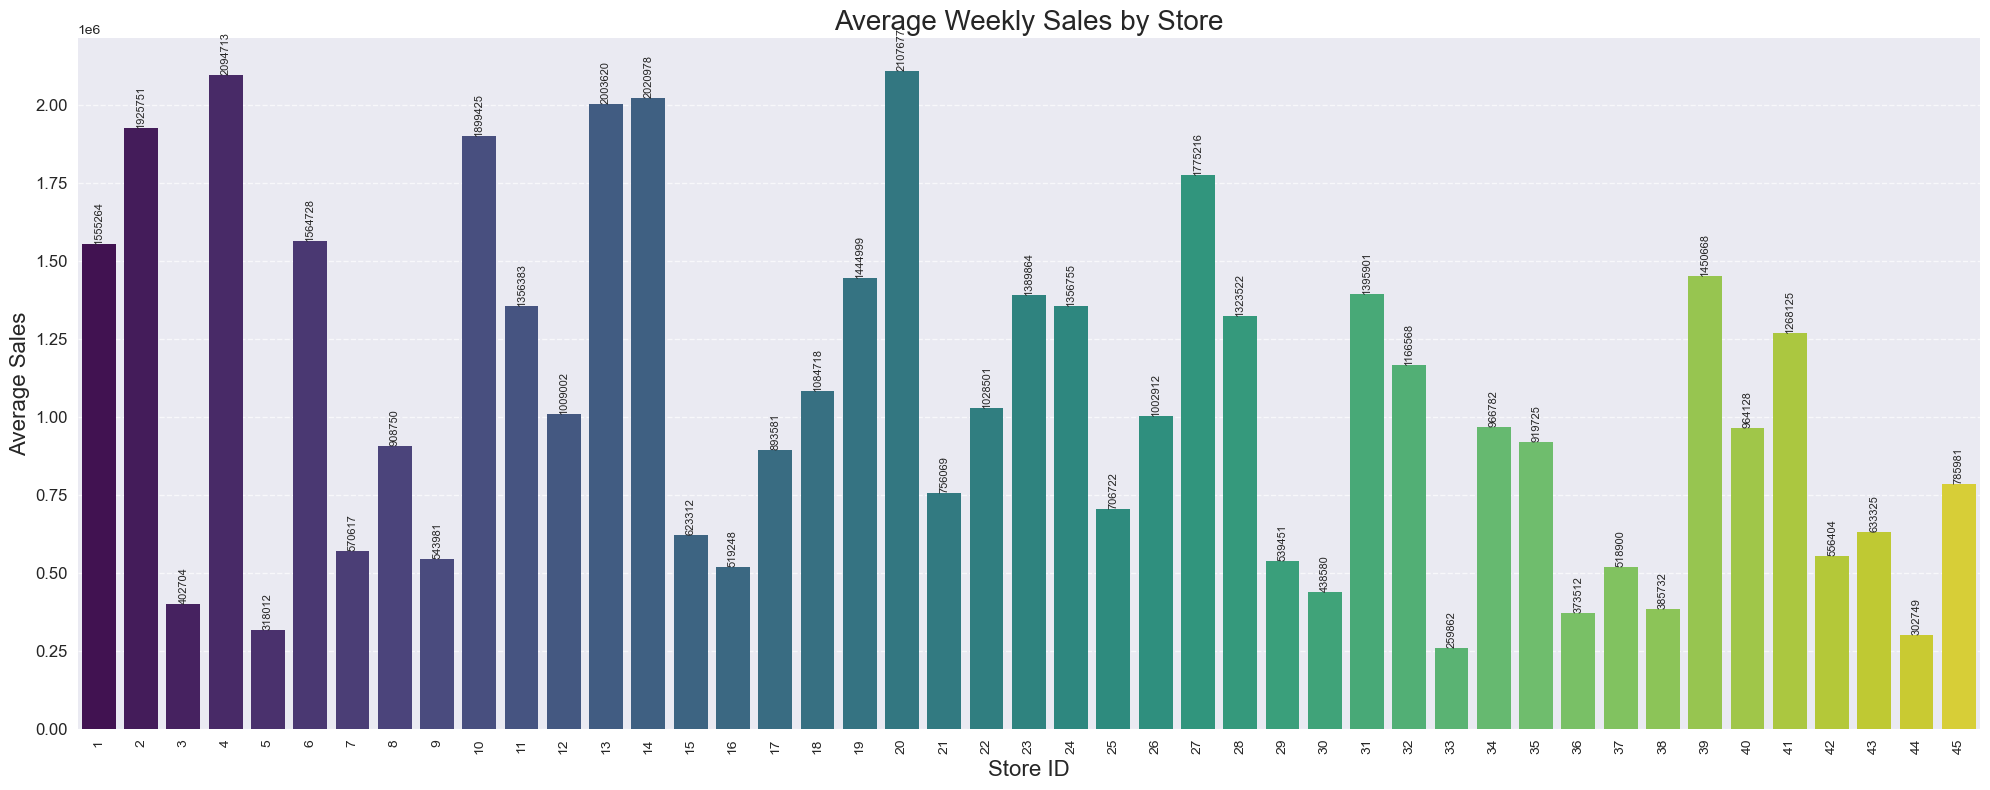

Store with highest average sales: 20 ($2107676.87)
Store with lowest average sales: 33 ($259861.69)
Overall average sales across all stores: $1046964.88


In [27]:
weekly_sales = final_dataset['Weekly_Sales'].groupby(final_dataset['Store']).mean()

plt.figure(figsize=(20, 8))
plt.style.use('seaborn')

sns.barplot(x=weekly_sales.index, y=weekly_sales.values, palette='viridis')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.title('Average Weekly Sales by Store', fontsize=20)
plt.ylabel('Average Sales', fontsize=16)
plt.xlabel('Store ID', fontsize=16)

plt.xticks(rotation=90, fontsize=10)
plt.yticks(fontsize=12)

# Add value labels on top of each bar
for i, v in enumerate(weekly_sales.values):
    plt.text(i, v, f'{v:.0f}', ha='center', va='bottom', fontsize=8, rotation=90)

plt.tight_layout()
plt.show()

# Print summary statistics
print(f"Store with highest average sales: {weekly_sales.idxmax()} (${weekly_sales.max():.2f})")
print(f"Store with lowest average sales: {weekly_sales.idxmin()} (${weekly_sales.min():.2f})")
print(f"Overall average sales across all stores: ${weekly_sales.mean():.2f}")



Inferences :

#### Store Performance Analysis
- Store 20 shows the highest average sales at 2,107,676.87 dollars.
- Store 33 has the lowest average sales at 259,861.69 dollars.
- The overall average sales across all stores is 1,046,964.88 dollars.
- Significant variation exists between stores, with some performing more than 8 times better than others

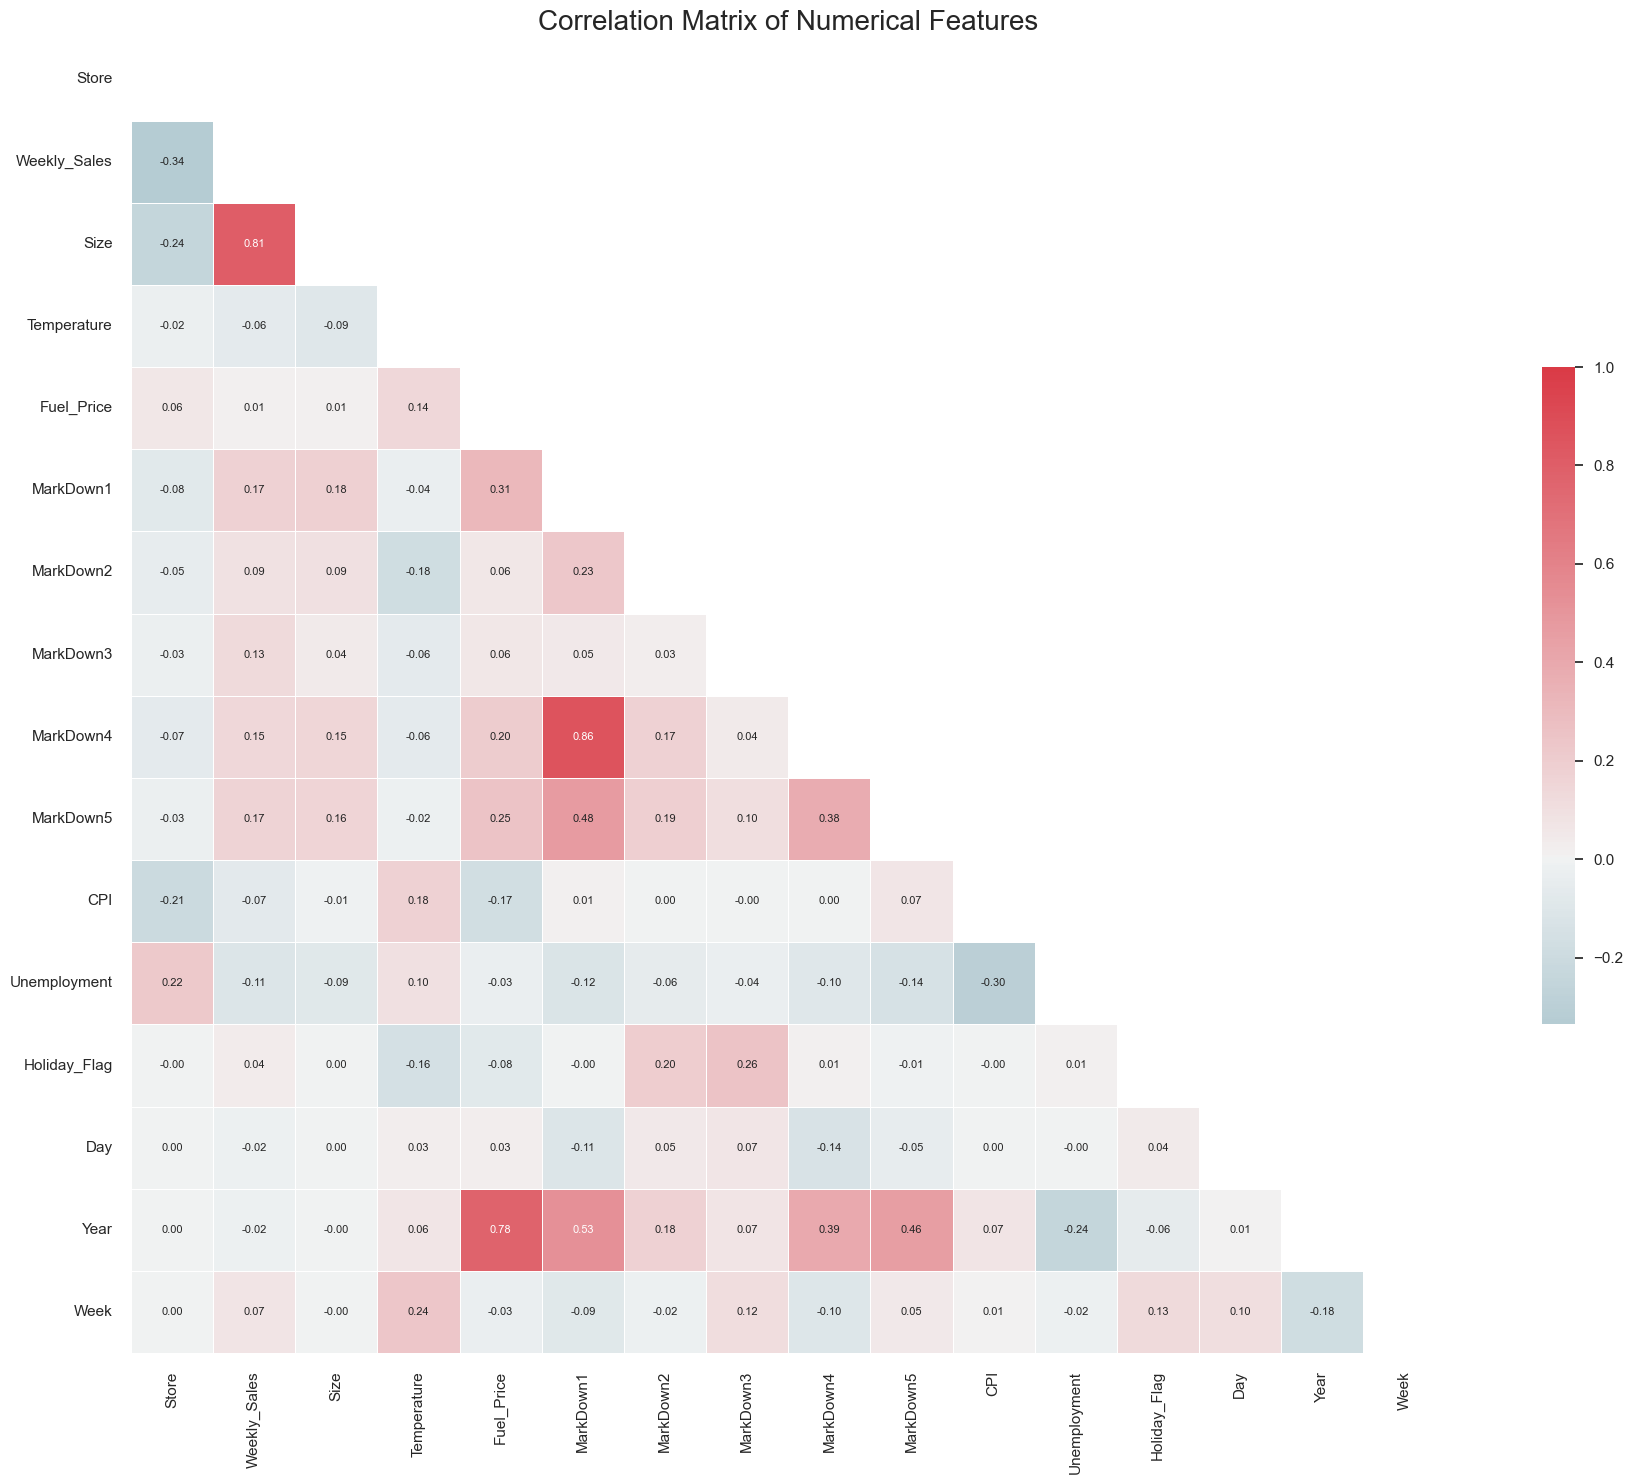

Strong correlations (|r| > 0.5):
MarkDown1     MarkDown4       0.862171
MarkDown4     MarkDown1       0.862171
Weekly_Sales  Size            0.810468
Size          Weekly_Sales    0.810468
Fuel_Price    Year            0.779470
Year          Fuel_Price      0.779470
MarkDown1     Year            0.527987
Year          MarkDown1       0.527987
dtype: float64


In [28]:
# Set style for the seaborn plot
sns.set(style="white")

# Ensure only numerical columns are considered
data_numeric = final_dataset.select_dtypes(include=[np.number])

# Compute the correlation matrix
correlation_matrix = data_numeric.corr()

# Generate a mask for the upper triangle of the correlation matrix
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

# Set up the matplotlib figure
fig, ax = plt.subplots(figsize=(20, 15))

# Define a diverging colormap
cmap = sns.diverging_palette(220, 10, as_cmap=True)

# Title for the heatmap
plt.title('Correlation Matrix of Numerical Features', fontsize=20)

# Draw the heatmap with the mask, colormap, and additional settings
sns.heatmap(
    correlation_matrix,
    mask=mask,
    cmap=cmap,
    vmax=1,
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.5},
    annot=True,
    fmt=".2f",
    annot_kws={"size": 8}
)

# Adjust the layout and show the plot
plt.tight_layout()
plt.show()

# Identify strong correlations (|r| > 0.5) and exclude self-correlations (r = 1)
strong_correlations = correlation_matrix.unstack()
strong_correlations = strong_correlations[abs(strong_correlations) > 0.5]
strong_correlations = strong_correlations[strong_correlations < 1.0]

# Print the strong correlations
print("Strong correlations (|r| > 0.5):")
print(strong_correlations.sort_values(ascending=False))

Inference :

#### Strong Correlations
- MarkDown1 and MarkDown4 show the strongest correlation (0.862) ( coulad be due to the imputation with -999)
- Weekly Sales and Store Size are highly correlated (0.810), as seen before this will be an important feature for our model
- Fuel Price and Year demonstrate strong correlation (0.779) (Fuel price icreases with year)
- MarkDown1 and Year show moderate correlation (0.527)
    

## TIME SERIES ANALYSIS

### STORE LEVEL ANALYSIS

#### Here I am analysing one store to understand the time series problem.

#### Understanding Time Series Data

Time series data is a sequence of data points collected or recorded at regular intervals over time. Here, the Weekly_Sales data for different stores is analyzed. It has three main characteristics : 

- **Trend**: This component represents the long-term movement or direction of the data. It indicates whether the data is generally increasing, decreasing, or staying constant over time.
  
- **Seasonality**: This represents the repeating patterns or cycles within a specific period (e.g., daily, weekly, yearly). Seasonality is typically observed in data where periodic fluctuations are evident (e.g., temperature, sales cycles).
  
- **Residuals (or Noise)**: This component captures the random fluctuations or errors left after removing the trend and seasonal components. These are the variations in the data that cannot be explained by the trend or seasonal patterns.


STORE 20

A line plot is used to visualize sales trends over time. This helps in identifying:

- Periods of high/low sales.
- Potential patterns or anomalies.


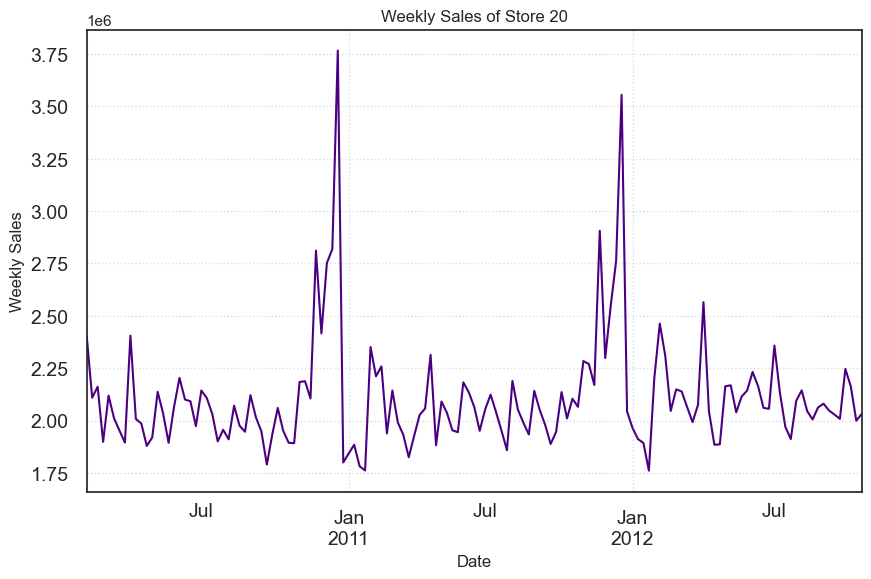

In [29]:
data1 = pd.read_csv(sales_history_path)
data1.set_index('Date', inplace=True)
store20 = data1[data1.Store == 20]
sales20 = pd.DataFrame(store20.Weekly_Sales.groupby(store20.index).sum())
sales20.reset_index(inplace=True)
sales20['Date'] = pd.to_datetime(sales20['Date'])
sales20.set_index('Date', inplace=True)
plt.figure(figsize=(10, 6))
sales20.Weekly_Sales.plot(title='Weekly Sales of Store 20', fontsize=14, color='indigo')
plt.ylabel('Weekly Sales', fontsize=12)
plt.xlabel('Date', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()


Inference: 
    
We see the trend is similar to what we interpreted for the entire data previously

### TIME SERIES CHARACTERISTICS

#### TIME SERIES DECOMPOSITION

### Decomposition of Time Series

When analyzing time series data, we typically decompose the series into its components to better understand the underlying patterns. This decomposition generally splits the time series into three parts: Trend, Seasonality and Residuals (or Noise).


---

### Variance in Time Series Decomposition

The key to measuring the strength of the trend and seasonality is to compare the variance (a measure of how much the data varies) within these components:

- **Variance of the Trend (Var(Trend))**: The variability captured by the trend component. A larger variance indicates that the trend is more pronounced, i.e., the time series shows significant long-term directional movement.
  
- **Variance of the Seasonality (Var(Seasonal))**: The variability captured by the seasonal component. A larger variance suggests that the time series has strong repeating patterns over time.
  
- **Variance of the Residuals (Var(Residuals))**: This represents the unexplained variation in the data. A high variance in residuals indicates that the data is noisy or that the model has not explained the underlying pattern effectively.

---

### Trend Strength

The **Trend Strength** quantifies how much of the overall time series behavior is explained by the long-term trend. A high trend strength indicates that the trend is dominant over the noise and seasonal fluctuations. It is calculated as:

$$
\text{Trend Strength} = 1 - \frac{\text{Var(Residuals)}}{\text{Var(Trend)} + \text{Var(Residuals)}}
$$

#### Interpretation:
- The numerator, **Var(Residuals)**, represents the unexplained noise.
- The denominator, **Var(Trend) + Var(Residuals)**, represents the total variability of the series after decomposing it into trend and residuals.

- A high **Trend Strength** (close to 1) means that the trend is the dominant component of the time series, and the residuals (random noise) are relatively small.
- A low **Trend Strength** (close to 0) indicates that the trend is weak, and the series is largely composed of noise or seasonal variations.

---

### Seasonality Strength

The **Seasonality Strength** quantifies how much of the data's variation is explained by the periodic seasonal patterns. A high seasonality strength indicates strong periodicity in the data, while a low value suggests weak or no periodic fluctuations. It is calculated as:

$$
\text{Seasonality Strength} = 1 - \frac{\text{Var(Residuals)}}{\text{Var(Seasonal)} + \text{Var(Residuals)}}
$$


#### Interpretation:
- Here, the numerator is still the variance of the residuals (unexplained variability), while the denominator, **Var(Seasonal) + Var(Residuals)**, represents the total variability from both the seasonal component and the noise.
  
- A high **Seasonality Strength** (close to 1) means that the seasonal component is dominant, and the residuals contribute relatively little to the variability.
- A low **Seasonality Strength** (close to 0) indicates weak seasonal patterns, and most of the variability is due to residuals or noise.

---

### Key Insights

- **High Trend Strength**: This indicates that the time series data is mostly driven by long-term directional changes. For example, stock prices or climate data might show significant trends, indicating that the time series is largely influenced by external factors like economic conditions or global warming.

- **High Seasonality Strength**: This indicates that the data exhibits strong, predictable periodic fluctuations. For example, electricity demand might show strong seasonality, with peaks during summer or winter months.

- **Low Trend Strength**: If the trend strength is low, it suggests that the data does not have a clear long-term movement, and the series might be dominated by random fluctuations or seasonal patterns. For example, sales data of a specific product might not show a long-term trend if the product is seasonal or the market is volatile.

- **Low Seasonality Strength**: A low seasonality strength means that the time series does not have strong repeating patterns, and the data is likely to be erratic with no clear seasonal cycles. For example, random events or irregular sales cycles could lead to such behavior.

---

### Example

Let’s say we have a time series of monthly sales data for a product. The data exhibits strong periodic fluctuations due to seasonality (e.g., higher sales during the holiday season) but doesn’t show a consistent long-term trend (it doesn’t steadily increase or decrease). In this case, we would expect the **Seasonality Strength** to be high and the **Trend Strength** to be low.


#### Below decomposition separates the time series into:

- Observed: Original data.
- Trend: Overall direction of the data.
- Seasonal: Repeating patterns at fixed intervals.
- Residual: Random noise after removing trend and seasonality.

#### Implementation

The seasonal_decompose function is used with **additive and multiplicative models**. Here, the period is set to 52 (weekly data over a year).

### Additive vs Multiplicative Models

Time series decomposition models can be classified into **additive** and **multiplicative** based on how they represent the relationship between the observed data, trend, seasonality, and residuals.

#### Additive Model:
The additive model assumes that the components (trend, seasonality, and residuals) are added together to form the observed time series.

The equation for the additive model is:

$$
Y_t = T_t + S_t + R_t
$$

Where:
- $Y_{t}$ is the observed value at time $t$,
- $T_{t}$ is the trend component at time $t$,
- $S_{t}$ is the seasonal component at time $t$,
- $R_{t}$ is the residual component at time $t$.

This model works well when the magnitude of seasonal fluctuations and trends is roughly constant over time.

#### Multiplicative Model:
The multiplicative model assumes that the components (trend, seasonality, and residuals) interact multiplicatively, meaning that the observed value is the product of the trend, seasonal, and residual components.

The equation for the multiplicative model is:

$$
Y_t = T_t \times S_t \times R_t
$$

Where:
- $Y_{t}$ is the observed value at time $t$,
- $T_{t}$ is the trend component at time $t$,
- $S_{t}$ is the seasonal component at time $t$,
- $R_{t}$ is the residual component at time $t$.


This model is more suitable when the seasonal fluctuations grow or shrink proportionally with the trend.

#### Key Differences:
- **Additive Model** is appropriate when the seasonal effects and trends are constant in magnitude.
- **Multiplicative Model** is appropriate when the seasonal effects scale with the trend, meaning the seasonal impact increases or decreases in proportion to the level of the trend.

Choosing between these models depends on the characteristics of the data. If the seasonal fluctuations grow as the trend increases, the multiplicative model is typically a better fit. If the fluctuations are roughly constant, the additive model is more appropriate. Lets see, Which model works for us.


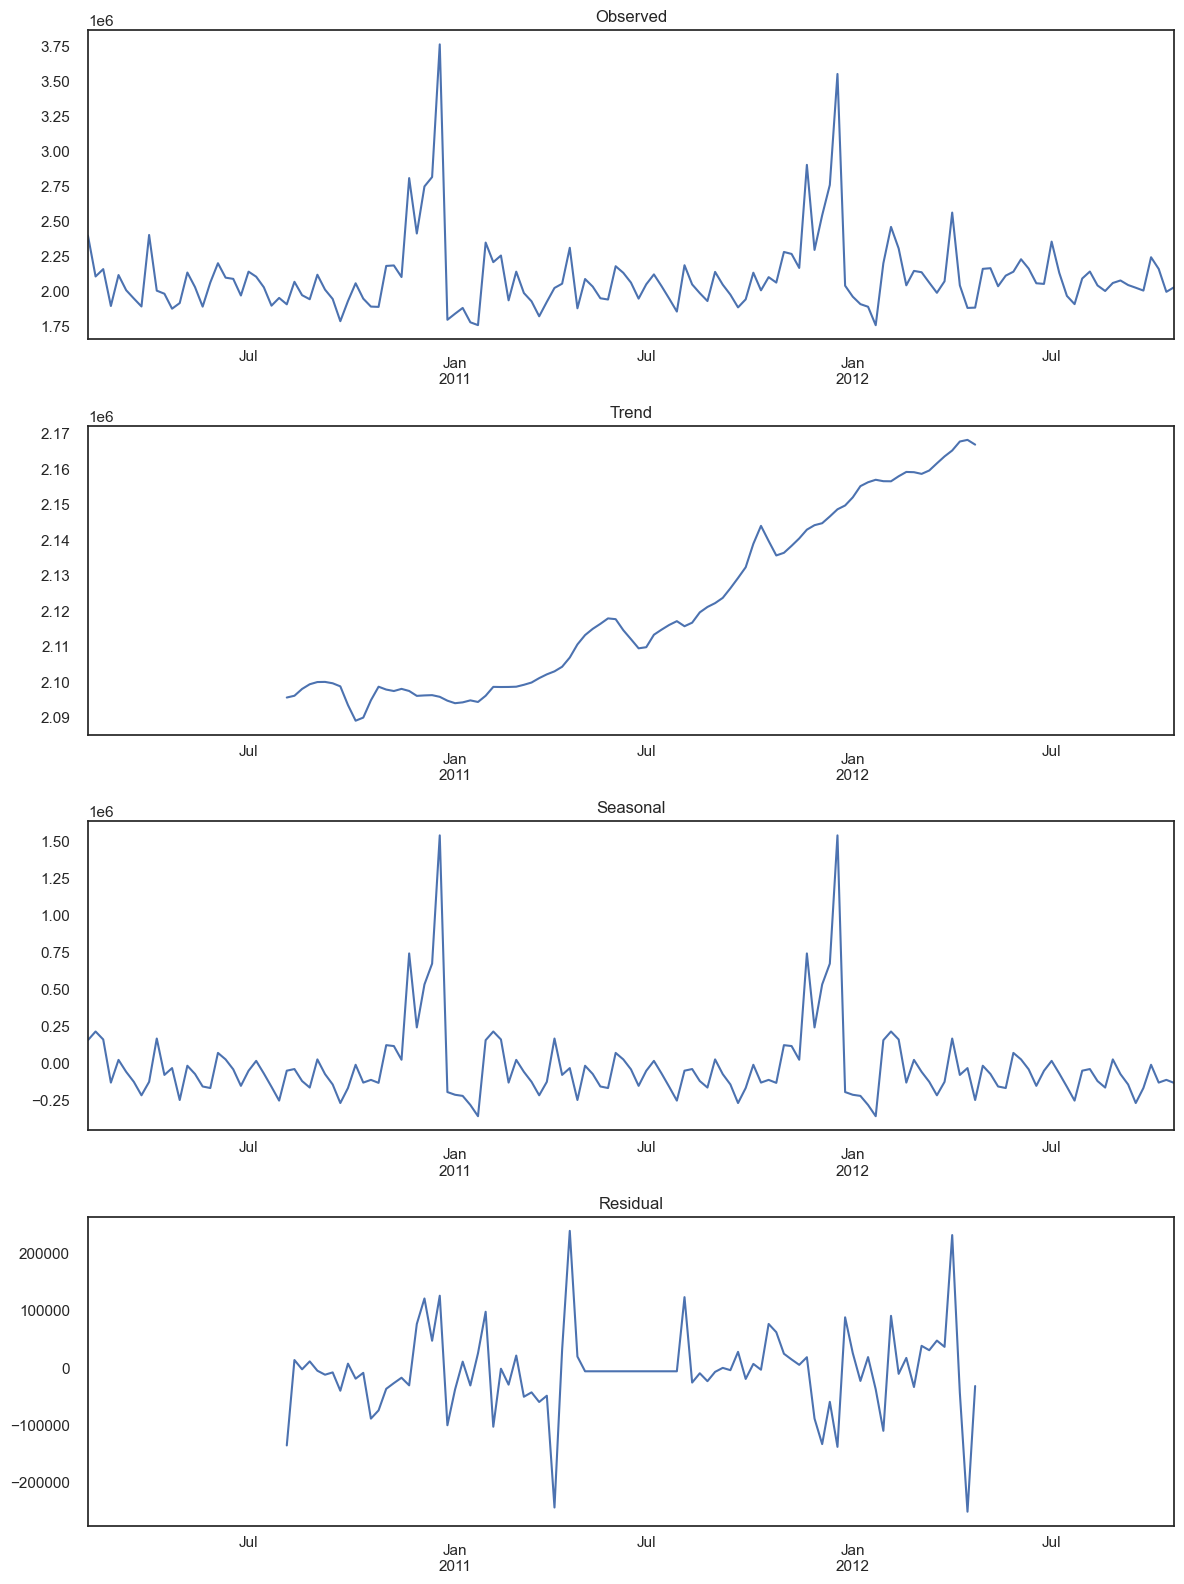

Trend strength: 0.1181
Seasonality strength: 0.9523
Residual standard deviation: 72053.78


In [30]:
#ADDITIVE

# Decompose the time series using seasonal decomposition (additive model)
decomposition = seasonal_decompose(sales20.Weekly_Sales, model='additive', period=52)

# Set up the subplots to show observed, trend, seasonal, and residual components
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(12, 16))

# Plot the components
decomposition.observed.plot(ax=ax1)
ax1.set_title('Observed')
ax1.set_xlabel('')

decomposition.trend.plot(ax=ax2)
ax2.set_title('Trend')
ax2.set_xlabel('')

decomposition.seasonal.plot(ax=ax3)
ax3.set_title('Seasonal')
ax3.set_xlabel('')

decomposition.resid.plot(ax=ax4)
ax4.set_title('Residual')
ax4.set_xlabel('')

# Adjust the layout for better readability
plt.tight_layout()
plt.show()

# Calculate and print additional statistics
trend = decomposition.trend.dropna()
seasonal = decomposition.seasonal.dropna()
residual = decomposition.resid.dropna()

# Calculate strength of trend and seasonality
trend_strength = 1 - np.var(residual) / np.var(trend + residual)
seasonal_strength = 1 - np.var(residual) / np.var(seasonal + residual)

# Print the results
print(f"Trend strength: {trend_strength:.4f}")
print(f"Seasonality strength: {seasonal_strength:.4f}")
print(f"Residual standard deviation: {np.std(residual):.2f}")



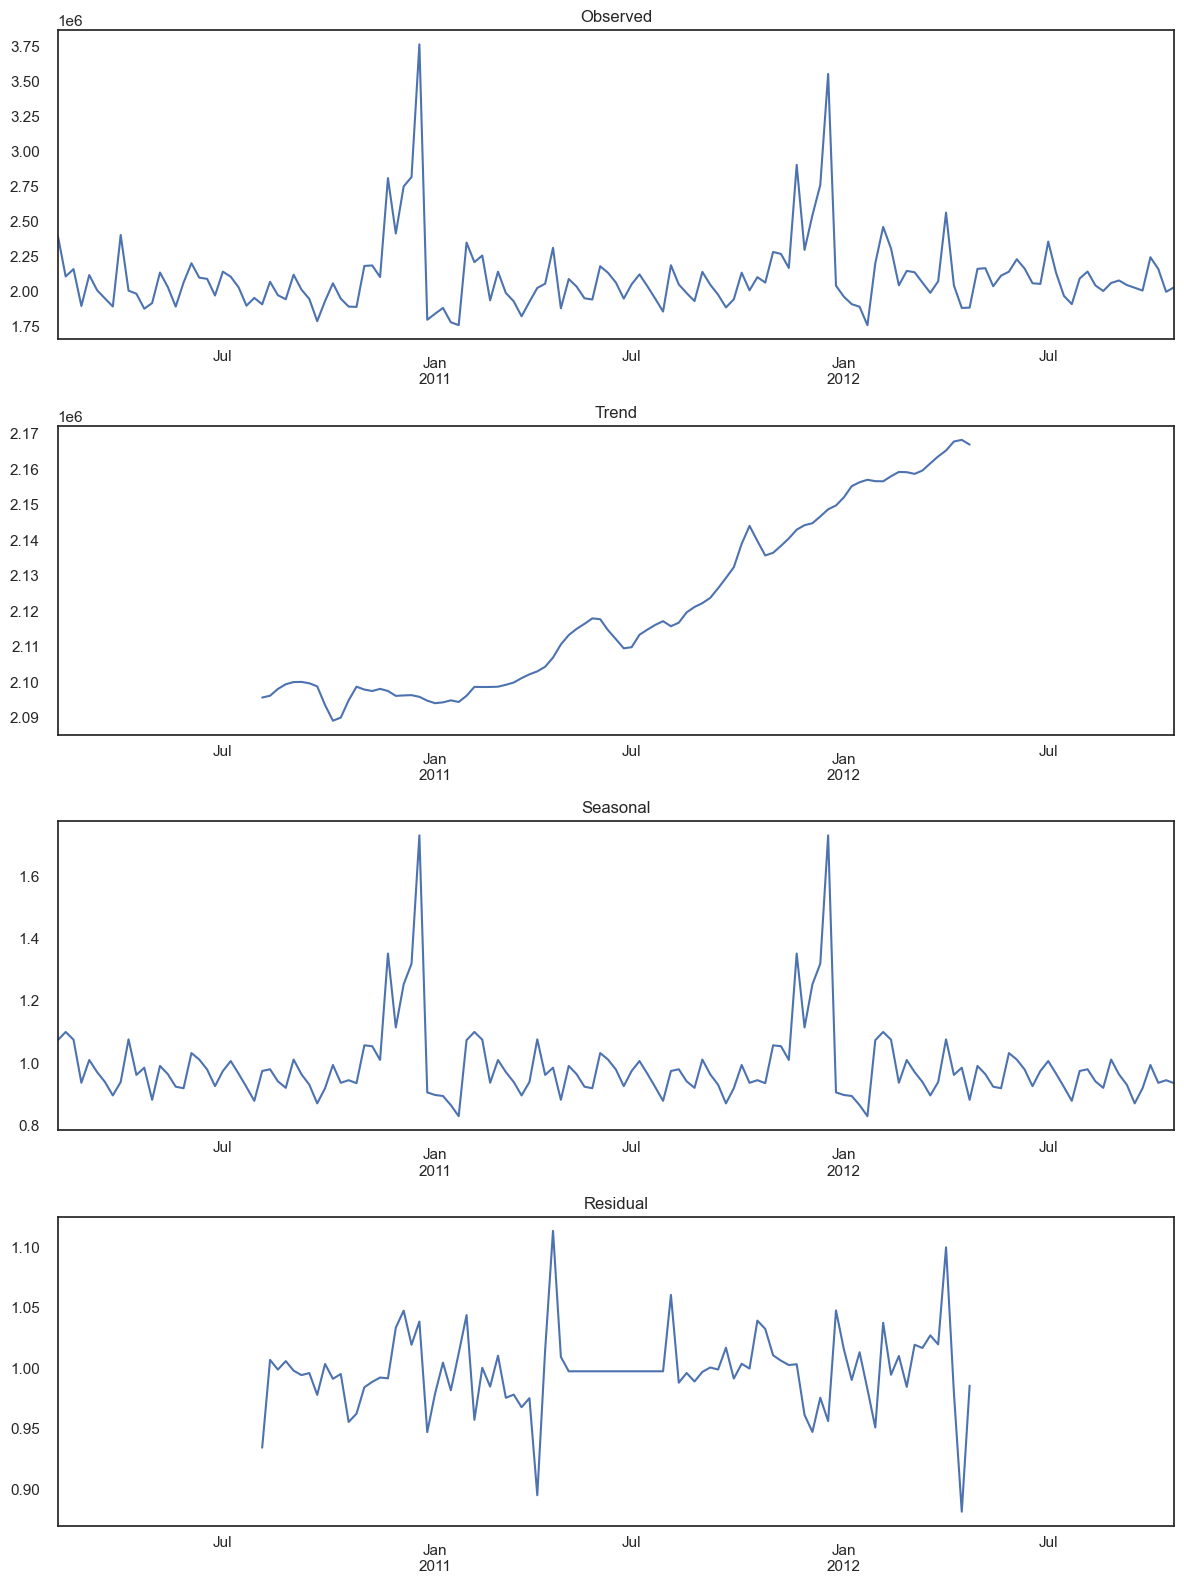

Trend strength: 1.0000
Seasonality strength: 0.9564
Residual standard deviation: 0.03


In [31]:
#MULTIPLICATIVE 

# Decompose the time series using seasonal decomposition (multiplicative model)
decomposition = seasonal_decompose(sales20.Weekly_Sales, model='multiplicative', period=52)

# Set up the subplots to show observed, trend, seasonal, and residual components
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(12, 16))

# Plot the components
decomposition.observed.plot(ax=ax1)
ax1.set_title('Observed')
ax1.set_xlabel('')

decomposition.trend.plot(ax=ax2)
ax2.set_title('Trend')
ax2.set_xlabel('')

decomposition.seasonal.plot(ax=ax3)
ax3.set_title('Seasonal')
ax3.set_xlabel('')

decomposition.resid.plot(ax=ax4)
ax4.set_title('Residual')
ax4.set_xlabel('')

# Adjust the layout for better readability
plt.tight_layout()
plt.show()

# Calculate and print additional statistics for the multiplicative model
trend = decomposition.trend.dropna()
seasonal = decomposition.seasonal.dropna()
residual = decomposition.resid.dropna()

# Calculate strength of trend and seasonality for multiplicative model
trend_strength = 1 - np.var(residual) / np.var(trend * residual)
seasonal_strength = 1 - np.var(residual) / np.var(seasonal * residual)

# Print the results
print(f"Trend strength: {trend_strength:.4f}")
print(f"Seasonality strength: {seasonal_strength:.4f}")
print(f"Residual standard deviation: {np.std(residual):.2f}")



### Results:


**Additive Model:**
- **Trend strength (0.1181):** Suggests a weak long-term trend, with minimal capture of growth or decline in the data.
- **Seasonality strength (0.9523):** Indicates strong seasonal patterns, effectively capturing periodic fluctuations.
- **Residual standard deviation (72053.78):** A high value, indicating that a significant amount of variability is not explained by the model.

**Multiplicative Model:**
- **Trend strength (1.0000):** Indicates a perfect fit for the trend, capturing most of the long-term changes in the data.
- **Seasonality strength (0.9564):** Similar high seasonal strength, slightly higher than the additive model.
- **Residual standard deviation (0.03):** Extremely low, showing that the multiplicative model explains almost all of the data variability.


### Conclusion:
The **multiplicative model** outperforms the **additive model** as it captures the trend more effectively and leaves much less unexplained variability. Therefore, SARIMA is well suited for this data, as it can handle the multiplicative seasonality effectively.


#### COMPARITIVE ANALYSIS

Weekly_Sales    float64
dtype: object
            Weekly_Sales
Date                    
2010-02-05    2135143.87
2010-02-12    2188307.39
2010-02-19    2049860.26
2010-02-26    1925728.84
2010-03-05    1971057.44
2010-03-12    1894324.09
2010-03-19    1897429.36
2010-03-26    1762539.30
2010-04-02    1979247.12
2010-04-09    1818452.72
2010-04-16    1851519.69
2010-04-23    1802677.90
2010-04-30    1817273.28
2010-05-07    2000626.14
2010-05-14    1875597.28
2010-05-21    1903752.60
2010-05-28    1857533.70
2010-06-04    1903290.58
2010-06-11    1870619.23
2010-06-18    1929736.35
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 143 entries, 2010-02-05 to 2012-10-26
Data columns (total 1 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Weekly_Sales  143 non-null    float64
dtypes: float64(1)
memory usage: 2.2 KB
None


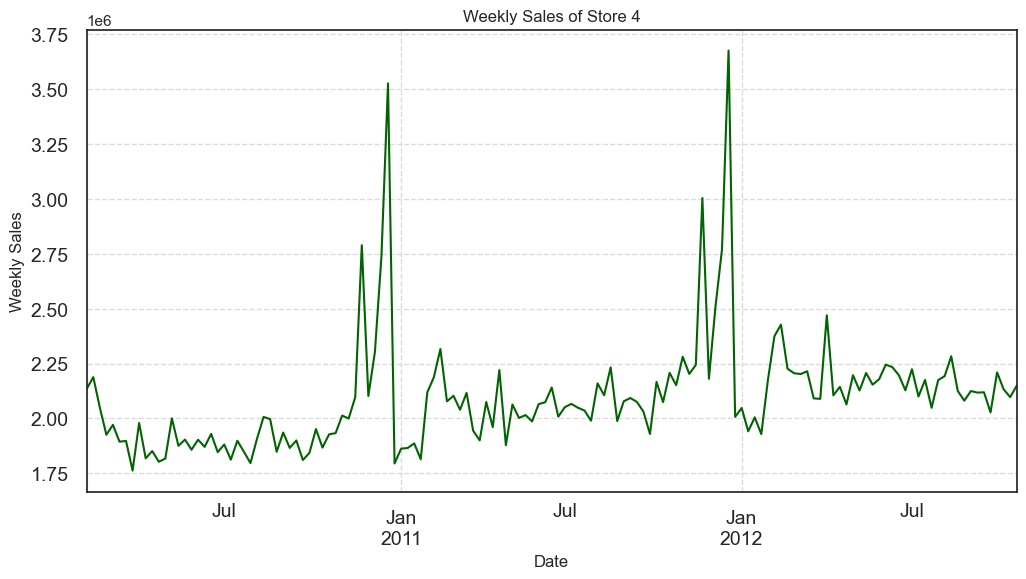

In [32]:
# Load historical sales data
historical_sales = pd.read_csv(sales_history_path)

# Set 'Date' as the index for time-based operations
historical_sales.set_index('Date', inplace=True)

# Filter data for Store 4
store4_data = historical_sales[historical_sales.Store == 4]

# Group Weekly Sales by date and compute the sum for each week
store4_sales = pd.DataFrame(store4_data.Weekly_Sales.groupby(store4_data.index).sum())

# Print the data types and the first 20 rows to verify the structure
print(store4_sales.dtypes)
print(store4_sales.head(20))

# Remove the date from the index to change its dtype
store4_sales.reset_index(inplace=True)

# Convert the 'Date' column to datetime type for proper handling
store4_sales['Date'] = pd.to_datetime(store4_sales['Date'])

# Set the 'Date' column back to the index
store4_sales.set_index('Date', inplace=True)

# Display the updated DataFrame info
print(store4_sales.info())

# Plot Weekly Sales for Store 4
plt.figure(figsize=(12, 6))
store4_sales.Weekly_Sales.plot(title='Weekly Sales of Store 4', fontsize=14, color='darkgreen')
plt.ylabel('Weekly Sales', fontsize=12)
plt.xlabel('Date', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


#### Dual line plot Store 4 VS 20 : Comparing weekly sales of Store 4 and Store 20 using a dual-line plot to reveal any shared patterns, confirming time-series behavior.

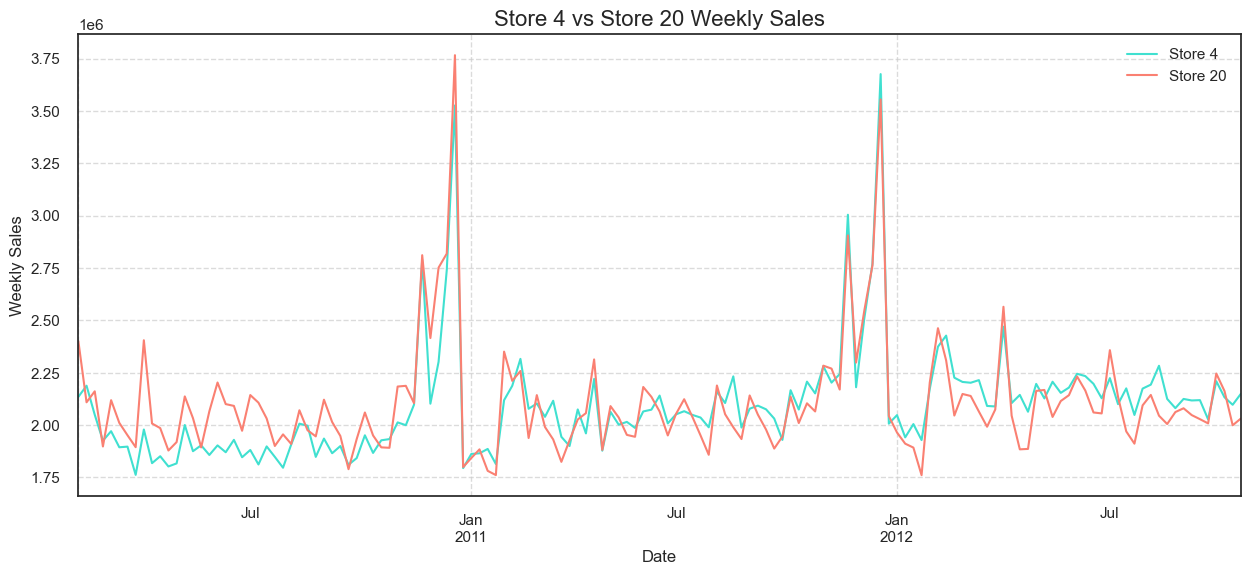

In [33]:
# Extract weekly sales data for Store 4 and Store 20
y4 = store4_sales.Weekly_Sales
y20 = sales20.Weekly_Sales

# Plot the weekly sales for both stores
plt.figure(figsize=(15, 6))
y4.plot(legend=True, color='turquoise', label='Store 4')
y20.plot(legend=True, color='salmon', label='Store 20')

plt.ylabel('Weekly Sales')
plt.title('Store 4 vs Store 20 Weekly Sales', fontsize=16)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

We see some similar trends. Hence, its a timeseries problem.

## MODELLING I : DEDICATED TIME SERIES MODEL

# SARIMA Overview

SARIMA (Seasonal AutoRegressive Integrated Moving Average) is a statistical model used for time series forecasting, extending the ARIMA (AutoRegressive Integrated Moving Average) model to handle seasonality in the data. While ARIMA models are useful for non-seasonal data, SARIMA models can also handle time series data that exhibit seasonal patterns by explicitly modeling the seasonal components.

## SARIMA Model Components

The SARIMA model is defined by the following general form:

$$
\text{SARIMA}(p, d, q)(P, D, Q)_s
$$

Where:

- **p**: The order of the autoregressive (AR) component. It indicates how many previous values (lags) of the time series are used to predict the current value.
- **d**: The degree of differencing. This helps make the time series stationary by removing trends. Differencing means subtracting a value from the previous one to stabilize the mean.
- **q**: The order of the moving average (MA) component. It represents the number of previous forecast errors used in the prediction.
- **P**: The order of the seasonal autoregressive (SAR) component. It represents the number of seasonal lags used in the model.
- **D**: The seasonal differencing order. This is similar to **d**, but instead of applying it to the whole series, it’s applied to seasonal differences (e.g., comparing a data point with the same data point from the previous season).
- **Q**: The order of the seasonal moving average (SMA) component. It represents the number of previous forecast errors at seasonal lags that are used in the model.
- **s**: The length of the seasonal cycle. For example, in monthly data with annual seasonality, **s = 12** because there are 12 months in a year.

## SARIMA Parameters in our Code

In this code, I'm fitting a SARIMA model to our time series data. Here’s an explanation of the typical parameters involved:

### AR (AutoRegressive):

This component is based on the premise that the current value of the time series depends on a weighted sum of its previous values. The number of previous values considered is specified by the parameter **p**.

In this case, the SARIMA model uses **p** lags (previous values) to predict the next value.

### Differencing (I - Integrated):

Differencing is applied to the time series to make it stationary. A stationary time series has constant statistical properties over time, such as a constant mean and variance. Differencing removes trends by subtracting the previous value of the series (and applying seasonal differencing if needed).

- **d** is the order of differencing. If the series is already stationary, **d = 0**; otherwise, a higher value might be chosen based on the characteristics of the series.
- **D** is used to apply seasonal differencing, which subtracts the value from the same season in the previous cycle (e.g., if you're modeling monthly data with yearly seasonality, you subtract the value from 12 months ago).

### MA (Moving Average):

This component models the dependency between an observation and a residual error from a moving average model applied to lagged observations. The order **q** specifies how many past forecast errors are taken into account in predicting future values.

In your model, **q** represents the number of past errors influencing the prediction.

### Seasonal Components (SAR, SMA):

Just like AR and MA components, SAR (Seasonal AR) and SMA (Seasonal MA) are applied specifically to the seasonal aspect of the time series. These components capture the seasonal dependencies that occur at fixed intervals (e.g., yearly, monthly).

- **P** represents the seasonal autoregressive order (how many past seasonal lags are considered for forecasting), and
- **Q** represents the seasonal moving average order (how many past forecast errors from seasonal lags are considered).

### Seasonal Period (s):

**s** is the number of observations per seasonal cycle. For example, in monthly data with yearly seasonality, **s = 12** because there are 12 months in a year.

## What I'm Doing in Code below

In the code, I am fitting a SARIMA model to time series data. Let's go through the process:

1. **Model Selection**: The choice of **p**, **d**, **q** and **P**, **D**, **Q** values is crucial for model fitting. You can use an automated process (e.g., AIC/BIC criteria, grid search, or domain knowledge) to determine the best parameters. I am using a grid search method here.
   
2. **Differencing**: Differencing is applied both at the regular level (**d**) and at the seasonal level (**D**). This helps make the series stationary and eliminates seasonality-induced trends. This is implicitly handled by SARIMA.
   
3. **Fitting the SARIMA Model**: You apply the SARIMA model to your time series data using the specified parameters. This involves estimating the parameters (AR, MA, SAR, SMA) and the seasonal period (**s**).

4. **Model Evaluation**: Once the model is fit, you evaluate its performance by checking residuals (errors) and other diagnostic metrics to ensure the model captures the underlying patterns effectively. You might use tools like ACF/PACF plots or statistical tests to check for autocorrelation in residuals.

5. **Forecasting**: After the SARIMA model is trained, it can be used to predict future values. This involves using the seasonal and non-seasonal components to forecast both long-term trends and periodic fluctuations.

## Theoretical Interpretation of SARIMA Output

Once we fit a SARIMA model and evaluate its parameters, the output can be interpreted as follows:

- **AR and MA Components**: The AR and MA terms explain how much the current value of the time series depends on its past values and past errors, respectively. These parameters tell you about the persistence of trends and how past errors affect future values.
  
- **Seasonal AR and MA**: The SAR and SMA components reflect how seasonal patterns repeat over fixed intervals. The significance of these components tells you how strong the periodic behavior is in your data.
  
- **Residuals**: The residuals represent the difference between the observed and predicted values. A good model should have small and random residuals (i.e., no significant pattern should be left in the residuals).
  
- **Diagnostic Checks**: After fitting the SARIMA model, you should always check the residuals to ensure the model has captured all the important information. This might include checking for autocorrelation or heteroscedasticity (variance changes over time) in the residuals.

## In Summary

SARIMA is a powerful model for forecasting time series data that exhibits both non-seasonal and seasonal patterns. By incorporating both seasonal and non-seasonal components, you can model time series with complex behaviors, such as trends and periodic fluctuations. Understanding and interpreting SARIMA’s parameters helps you build more accurate forecasts, detect patterns, and better understand the underlying structure of your data.


## Helpful Resources to Deepen Your Understanding of Seasonality and Trend Concepts in Time Series Analysis

- [Decompose Time Series Data into Trend and Seasonality](https://machinelearningmastery.com/decompose-time-series-data-trend-seasonality/)  
  This resource covers time series decomposition techniques, which are essential for identifying underlying trends and seasonal patterns in data.

- [SARIMA for Time Series Forecasting in Python](https://machinelearningmastery.com/sarima-for-time-series-forecasting-in-python/)  
  Learn how to implement SARIMA models to handle time series data with both trend and seasonality, providing a robust approach to forecasting.

These articles provide practical explanations and examples to help you better understand and apply these concepts.


### SARIMAX Overview

SARIMAX (Seasonal AutoRegressive Integrated Moving Average with eXogenous regressors) is an extension of the SARIMA model that allows the inclusion of external factors, or exogenous variables(e.g., marketing campaigns, weather data, economic indicators)., which may influence the target variable. This makes SARIMAX a powerful tool for forecasting time series data where external predictors play a role in shaping future values.

#### Components of SARIMAX
The SARIMAX model is represented as:

$$
\text{SARIMAX}(p, d, q)(P, D, Q)_s + X
$$

Where:
- **p, d, q**: Non-seasonal ARIMA parameters.
- **P, D, Q**: Seasonal ARIMA parameters.
- **s**: The length of the seasonal cycle (e.g., \( s = 12 \) for monthly data with yearly seasonality).
- **X**: Exogenous variables that influence the dependent variable.

#### Why Use SARIMAX?
1. **Incorporates External Factors**:
   - Unlike SARIMA, SARIMAX accounts for external influences, such as weather, promotions, or economic indicators.
   
2. **Improves Forecast Accuracy**:
   - By including relevant exogenous predictors, SARIMAX enhances the predictive power of the model.
   
3. **Handles Complex Time Series**:
   - SARIMAX can capture both internal dynamics (seasonal and non-seasonal patterns) and external effects.

#### Applications
- **Energy Demand Forecasting**: Including temperature and weather data.
- **Sales Forecasting**: Factoring in marketing spend or economic conditions.
- **Healthcare Predictions**: Modeling disease outbreaks with environmental or demographic data.

#### Key Differences Between SARIMA and SARIMAX
| Feature              | SARIMA                           | SARIMAX                                |
|----------------------|-----------------------------------|----------------------------------------|
| Seasonal Components  | Yes                              | Yes                                    |
| Non-Seasonal Trends  | Yes                              | Yes                                    |
| Exogenous Variables  | No                               | Yes (adds external predictors)         |
| Use Cases            | Pure time series analysis        | Time series influenced by external data|

#### Example Use Case
1. **SARIMA**:
   - Forecasting monthly electricity consumption based solely on historical consumption data.
2. **SARIMAX**:
   - Forecasting electricity consumption while incorporating temperature as an exogenous variable to improve accuracy.

By combining seasonality, non-seasonality, and external regressors, SARIMAX provides a comprehensive approach to time series forecasting, making it ideal for scenarios where external factors significantly influence the target variable.

**I will be using SARIMAX for this data as its more suitable.**


In [ ]:
# ## THIS CODE CAN BE USED TO FIND THE OPTIMAL PARAMETERS THROUGH ITERATIONS.
# ## HOWEVER, IT TAKES A CONSIDERABLE AMOUNT OF TIME EVEN FOR THESE 10 ITERATIONS.
# ## THEREFORE, IN THIS NOTEBOOK, I AM USING THE PARAMETERS THAT WORKED BEST BASED ON MANUAL TRIALS 
# ## TO MAKE THE NOTEBOOK RUN FASTER.

# # Assuming `y4` is the time series data being analyzed.
# # Ensuring that `y4` is a pandas DataFrame or Series.

# # Setting the date range for the time series data `y4`.
# # Replace "2010-02-05" with the actual start date of your dataset.
# y4.index = pd.date_range(start="2010-02-05", periods=len(y4), freq='W-FRI')  # Weekly frequency on Fridays.

# # Defining the ARIMA model parameters: p, d, and q.
# # Each of these parameters can take values between 0 and 4.
# p = d = q = range(0, 5)  # Range from 0 to 4 for all three parameters.

# # Generating all possible combinations of (p, d, q) using itertools.product.
# pdq = list(itertools.product(p, d, q))  # List of tuples for non-seasonal parameters.

# # Generating seasonal parameter combinations (p, d, q, s).
# # Here, s=52 is the seasonal period (assumes weekly data spanning a year).
# seasonal_pdq = [(x[0], x[1], x[2], 52) for x in list(itertools.product(p, d, q))]

# # Specifying the number of iterations for the Randomized Search process.
# # This limits the number of parameter combinations tested to save time.
# num_iterations = 10  # Run 10 iterations for parameter optimization.

# # Randomly sampling `num_iterations` combinations from `pdq`.
# random_pdq = random.sample(pdq, num_iterations)  # Random sampling for non-seasonal parameters.
# random_seasonal_pdq = random.sample(seasonal_pdq, num_iterations)  # Random sampling for seasonal parameters.

# # Initializing variables to keep track of the best model and its parameters.
# best_aic = float("inf")  # Initializing AIC (Akaike Information Criterion) to a very high value.
# best_params = None  # To store the best combination of non-seasonal parameters.
# best_seasonal_params = None  # To store the best combination of seasonal parameters.
# best_model = None  # To store the best SARIMA model object.

# # Looping through the randomly sampled non-seasonal parameters (`random_pdq`).
# for param in random_pdq:
#     # Looping through the randomly sampled seasonal parameters (`random_seasonal_pdq`).
#     for seasonal_param in random_seasonal_pdq:
#         try:
#             # Creating a SARIMA model with the current parameter combination.
#             mod = sm.tsa.statespace.SARIMAX(
#                 y4,  # The time series data.
#                 order=param,  # Current non-seasonal parameters (p, d, q).
#                 seasonal_order=seasonal_param,  # Current seasonal parameters (p, d, q, s).
#                 enforce_invertibility=False  # Relax invertibility constraints for broader parameter exploration.
#             )
            
#             # Fitting the SARIMA model.
#             results = mod.fit()  # Fit the model using maximum likelihood estimation.

#             # Checking if the AIC of the current model is lower than the best AIC found so far.
#             if results.aic < best_aic:
#                 best_aic = results.aic  # Update the best AIC value.
#                 best_params = param  # Update the best non-seasonal parameters.
#                 best_seasonal_params = seasonal_param  # Update the best seasonal parameters.
#                 best_model = results  # Store the best SARIMA model.

#         # Catching exceptions (e.g., non-stationarity or convergence issues) and skipping invalid combinations.
#         except Exception as e:
#             continue  # Skip to the next iteration if an error occurs.

# # Printing the best parameters and the corresponding AIC for reference.
# print(f"Best AIC: {best_aic}")  # Display the lowest AIC value found.
# print(f"Best Non-seasonal Params: {best_params}")  # Display the best non-seasonal parameters.
# print(f"Best Seasonal Params: {best_seasonal_params}")  # Display the best seasonal parameters.

# # Plotting diagnostics for the best SARIMA model to evaluate its fit.
# plt.style.use('seaborn-v0_8-pastel')  # Set a clean and readable style for the plots.
# best_model.plot_diagnostics(figsize=(15, 12))  # Generate diagnostic plots for the best model.
# plt.show()  # Display the plots.


In [34]:

# Define the arima p, d and q parameters to take any value between 0 and 4.
p = d = q = range(0, 5)

# Generate all different combinations of p, d and q triplets
pdq = list(itertools.product(p, d, q))

# Generating seasonal combinations p, d and q triplets, here, s=52, assuming weekly data over a year
seasonal_pdq = [(x[0], x[1], x[2], 52) for x in list(itertools.product(p, d, q))]

In [35]:
#I'm using SARIMAX model from the statsmodels library, which is used to model time series data.

In [36]:
#Plotting Diagnostic Charts

mod = sm.tsa.statespace.SARIMAX(y4,
                                order=(4, 4, 3),
                                seasonal_order=(1, 1, 0, 52),   #enforce_stationarity=False,
                                enforce_invertibility=False)

results = mod.fit()

print(results.summary().tables[1])

C:\Users\91939\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency W-FRI will be used.

C:\Users\91939\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency W-FRI will be used.

C:\Users\91939\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals



                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.7582      0.539     -3.261      0.001      -2.815      -0.702
ar.L2         -1.3004      0.581     -2.238      0.025      -2.439      -0.162
ar.L3         -0.5991      0.252     -2.374      0.018      -1.094      -0.104
ar.L4         -0.1893      0.091     -2.085      0.037      -0.367      -0.011
ma.L1         -1.3739      0.491     -2.797      0.005      -2.337      -0.411
ma.L2         -0.2279      1.054     -0.216      0.829      -2.294       1.839
ma.L3          0.6060      0.587      1.032      0.302      -0.545       1.757
ar.S.L52      -0.0682      0.048     -1.415      0.157      -0.163       0.026
sigma2      1.622e+10   6.56e-11   2.47e+20      0.000    1.62e+10    1.62e+10


### Model Interpretation and Improvements

Here’s a summary of the key findings from the model results:

1. **Coef (Coefficient)**: These represent the estimated values for each parameter. 
   - `ar.L1 = -1.7582`: The model's value at time `t` is influenced by the value at time `t-1`, scaled by -1.7582.
   - `ma.L1 = -1.3739`: Reflects the weighted error from the previous time step.

2. **Std Err (Standard Error)**: Measures the accuracy of the coefficient estimate. Smaller values indicate more precision. For example, `ar.L1` has a standard error of 0.539, suggesting a fairly reliable estimate.

3. **Z-Value**: The z-value tests if the coefficient is significantly different from zero. A large z-value indicates statistical significance. For `ar.L1`, the z-value is -3.261, suggesting it is significant.

4. **P-Value**: Tests the null hypothesis that the coefficient is zero. A p-value less than 0.05 indicates statistical significance. For `ar.L1`, the p-value is 0.001, so it is significant. However, `ma.L2` (p-value = 0.829) is not significant.

5. **Confidence Interval [0.025, 0.975]**: Shows the range within which the true parameter value is likely to fall with 95% certainty. For `ar.L1`, the confidence interval is between -2.815 and -0.702, meaning we are 95% confident the true value lies within this range.

### Key Points:
- **Significant Parameters**: `ar.L1`, `ar.L2`, `ar.L3`, `ar.L4`, and `ma.L1` are significant, with p-values less than 0.05.
- **Non-Significant Parameters**: `ma.L2` and `ma.L3` are not significant and could potentially be removed.
- **Seasonal Component**: The seasonal autoregressive term `ar.S.L52` has a p-value of 0.157, suggesting it may not be significant but is close to the threshold.
- **Sigma2**: The high value of `sigma2 (1.622e+10)` indicates substantial unexplained variability or potential overfitting.

### Conclusion:
The model has significant autoregressive and moving average terms. To improve it further, focus on refining the model by removing non-significant terms, such as `ma.L2`, `ma.L3`, and potentially `ar.S.L52`, as well as adjusting the model to reduce residual variance.


#### plot_diagnostics: 

After fitting the model (results), this method plots diagnostic charts for checking the residuals of the model. It helps us identify if the model's residuals (errors) are well-behaved (i.e., normally distributed, constant variance, etc.).
The figsize argument adjusts the plot size, and plt.show() displays the plots.

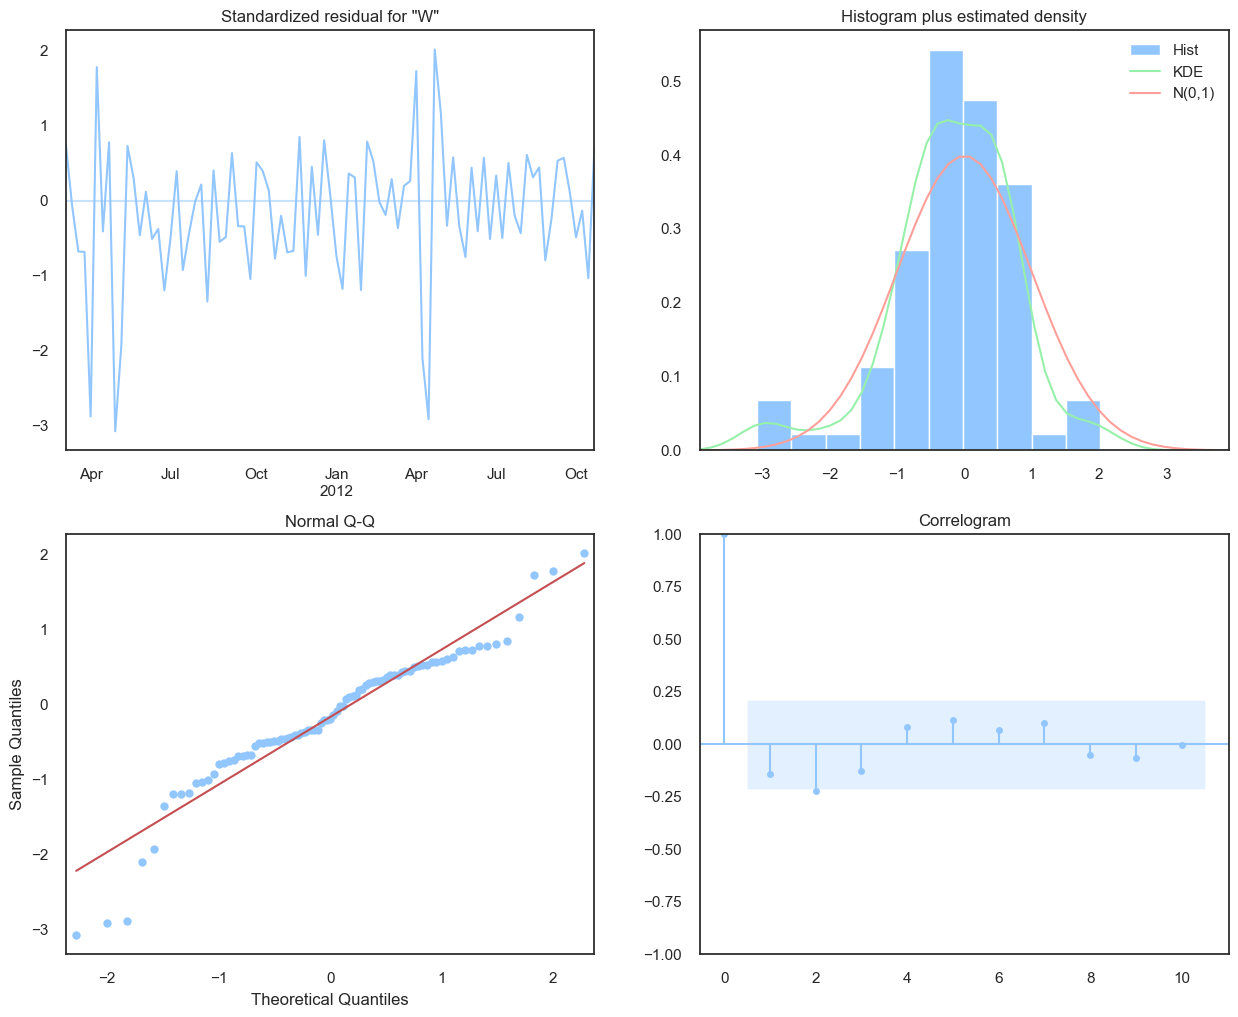

In [37]:
plt.style.use('seaborn-v0_8-pastel')
results.plot_diagnostics(figsize=(15, 12))
plt.show()

### Model Diagnostics

- **Time Series Plot**  
  The standardized residual plot (top left) shows fluctuations mostly between -2 and 2, with a few outliers reaching -3. The residuals appear to oscillate around zero, suggesting generally stable variance over time.

- **Distribution Check**  
  The histogram with density plot (top right) indicates that the residuals follow an approximately normal distribution, with:
  - A roughly bell-shaped curve
  - Slight right skewness
  - Good alignment between the empirical distribution (blue bars) and theoretical normal distribution (red line)

- **Normal Q-Q Plot**  
  The Q-Q plot (bottom left) shows:
  - Good alignment with the diagonal line in the middle range
  - Some deviation at the tails, particularly at the extreme values
  - This suggests mostly normal distribution with slightly heavy tails

- **Correlogram**  
  The correlogram (bottom right) demonstrates:
  - No significant autocorrelation in the residuals
  - Values staying within the confidence bands (blue shaded area)
  - This indicates that the model has captured most of the temporal dependencies in the data

### Conclusion
Overall, these diagnostics suggest a reasonably well-fitted SARIMA model, though there might be room for minor improvements in handling extreme values.


Making Predictions

In [38]:
#Predict for the last 90 days
forecast_start_date = pd.to_datetime('2012-07-27')
pred = results.get_prediction(start=forecast_start_date, dynamic=False)
pred_ci = pred.conf_int()

### Prediction and Confidence Intervals

- **`get_prediction(start=...)`**: This method generates predictions from the fitted SARIMAX model. In this case, the model predicts values starting from `2012-07-27`.
  
  - **`dynamic=False`**: This means the model uses only the historical data up to the forecast period (i.e., no rolling forecast).

- **`conf_int()`**: This method retrieves the confidence intervals for the predicted values, providing the range of uncertainty around the forecasted values.


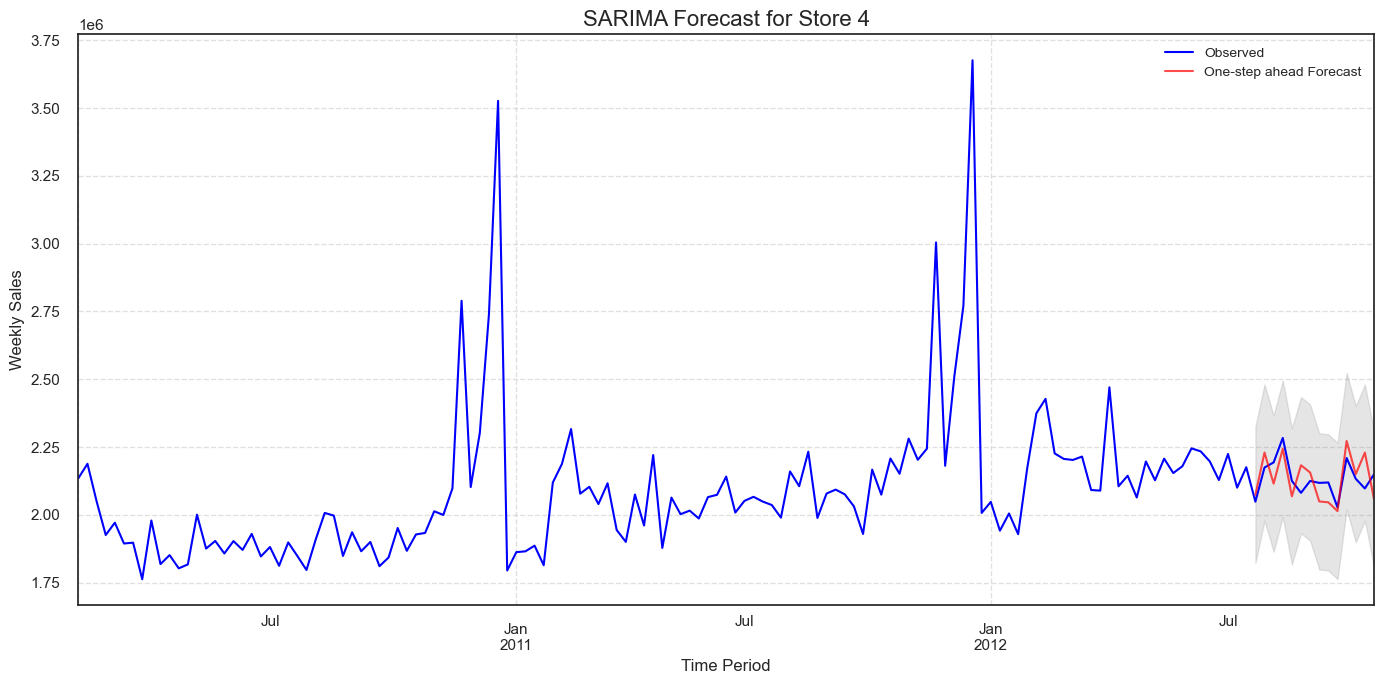

In [39]:
plt.figure(figsize=(14, 7))
ax = y4['2010':].plot(label='Observed', color='blue')
pred.predicted_mean.plot(ax=ax, label='One-step ahead Forecast', color='red', alpha=0.7)
ax.fill_between(pred_ci.index,
pred_ci.iloc[:, 0],
pred_ci.iloc[:, 1], color='gray', alpha=0.2)
ax.set_xlabel('Time Period', fontsize=12)
ax.set_ylabel('Weekly Sales', fontsize=12)
ax.set_title('SARIMA Forecast for Store 4', fontsize=16)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Strengths
- **Seasonal Peaks:** Accurately captures major seasonal peaks around January (3.5M sales).  
- **Baseline Stability:** Maintains stable baseline predictions around 2M sales.  
- **Residual Diagnostics:** Shows good residual normality and lack of autocorrelation.  
- **Trend Modeling:** Effectively models both short-term fluctuations and long-term trends.  

### Areas for Improvement
- The model shows some limitations in handling extreme values, particularly during the holiday season peaks where it slightly underestimates the magnitude of sales spikes.  
- Increased uncertainty bands during these periods highlight areas where the model could be refined.  
- These limitations are typical for retail forecasting models dealing with holiday seasonality.  


In [40]:
y_forecasted = pred.predicted_mean
y_truth = y4['2012-7-27':]

rmse = np.sqrt(((y_forecasted - y_truth) ** 2).mean())
print('The Root Mean Squared Error of our forecasts is {}'.format(round(rmse, 2)))

The Root Mean Squared Error of our forecasts is 68850.66


MSE is computed by comparing the forecasted values (y_forecasted) with the actual observed values (y_truth) for the period starting from '2012-07-27'.
The difference between forecasted and actual values is squared, and the mean is taken. The result gives a measure of the model's accuracy, with lower MSE indicating better performance.

In [41]:
pred_dynamic = results.get_prediction(start=pd.to_datetime('2012-7-27'), dynamic=True, full_results=True)
pred_dynamic_ci = pred_dynamic.conf_int()

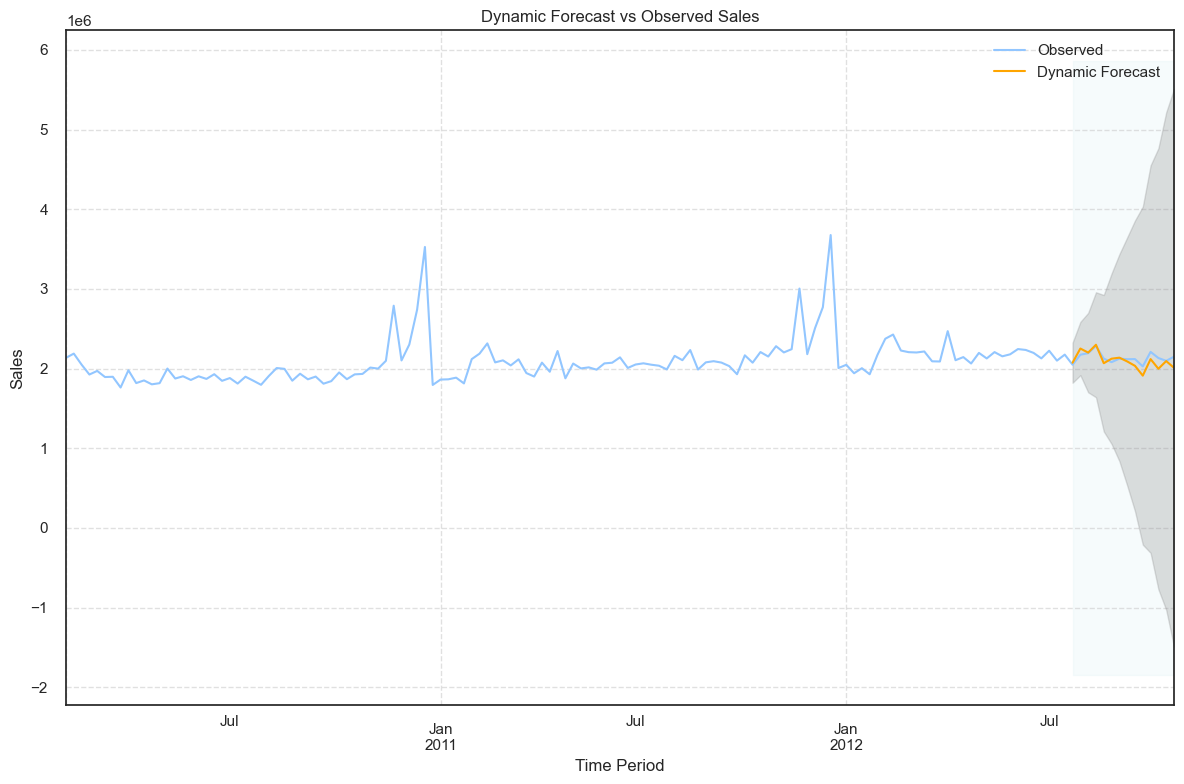

In [42]:
# Plot observed sales from 2010 onward
ax = y4['2010':].plot(label='Observed', figsize=(12, 8))

# Plot dynamic forecast
pred_dynamic.predicted_mean.plot(label='Dynamic Forecast', ax=ax, color='orange')

# Add confidence intervals for the dynamic forecast
ax.fill_between(pred_dynamic_ci.index,
                pred_dynamic_ci.iloc[:, 0],
                pred_dynamic_ci.iloc[:, 1], color='gray', alpha=0.25)

# Highlight the area after the last observed date
ax.fill_betweenx(ax.get_ylim(), pd.to_datetime('2012-7-26'), y4.index[-1],
                 alpha=0.1, zorder=-1, color='lightblue')

# Add labels and legend
ax.set_xlabel('Time Period')
ax.set_ylabel('Sales')
plt.title('Dynamic Forecast vs Observed Sales')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Show the plot
plt.tight_layout()
plt.show()

### Long-term Prediction
- **Dynamic Forecast:** The dynamic forecast (yellow line) shows more conservative predictions around 2 million in sales.  
- **Confidence Intervals:**  
  - Much wider confidence intervals (gray shaded area) indicate higher uncertainty in long-term forecasting.  
  - Less ability to capture extreme seasonal spikes compared to the one-step-ahead forecast.  

### Uncertainty Handling
- The confidence bands expand dramatically over time, reflecting increasing forecast uncertainty.  
- At the furthest forecast point, the bands range from nearly -2 million to 6 million sales.  
- This growing uncertainty is typical for dynamic forecasts, as they rely on their own previous predictions rather than actual values.  

### Key Limitation
- The dynamic forecast struggles to predict sharp holiday season spikes and shows significantly more uncertainty compared to the one-step-ahead forecast.  
- However, it maintains a reasonable baseline prediction around the average sales level of 2 million.  


In [43]:
# Extract the predicted and true values of our time series
y_forecasted = pred_dynamic.predicted_mean

y_truth = y4['2012-7-27':]

# Compute the Root mean square error
rmse = np.sqrt(((y_forecasted - y_truth) ** 2).mean())
print('The Root Mean Squared Error of our forecasts is {}'.format(round(rmse, 2)))

The Root Mean Squared Error of our forecasts is 75373.67


In [44]:
Residual= y_forecasted - y_truth
print("Residual for Store4",np.abs(Residual).sum())

Residual for Store4 835259.1771163852


In [45]:
# Get forecast 12 weeks ahead in future
pred_uc = results.get_forecast(steps=12)

# Get confidence intervals of forecasts
pred_ci = pred_uc.conf_int()

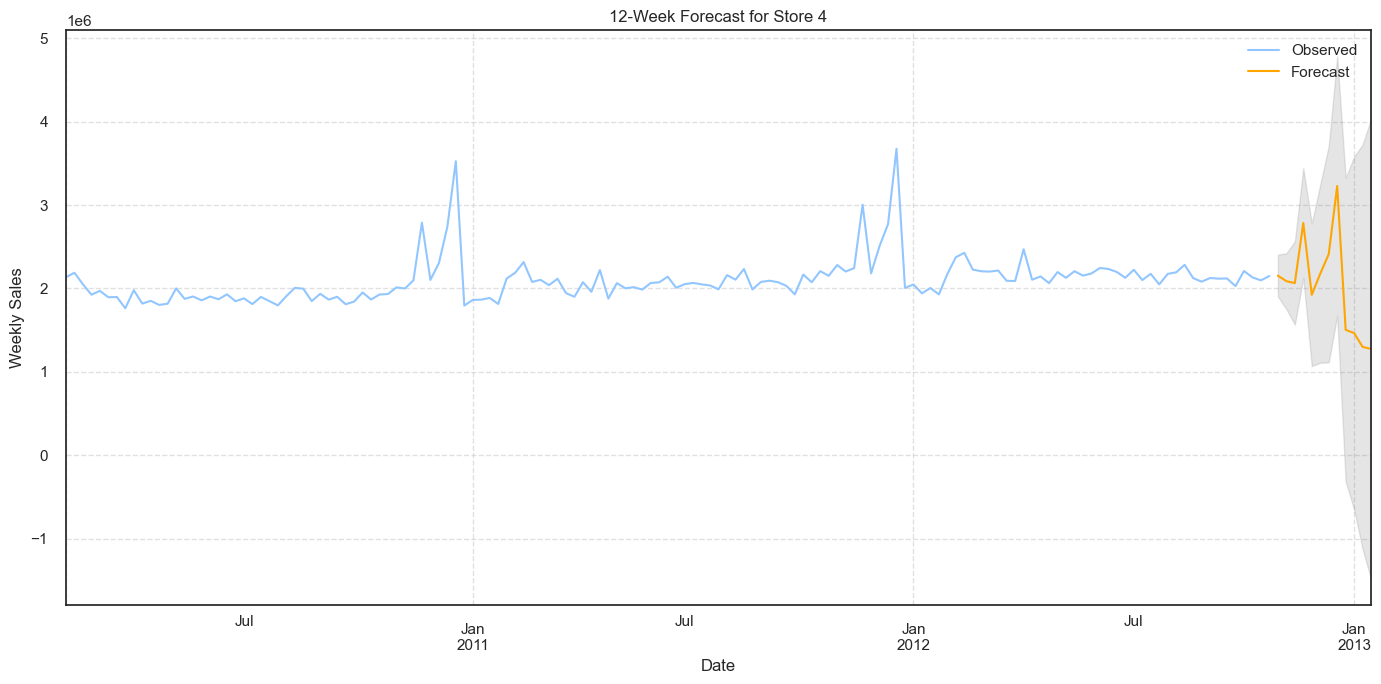

In [46]:
# Get forecast for 12 weeks ahead
pred_uc = results.get_forecast(steps=12)

# Get confidence intervals
pred_ci = pred_uc.conf_int()

# Plot observed data
ax = y4.plot(label='Observed', figsize=(14, 7))

# Plot forecasted values
pred_uc.predicted_mean.plot(ax=ax, label='Forecast', color='orange')

# Plot confidence intervals
ax.fill_between(pred_ci.index,
                pred_ci.iloc[:, 0],
                pred_ci.iloc[:, 1], color='gray', alpha=0.2)

ax.set_xlabel('Date')
ax.set_ylabel('Weekly Sales')
plt.title('12-Week Forecast for Store 4')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

The error range seems to be very big. But if we just check the green line prediction this is almost like earlier years. If we look for may be first 2 weeks the prediction is way better and error is also low.

## MODELLING II: MACHINE LEARNING WITH TIME FEATURES

### UNDERSTING DATA and VIZUALIZATIONS

   Store       Date  Weekly_Sales Type    Size  Temperature  Fuel_Price  \
0      1 2010-02-05    1643690.90    A  151315        42.31       2.572   
1      1 2010-02-12    1641957.44    A  151315        38.51       2.548   
2      1 2010-02-19    1611968.17    A  151315        39.93       2.514   
3      1 2010-02-26    1409727.59    A  151315        46.63       2.561   
4      1 2010-03-05    1554806.68    A  151315        46.50       2.625   

   MarkDown1  MarkDown2  MarkDown3  ...         CPI  Unemployment  \
0     -999.0     -999.0     -999.0  ...  211.096358         8.106   
1     -999.0     -999.0     -999.0  ...  211.242170         8.106   
2     -999.0     -999.0     -999.0  ...  211.289143         8.106   
3     -999.0     -999.0     -999.0  ...  211.319643         8.106   
4     -999.0     -999.0     -999.0  ...  211.350143         8.106   

   Holiday_Flag  Day  Month  Year Week  Type_A  Type_B  Type_C  
0             0    5    Feb  2010    5    True   False   False  
1   

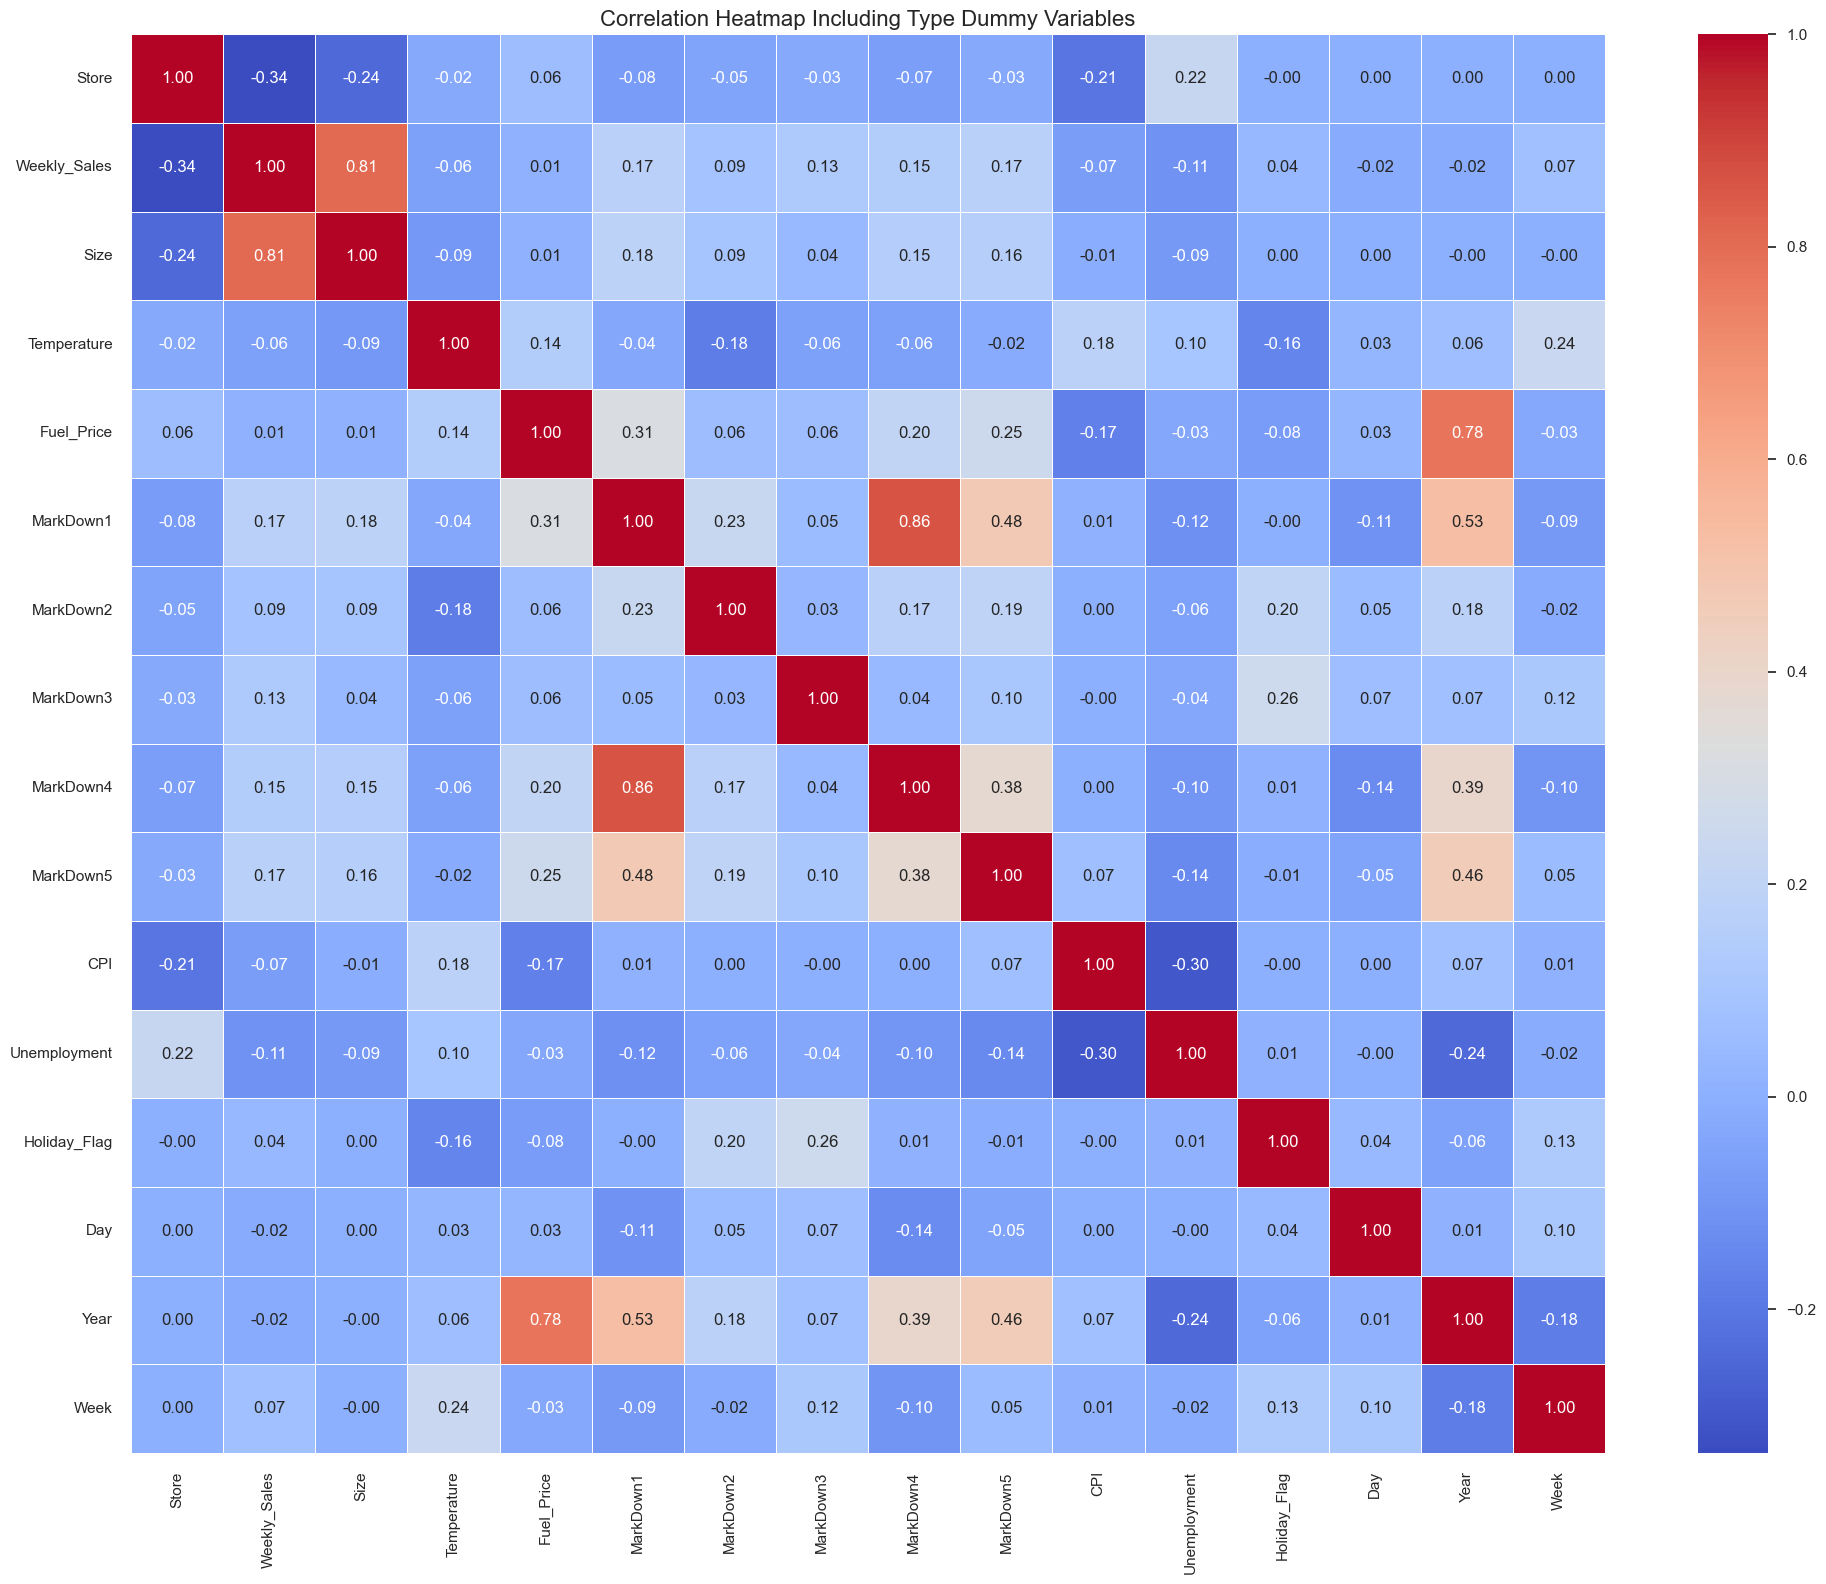


Correlations with Weekly_Sales:
Weekly_Sales    1.000000
Size            0.810468
MarkDown1       0.173481
MarkDown5       0.165620
MarkDown4       0.148568
MarkDown3       0.126423
MarkDown2       0.087914
Week            0.074211
Holiday_Flag    0.036891
Fuel_Price      0.009464
Day            -0.017409
Year           -0.018378
Temperature    -0.063810
CPI            -0.072634
Unemployment   -0.106176
Store          -0.335332
Name: Weekly_Sales, dtype: float64


In [47]:
#CORRELATION ANALYSIS

# Create dummy variables for 'Type'
type_dummies = pd.get_dummies(final_dataset.Type, prefix='Type')

# Concatenate the dummy variables with the original DataFrame
final_dataset = pd.concat([final_dataset, type_dummies], axis=1)

# Display the first few rows to verify the changes
print(final_dataset.head())

# Check the new shape of the DataFrame
print("\nNew DataFrame shape:", final_dataset.shape)

# List all column names to confirm the addition of dummy variables
print("\nUpdated column list:")
print(final_dataset.columns.tolist())

# Calculate the correlation matrix
correlation_matrix = final_dataset.select_dtypes(include=[np.number]).corr()

# Create a heatmap of the correlation matrix
plt.figure(figsize=(20, 16))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5, fmt='.2f')
plt.title('Correlation Heatmap Including Type Dummy Variables', fontsize=16)
plt.tight_layout()
plt.show()

# Print correlations with Weekly_Sales
sales_correlations = correlation_matrix['Weekly_Sales'].sort_values(ascending=False)
print("\nCorrelations with Weekly_Sales:")
print(sales_correlations)


### Inferences:
- There is a high correlation between store size and weekly sales, which makes sense as larger stores typically have more space to offer products and thus generate higher sales.
  
- The correlation between markdowns could be due to the imputation we performed, as it might have affected the data structure and relationships.

- The high correlation between year and fuel price could be attributed to the general trend that fuel prices tend to increase over time due to inflation and other economic factors.


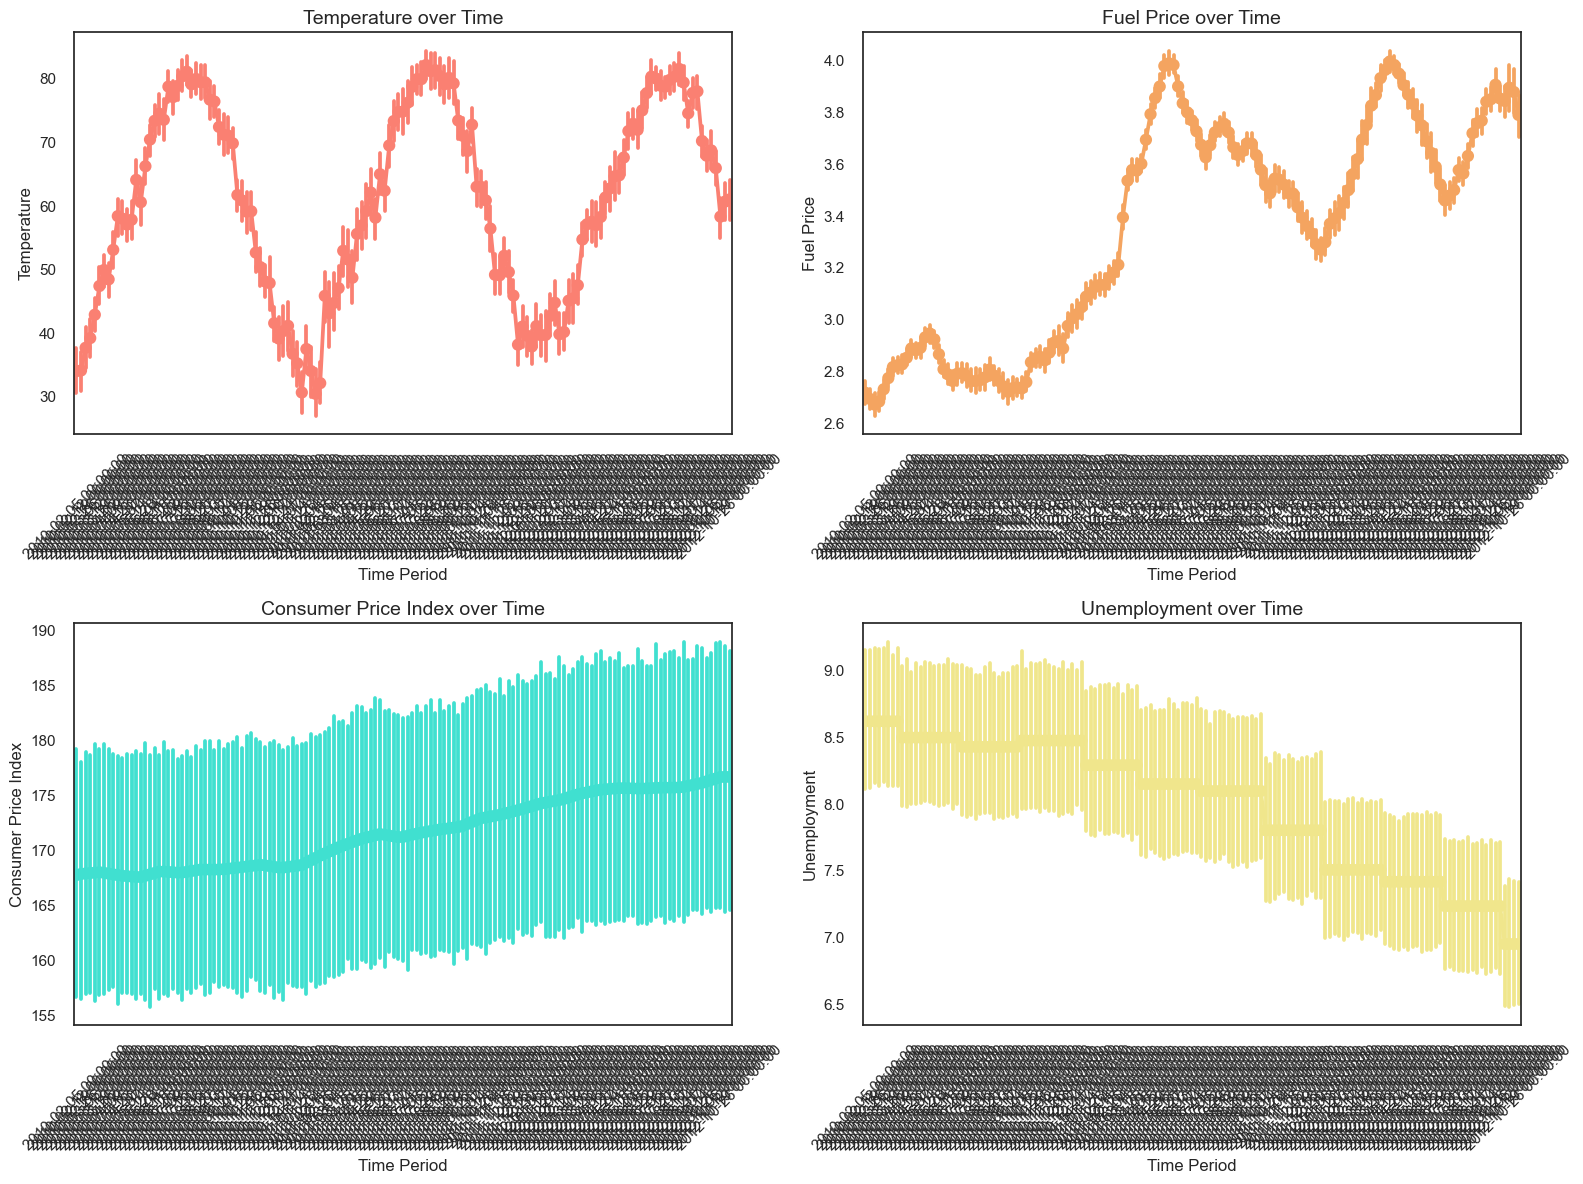

In [48]:
# EXTERNAL FACTORS VS TIME

# Set up the figure and axes for 4 subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Temperature over Time
sns.pointplot(ax=axes[0, 0], x="Date", y="Temperature", data=final_dataset, color='salmon')
axes[0, 0].set_title('Temperature over Time', fontsize=14)
axes[0, 0].set_xlabel('Time Period', fontsize=12)
axes[0, 0].set_ylabel('Temperature', fontsize=12)
axes[0, 0].tick_params(axis='x', rotation=45)

# Fuel Price over Time
sns.pointplot(ax=axes[0, 1], x="Date", y="Fuel_Price", data=final_dataset, color='sandybrown')
axes[0, 1].set_title('Fuel Price over Time', fontsize=14)
axes[0, 1].set_xlabel('Time Period', fontsize=12)
axes[0, 1].set_ylabel('Fuel Price', fontsize=12)
axes[0, 1].tick_params(axis='x', rotation=45)

# Consumer Price Index (CPI) over Time
sns.pointplot(ax=axes[1, 0], x="Date", y="CPI", data=final_dataset, color='turquoise')
axes[1, 0].set_title('Consumer Price Index over Time', fontsize=14)
axes[1, 0].set_xlabel('Time Period', fontsize=12)
axes[1, 0].set_ylabel('Consumer Price Index', fontsize=12)
axes[1, 0].tick_params(axis='x', rotation=45)

# Unemployment over Time
sns.pointplot(ax=axes[1, 1], x="Date", y="Unemployment", data=final_dataset, color='khaki')
axes[1, 1].set_title('Unemployment over Time', fontsize=14)
axes[1, 1].set_xlabel('Time Period', fontsize=12)
axes[1, 1].set_ylabel('Unemployment', fontsize=12)
axes[1, 1].tick_params(axis='x', rotation=45)

# Adjust layout and show the plots
plt.tight_layout()
plt.show()


### Inferences: Features Change Significantly Over Time

#### Temperature Over Time
- The graph demonstrates a **clear seasonal pattern**, with temperature cycling over time.
- This suggests that temperature is a **significant feature** and could be used to analyze its impact on sales trends.

#### Fuel Price Over Time
- Fuel prices show **noticeable highs and lows**, fluctuating significantly over time.
- These variations might influence **consumer behavior** and **sales trends**, making it a potential factor for further analysis.

#### Consumer Price Index (CPI) Over Time
- CPI has exhibited a **gradual increase** over time, with changes being relatively **small but consistent**.
- This implies that CPI might have a **limited but steady impact** on sales trends.

#### Unemployment Over Time
- The graph indicates that unemployment has **generally decreased** over time.
- Further analysis could reveal whether this trend correlates with an **increase in sales** or changes in **consumer spending**.


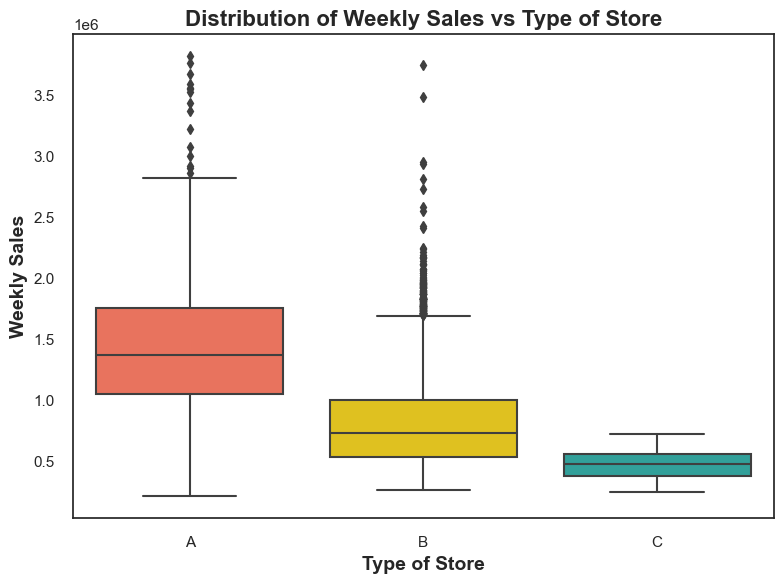

In [49]:
# STORE TYPE VS WEEKLY SALES
plt.figure(figsize=(8, 6))

# Create the boxplot with custom colors for each store type
sns.boxplot(x="Type", y="Weekly_Sales", data=final_dataset, palette=['#FF6347', '#FFD700', '#20B2AA'])

# Adding labels and title with updated font sizes
plt.xlabel('Type of Store', fontsize=14, weight='bold')
plt.ylabel('Weekly Sales', fontsize=14, weight='bold')
plt.title('Distribution of Weekly Sales vs Type of Store', fontsize=16, weight='bold')

# Adjust layout and display the plot
plt.tight_layout()
plt.show()



### Inference

- From the graph, we observe the **spread of weekly sales** for each store type, along with any outliers.
- It is clear that the mean weekly sales follow the order: **Type A > Type B > Type C**.
- Outliers are present in **Type A** and **Type B**, indicating occasional extreme sales values for these store types.


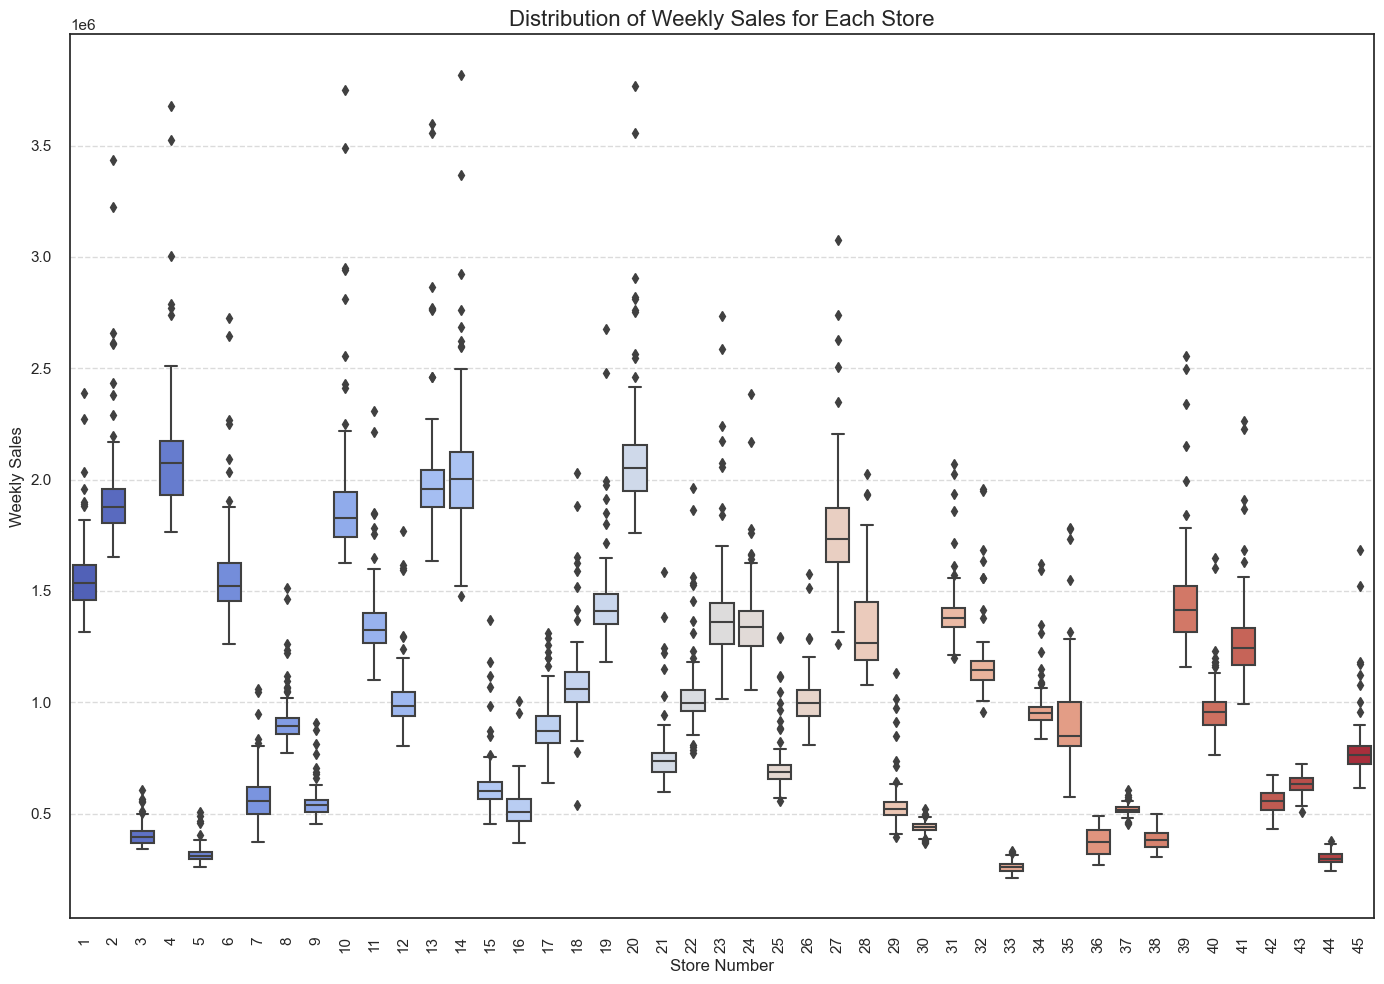

In [50]:
# STORE NUMBER VS WEEKLY SALES

# Boxplot for Mean Weekly Sales of Each Store
plt.figure(figsize=(14, 10))
sns.boxplot(x="Store", y="Weekly_Sales", data=final_dataset, palette="coolwarm")

# Adding labels and title
plt.xlabel('Store Number', fontsize=12)
plt.ylabel('Weekly Sales', fontsize=12)
plt.title('Distribution of Weekly Sales for Each Store', fontsize=16)

# Rotating x-axis labels for better readability
plt.xticks(rotation=90)

# Adding gridlines for clarity
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()



### Inference

- **Store 20** has the highest sales, followed by **Store 4**.


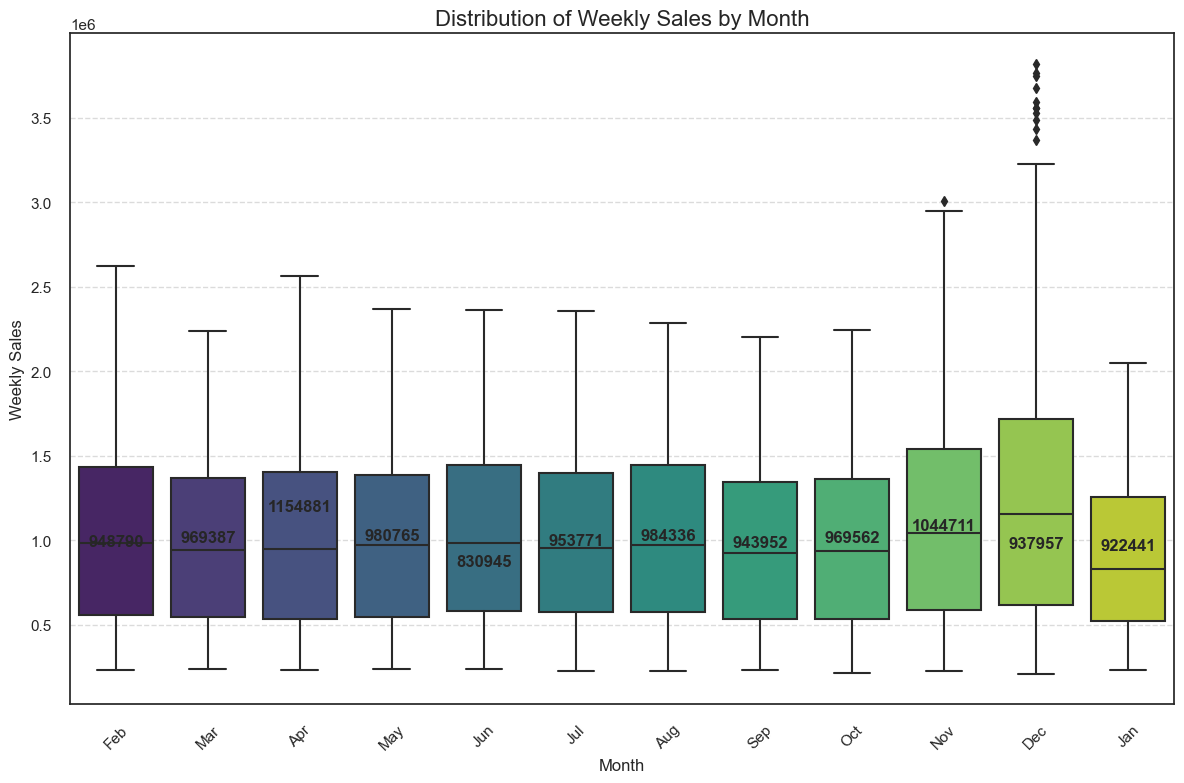

In [51]:
# MONTH VS WEEKLY SALES

# Boxplot for Weekly Sales by Month
plt.figure(figsize=(12, 8))

# Create the boxplot with the 'viridis' color palette
sns.boxplot(x="Month", y="Weekly_Sales", data=final_dataset, palette="viridis")

# Adding labels and title
plt.xlabel('Month', fontsize=12)
plt.ylabel('Weekly Sales', fontsize=12)
plt.title('Distribution of Weekly Sales by Month', fontsize=16)

# Rotating x-axis labels for better readability
plt.xticks(rotation=45)

# Adding gridlines for clarity
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Calculate and annotate median values for each month
medians = final_dataset.groupby('Month')['Weekly_Sales'].median()
for i, median in enumerate(medians):
    plt.text(i, median, f'{median:.0f}', ha='center', va='bottom', fontweight='bold')

# Adjust layout for better appearance
plt.tight_layout()

# Show the plot
plt.show()

### Inference

- The graph shows **monthly sales trends**, with **December** having the **highest sales** compared to all other months.
- **January** exhibits the **lowest sales**, indicating a sharp contrast in consumer activity between the two months.


### FEATURE ENGINEERING

### Feature Engineering and Data Preparation

Before building and running the model, we will examine the dataset to identify and create meaningful features. The key steps include:

#### 1. Creating Dummy Variables
To effectively represent categorical data, we will generate dummy variables for the following columns:
- **Store**: Representing different stores in a one-hot encoded format.
- **Week**: Adds granularity to capture weekly trends.
- **Month**: Capturing the seasonal effect of each month.
- **Year**: Differentiating between years in the dataset.

  Benefits 
- **Improved Interpretability**: Transforming cyclical time data into discrete features makes it easier for linear models to interpret and learn.
- **Seasonal Pattern Detection**: Enables the model to recognize recurring trends, such as peak sales during holidays or slow periods.

This practice is common in time series analysis and plays a key role in boosting model performance. 
#### 2. Handling Missing Values
We will address missing data, particularly in the **Markdown1 to Markdown5** columns:
- **KNN Imputation** will be used to handle missing values. 

These steps are essential for preparing the data and ensuring optimal model performance.


#### ENCODING TIME FEATURES

In [52]:
# Create dummies for the required columns
store_dummies = pd.get_dummies(final_dataset.Store, prefix='Store')
month_dummies = pd.get_dummies(final_dataset.Month, prefix='Month')
year_dummies = pd.get_dummies(final_dataset.Year, prefix='Year')
week_dummies = pd.get_dummies(final_dataset.Week, prefix='Week')

# Concatenate the dummy variables with the original DataFrame
final_dataset = pd.concat([final_dataset, store_dummies, month_dummies, year_dummies, week_dummies], axis=1)

In [53]:
# Drop the columns that we have created dummies
final_dataset.drop(['Type', 'Store','Month','Year','Day','Week'], axis=1, inplace=True) 

In [54]:
final_dataset.columns

Index(['Date', 'Weekly_Sales', 'Size', 'Temperature', 'Fuel_Price',
       'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5',
       ...
       'Week_43', 'Week_44', 'Week_45', 'Week_46', 'Week_47', 'Week_48',
       'Week_49', 'Week_50', 'Week_51', 'Week_52'],
      dtype='object', length=128)

In [55]:
# drop each column from the list of dummies to make it perfect to use in models
final_dataset.drop(['Type_C', 'Store_1','Month_Jan','Year_2010','Week_52'], axis=1, inplace=True)

Next, we will perform KNN (K Nearest Neighbours) imputation for Markdown columns.

In [56]:
final_dataset.iloc[:,5:10].describe().T

,count,mean,std,min,25%,50%,75%,max
MarkDown1,6435.0,1783.977364,6151.156782,-999.0,-999.0,-999.0,2302.300,88646.76
MarkDown2,6435.0,74.008474,5021.610057,-999.0,-999.0,-999.0,0.090,104519.54
MarkDown3,6435.0,-252.185193,5348.968182,-999.0,-999.0,-999.0,3.705,141630.61
MarkDown4,6435.0,314.926379,3962.856542,-999.0,-999.0,-999.0,314.320,67474.85
MarkDown5,6435.0,939.093526,4365.531996,-999.0,-999.0,-999.0,1983.265,108519.28


In [57]:
# Inference: more than 50% is missing values with (-999) so imputing with KNN might not be a good idea. 
#Replace -999 with NaN in MarkDown columns
missing_cols = ['MarkDown1','MarkDown2','MarkDown3','MarkDown4','MarkDown5']
for column in missing_cols:
    final_dataset[column] = final_dataset[column].map(lambda x: np.nan if x == -999 else x)

#### MISSING DATA IMPUTATION USING KNN

In [58]:
# Imputation Logic
# Not including our actual y(Weekly Sales) and Size of store for Markdown since by including weekly sales
# It can be a bad method to use those MarkDown again for predicting weekly sales. 

impute_cols = [c for c in final_dataset.columns if c not in ['Weekly_Sales', 'Date', 'Size'] + markdown_columns]
#Create a copy of the dataset for imputation
data_imputed = final_dataset.copy()

In [59]:
def find_best_k_reg(X, y, k_min=1, k_max=75, step=2, cv=10):
    k_range = range(k_min, k_max+1, step)
    r2s = []
    for k in k_range:
        knn = KNeighborsRegressor(n_neighbors=k)
        scores = cross_val_score(knn, X, y, cv=cv)
        r2s.append(np.mean(scores))
    best_r2 = np.max(r2s)
    best_k = k_range[np.argmax(r2s)]
    print(f"Best R2 value: {best_r2:.4f}\nBest k: {best_k}")
    return best_k

ss = StandardScaler()

for column in ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']:
    impute_missing = final_dataset.loc[final_dataset[column].isnull(), :]
    impute_valid = final_dataset.loc[~final_dataset[column].isnull(), :]

    y = impute_valid[column].values
    X = impute_valid[impute_cols]

    Xs = ss.fit_transform(X)

    best_k = find_best_k_reg(Xs, y)
    knn = KNeighborsRegressor(n_neighbors=best_k)
    knn.fit(Xs, y)

    X_miss = impute_missing[impute_cols]
    X_miss_s = ss.transform(X_miss)

    imputed_values = knn.predict(X_miss_s)

    data_imputed.loc[final_dataset[column].isnull(), column] = imputed_values

walmart_data = data_imputed.copy()


Best R2 value: 0.3278
Best k: 53
Best R2 value: 0.4390
Best k: 1
Best R2 value: 0.3624
Best k: 75
Best R2 value: 0.5249
Best k: 43
Best R2 value: 0.0860
Best k: 29


### Imputation Performance Evaluation

The R² score is not particularly high, indicating that the imputation method used may not be yielding accurate predictions for the missing values. After experimenting with several imputation techniques, this was the best result I could achieve, suggesting that the models are likely filling in missing data with inaccurate or noisy values.

However, this doesn't necessarily imply that imputation is a poor strategy. To further assess its impact, I plan to test a basic Linear Regression model to compare performance with and without imputation. This will help determine whether imputation improves model accuracy or if handling the missing values as NaNs might be a better approach.

In conclusion, while the current imputation method has limitations, I’ll evaluate the trade-offs in model performance. As of now my assumption is KNN imputation values would work because thats the best way we have.



#### FITTING LINEAR MODEL TO VALIDATE OUR IMPUTATIONS

Lets Try Linear Regression for predicting Weekly_Sales with and without the imputed values and see whether its better to keep the imputed MarkDown Values


--- Model 1 (With MarkDown) Results ---
R^2 (Test): 0.9608
R^2 (Train): 0.9643
Adjusted R^2: 0.9600
Cross-validated scores: [0.95840954 0.96209355 0.96665372 0.95623261 0.96947957 0.95870668
 0.95562784 0.96428044 0.9650719  0.96501399]
Mean Cross validation: 0.9622


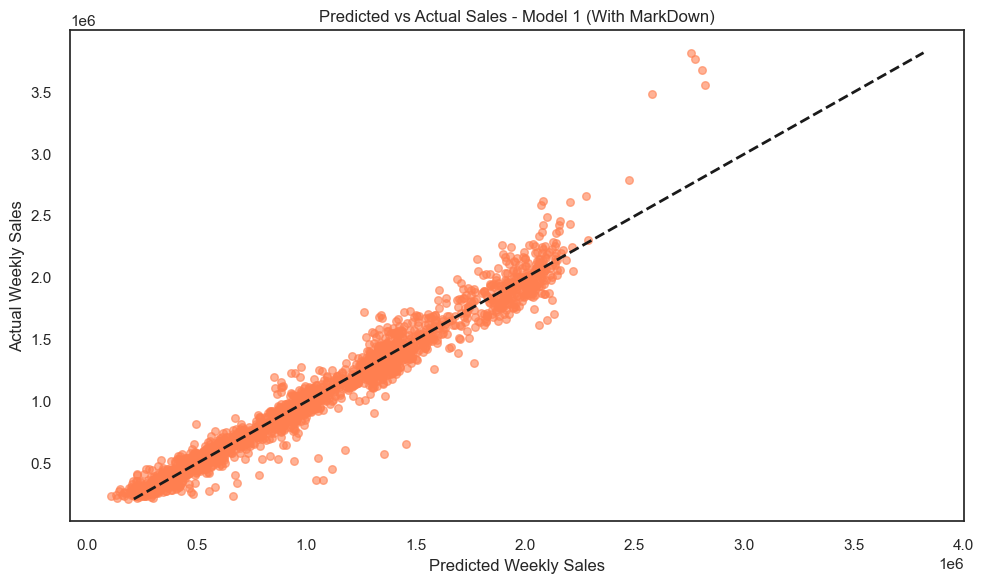


--- Model 2 (Without MarkDown) Results ---
R^2 (Test): 0.9595
R^2 (Train): 0.9626
Adjusted R^2: 0.9587
Cross-validated scores: [0.95598498 0.9585345  0.96479365 0.95605584 0.96546754 0.95788307
 0.95546486 0.95851828 0.96477294 0.96344069]
Mean Cross validation: 0.9601


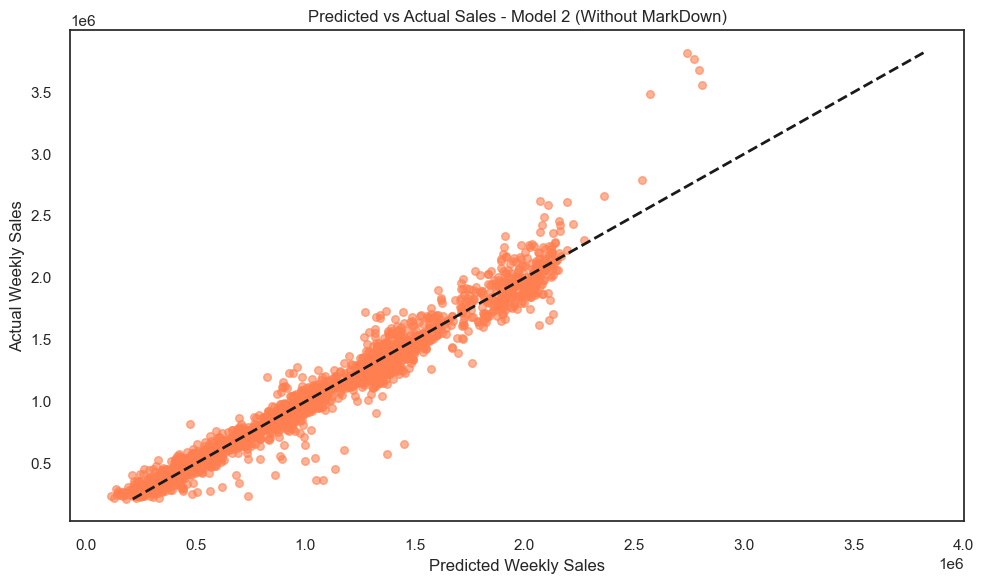

In [60]:
# Function to perform regression and print results
def perform_regression(X, y, model_name):
    ss = StandardScaler()
    Xs = ss.fit_transform(X)
    
    X_train, X_test, y_train, y_test = train_test_split(Xs, y, test_size=0.33, random_state=42)
    
    lr = LinearRegression()
    lr.fit(X_train, y_train)
    
    r2_test = lr.score(X_test, y_test)
    r2_train = lr.score(X_train, y_train)
    
    print(f"\n--- {model_name} Results ---")
    print(f"R^2 (Test): {r2_test:.4f}")
    print(f"R^2 (Train): {r2_train:.4f}")
    
    adj_r2 = 1 - (len(y)-1)/(len(y)-X.shape[1]-1)*(1-r2_test)
    print(f"Adjusted R^2: {adj_r2:.4f}")
    
    # Perform 10-fold cross validation
    scores = cross_val_score(lr, X_train, y_train, cv=10)
    print(f"Cross-validated scores: {scores}")
    print(f"Mean Cross validation: {scores.mean():.4f}")
    
    # Make cross validated predictions on the test set
    predictions = cross_val_predict(lr, X_test, y_test, cv=10)
    
    # Plot predictions vs actual
    plt.figure(figsize=(10, 6))
    plt.scatter(predictions, y_test, s=30, color='crimson' if model_name == 'Model 1' else 'coral', alpha=0.6)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
    plt.xlabel('Predicted Weekly Sales')
    plt.ylabel('Actual Weekly Sales')
    plt.title(f'Predicted vs Actual Sales - {model_name}')
    plt.tight_layout()
    plt.show()

# Model 1: With all predictors including MarkDown
predictors_1 = [col for col in data_imputed.columns if col not in ['Date', 'Weekly_Sales']]
X_1 = data_imputed[predictors_1]
y = data_imputed.Weekly_Sales.values

perform_regression(X_1, y, "Model 1 (With MarkDown)")

# Model 2: Without MarkDown predictors
predictors_2 = [col for col in data_imputed.columns if col not in ['Date', 'Weekly_Sales'] and 'MarkDown' not in col]
X_2 = data_imputed[predictors_2]

perform_regression(X_2, y, "Model 2 (Without MarkDown)")


From the Cross validation we can see that the model with KNN Imputed Markdowns performs slightly better. So, I'm keeping the markdowns.
Normal linear regression also dosen't seem to be very bad.

## TRAINING THE ML MODELS

We will divide our train and test datasets first and then deal with that seperately

In [61]:
# Setting the offset to finalize the test data.
offset = timedelta(days=90)
split_date=data_imputed.Date.max()-offset

In [62]:
data_train = data_imputed[data_imputed.Date < split_date]
data_test = data_imputed[data_imputed.Date >= split_date]

Before we start lets shuffle the dataframe a bit because while we use crossvalidation for regressors it won't take a random sample as test and train, instead it takes section by section. Here my Dataframe have data for each store in order. So if we take section by section model might not have enough data to learn about certain stores and which intern will give terrible answers

In [63]:
data_train = data_train.reindex(np.random.permutation(data_train.index))
data_train.columns

Index(['Date', 'Weekly_Sales', 'Size', 'Temperature', 'Fuel_Price',
       'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5',
       ...
       'Week_42', 'Week_43', 'Week_44', 'Week_45', 'Week_46', 'Week_47',
       'Week_48', 'Week_49', 'Week_50', 'Week_51'],
      dtype='object', length=123)

### ANALYZING OUTLIERS

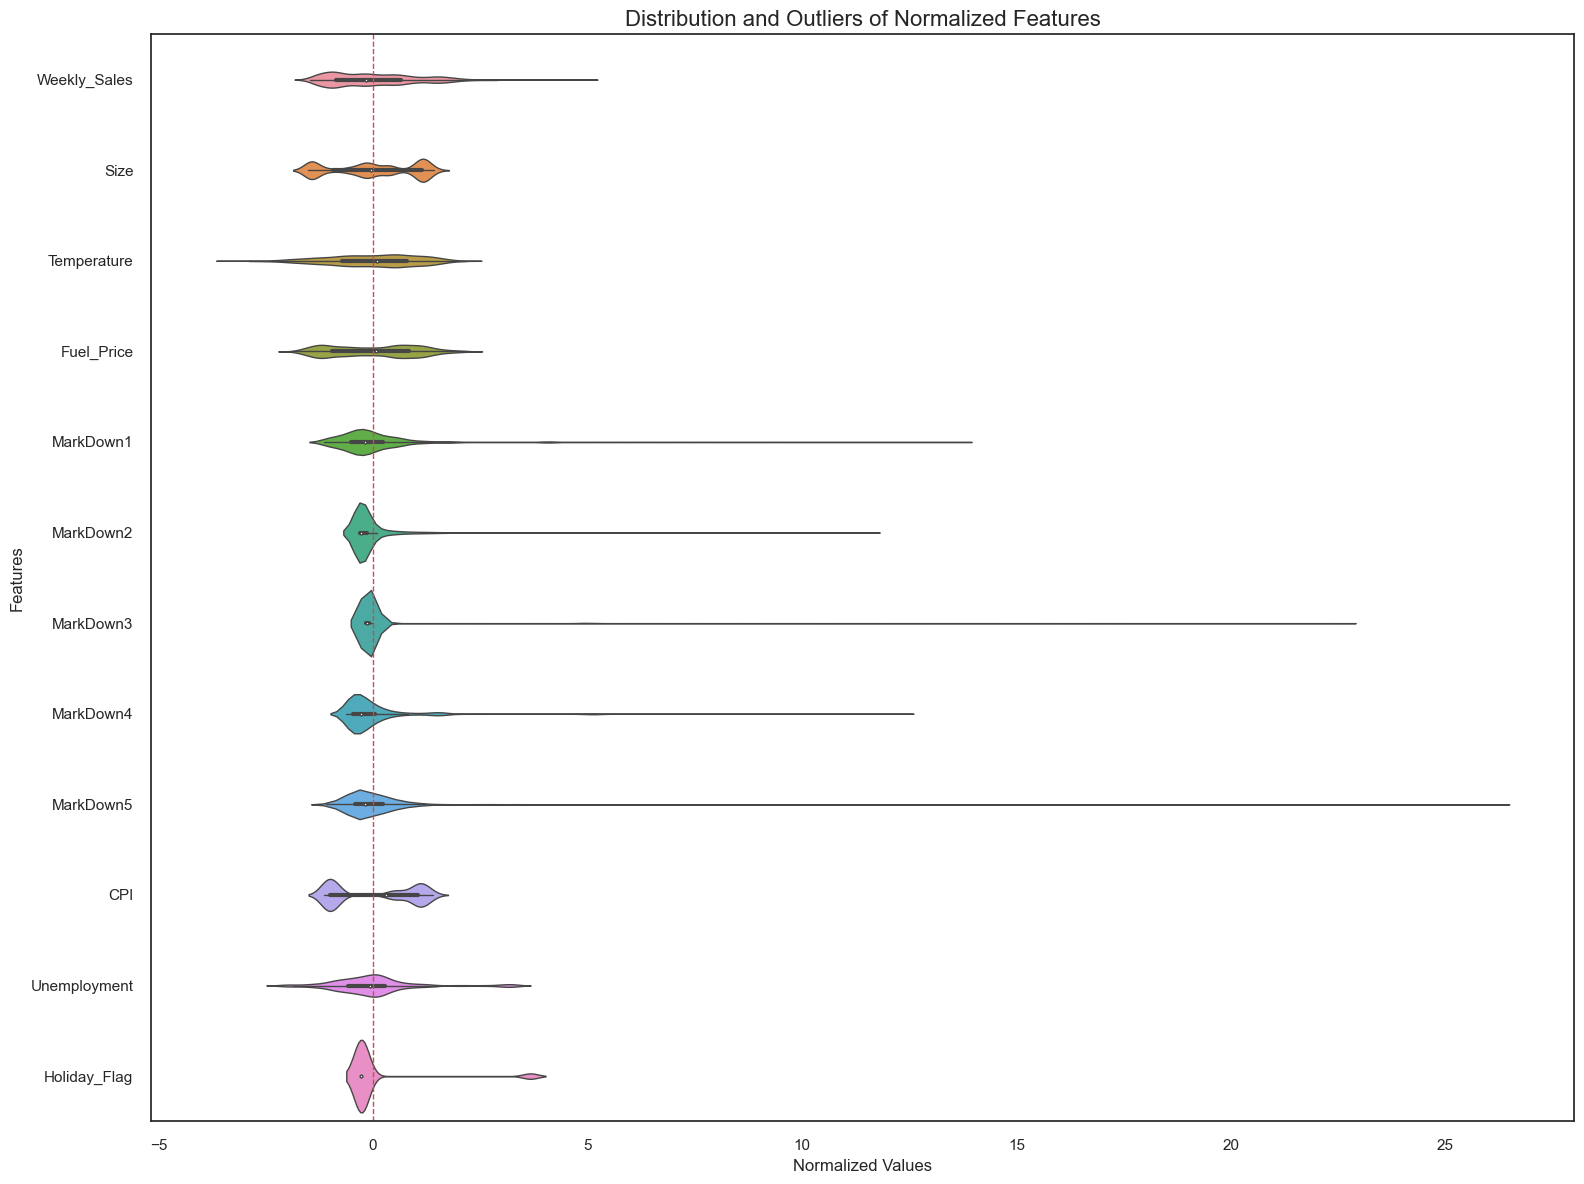


Outliers in Weekly_Sales:
Number of outliers: 34
Percentage of outliers: 0.58%

Outliers in Size:
Number of outliers: 0
Percentage of outliers: 0.00%

Outliers in Temperature:
Number of outliers: 1
Percentage of outliers: 0.02%

Outliers in Fuel_Price:
Number of outliers: 0
Percentage of outliers: 0.00%

Outliers in MarkDown1:
Number of outliers: 328
Percentage of outliers: 5.61%

Outliers in MarkDown2:
Number of outliers: 857
Percentage of outliers: 14.65%

Outliers in MarkDown3:
Number of outliers: 665
Percentage of outliers: 11.37%

Outliers in MarkDown4:
Number of outliers: 537
Percentage of outliers: 9.18%

Outliers in MarkDown5:
Number of outliers: 191
Percentage of outliers: 3.26%

Outliers in CPI:
Number of outliers: 0
Percentage of outliers: 0.00%

Outliers in Unemployment:
Number of outliers: 481
Percentage of outliers: 8.22%

Outliers in Holiday_Flag:
Number of outliers: 405
Percentage of outliers: 6.92%


In [64]:
#Analysing the outliers
# Select numerical columns for analysis
numerical_columns = data_train.select_dtypes(include=[np.number]).columns
data_box = data_train[numerical_columns]

# Normalize the data
data_norm = (data_box - data_box.mean()) / data_box.std()

# Set up the plot
plt.figure(figsize=(16, 12))

# Create violin plots with embedded box plots
sns.violinplot(data=data_norm, orient='h', split=True, inner="box", linewidth=1)

# Customize the plot
plt.title('Distribution and Outliers of Normalized Features', fontsize=16)
plt.xlabel('Normalized Values', fontsize=12)
plt.ylabel('Features', fontsize=12)

# Add a vertical line at x=0 for reference
plt.axvline(x=0, color='r', linestyle='--', linewidth=1)

# Adjust layout and display the plot
plt.tight_layout()
plt.show()

# Calculate and print outlier statistics
for column in data_norm.columns:
    Q1 = data_norm[column].quantile(0.25)
    Q3 = data_norm[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data_norm[(data_norm[column] < lower_bound) | (data_norm[column] > upper_bound)]
    print(f"\nOutliers in {column}:")
    print(f"Number of outliers: {len(outliers)}")
    print(f"Percentage of outliers: {(len(outliers) / len(data_norm)) * 100:.2f}%")


There are quite a lot of outliers in MarkDown 2, 3, 4 followed by unemployement.

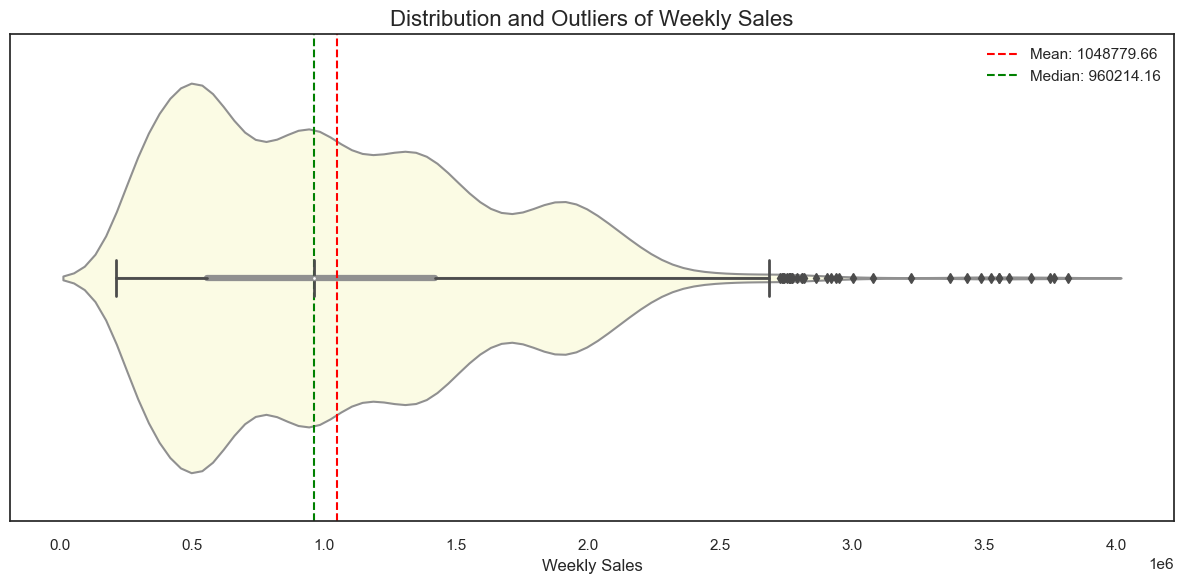

In [65]:
plt.figure(figsize=(12, 6))

# Create a combination of violin plot and box plot
sns.violinplot(x=data_train.Weekly_Sales, orient='h', color='lightyellow')
sns.boxplot(x=data_train.Weekly_Sales, orient='h', width=0.15, color='yellow',
            saturation=0.5, fliersize=5, linewidth=2, notch=True)

# Customize the plot
plt.title('Distribution and Outliers of Weekly Sales', fontsize=16)
plt.xlabel('Weekly Sales', fontsize=12)

# Add vertical lines for mean and median
mean_sales = data_train.Weekly_Sales.mean()
median_sales = data_train.Weekly_Sales.median()
plt.axvline(mean_sales, color='red', linestyle='--', label=f'Mean: {mean_sales:.2f}')
plt.axvline(median_sales, color='green', linestyle='--', label=f'Median: {median_sales:.2f}')
plt.legend()

plt.tight_layout()
plt.show()


In [66]:
# Calculate IQR and outlier bounds
Q1 = data_train.Weekly_Sales.quantile(0.25)
Q3 = data_train.Weekly_Sales.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers = data_train[(data_train.Weekly_Sales < lower_bound) | (data_train.Weekly_Sales > upper_bound)]

# Print outlier statistics
print("\nOutlier Statistics for Weekly Sales:")
print(f"Number of outliers: {len(outliers)}")
print(f"Percentage of outliers: {(len(outliers) / len(data_train)) * 100:.2f}%")
print(f"Minimum Weekly Sales: {data_train.Weekly_Sales.min():.2f}")
print(f"Maximum Weekly Sales: {data_train.Weekly_Sales.max():.2f}")


Outlier Statistics for Weekly Sales:
Number of outliers: 34
Percentage of outliers: 0.58%
Minimum Weekly Sales: 209986.25
Maximum Weekly Sales: 3818686.45


In [67]:
# Since there are only 34 I'm removing those instances
data_train = data_train[(data_train.Weekly_Sales >= lower_bound) & (data_train.Weekly_Sales <= upper_bound)]
print(f"Shape of data_train after removing outliers: {data_train.shape}")

Shape of data_train after removing outliers: (5816, 123)


LETS SEE IF WE CAN MAKE A BETTER MODEL

Since the Linear Regression is working well I am trying to Improve it with Lasso. I will use Lasso Feature Selection and see how our model works with that.

In [68]:
predictors=[col for col in data_train.columns if col not in ['Weekly_Sales','Date']] 


Test-Train Split such that Test data is last 90 days data (future 3 months prediction)

In [69]:
X_train = data_train[predictors]
y_train = data_train.Weekly_Sales.values

X_test = data_test[predictors]
y_test = data_test.Weekly_Sales.values
X_train_s=ss.fit_transform(X_train)
X_test_s=ss.fit_transform(X_test)

### LASSO 

In [70]:
lasso_cv = LassoCV(n_alphas=1000,max_iter=2000, cv=10, verbose=1)
lasso_cv.fit(X_train_s, y_train)

[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.


........................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................

........................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................

LassoCV(cv=10, max_iter=2000, n_alphas=1000, verbose=1)

In [71]:
# Put the features and coefs into a dataframe
# sort by magnitude
lasso_feat = pd.DataFrame(dict(feature=X_train.columns, coef=lasso_cv.coef_, abscoef=np.abs(lasso_cv.coef_)))
lasso_feat.sort_values('abscoef', inplace=True, ascending=False)
# main_features
lasso_feat[lasso_feat.coef != 0.]

,feature,coef,abscoef
0,Size,339669.933247,339669.933247
11,Type_A,194710.340249,194710.340249
21,Store_10,131097.430818,131097.430818
19,Store_8,-96925.493673,96925.493673
44,Store_33,-93945.746032,93945.746032
...,...,...,...
88,Week_19,-487.238508,487.238508
85,Week_16,-363.072461,363.072461
90,Week_21,292.969971,292.969971
112,Week_43,-181.504464,181.504464


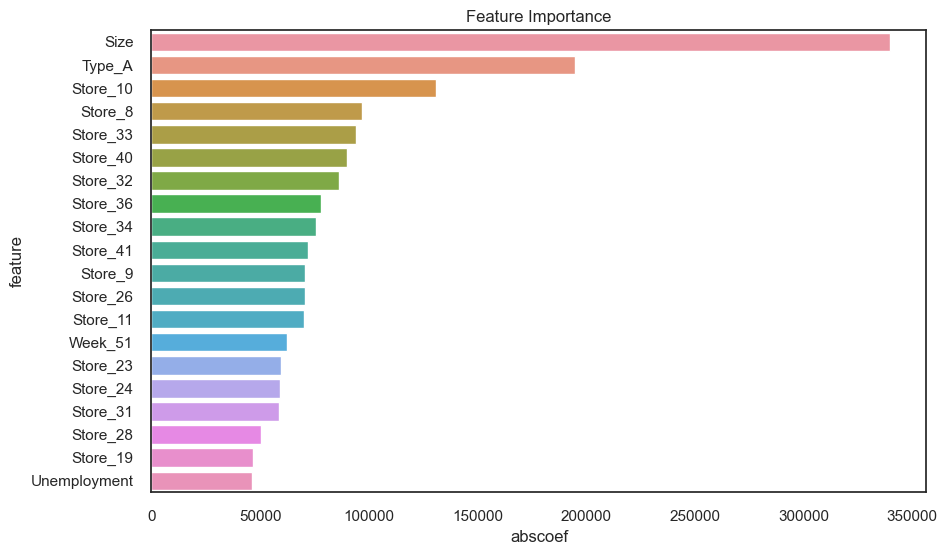

In [72]:
plt.figure(figsize=(10,6))
plt.title('Feature Importance')
sns.barplot(data=lasso_feat.head(20), x='abscoef', y='feature');

The list of features that are seleted and their magnitude of effect on weekly sales can be seen above

Using the predictors that we got from Lasso as our actual predictors and use in further models

In [73]:
actual_predictors=lasso_feat[lasso_feat.coef != 0.].feature.values

In [74]:
# Lets see the best alpha score
lasso_cv.alpha_

#best alpha value is 0.45384197291954748 which could be used later to run model

449.7706304430394

In [75]:
# We will assign the best alpha score and according to that we will train and test our model
best_lasso = Lasso(alpha=lasso_cv.alpha_)
best_lasso.fit(X_train_s, y_train)

Lasso(alpha=449.7706304430394)

In [76]:
lasso_scores = cross_val_score(best_lasso, X_train_s, y_train, cv=10)

print (lasso_scores)
print (np.mean(lasso_scores))

[0.96183599 0.97186561 0.96804761 0.97227681 0.97319094 0.96518482
 0.96659817 0.96253374 0.96376273 0.96576475]
0.9671061154360624


Great!getting a cross validated score of .967 is even better than our previous best model. Now lets use this to predict our last 90 days data.

In [77]:
lasso_yhat=best_lasso.predict(X_test_s)
lasso_score=best_lasso.score(X_test_s, y_test)
print("R2: ",lasso_score)
lasso_adj_r2 = 1 - (len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)*(1-lasso_score)
print("Adjusted R2: ",lasso_adj_r2)

R2:  0.9628219412252059
Adjusted R2:  0.9531058610702381


In [78]:
#The R^2 is slightly better and adjusted R^2 is slightly lesser.

In [79]:
# converting the residuals into the actual dimenssion

train_resids = y_train*1000 - best_lasso.predict(X_train_s)*1000
test_resids = y_test*1000 - lasso_yhat*1000
lasso_residue = np.abs(test_resids).sum()

# Calculate scaled residuals
train_scaled_residual = np.abs(train_resids).sum() / len(y_train)
test_scaled_residual = np.abs(test_resids).sum() / len(y_test)

print(f"Train Residual: ${np.abs(train_resids).sum():.2f}")
print(f"Test Residual: ${lasso_residue:.2f}")
print(f"Scaled Train Residual: ${train_scaled_residual:.2f}")
print(f"Scaled Test Residual: ${test_scaled_residual:.2f}")
print(f"Ratio of Scaled Test Residual to Scaled Train Residual: {test_scaled_residual / train_scaled_residual:.4f}")

Train Residual: $384769904754.91
Test Residual: $40207961318.84
Scaled Train Residual: $66157136.31
Scaled Test Residual: $68731557.81
Ratio of Scaled Test Residual to Scaled Train Residual: 1.0389


The residuals seems to be in same ratio.

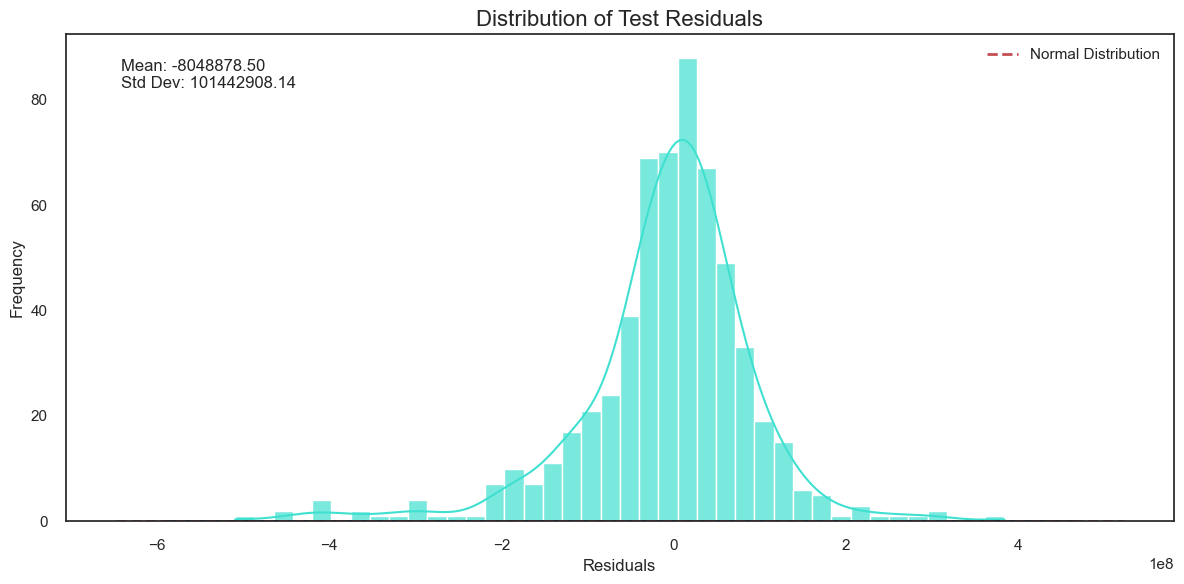

In [80]:

plt.figure(figsize=(12, 6))

# Plot histogram of residuals
sns.histplot(test_resids, kde=True, bins=40, color='turquoise', alpha=0.7)

# Add KDE plot
sns.kdeplot(test_resids, color='darkblue', lw=2)

# Add reference normal distribution
mu, std = stats.norm.fit(test_resids)
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, mu, std)
plt.plot(x, p, 'r--', linewidth=2, label='Normal Distribution')

# Customize the plot
plt.title('Distribution of Test Residuals', fontsize=16)
plt.xlabel('Residuals', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend()

# Add statistical information
plt.text(0.05, 0.95, f'Mean: {np.mean(test_resids):.2f}\nStd Dev: {np.std(test_resids):.2f}', 
         transform=plt.gca().transAxes, verticalalignment='top')

# Show the plot
plt.tight_layout()
plt.show()


#### Quantile-Quantile (Q-Q) Plot:

A Q-Q plot visually compares the distribution of the residuals to a theoretical normal distribution. The closer the points fall to a straight line, the more normally distributed the residuals are.

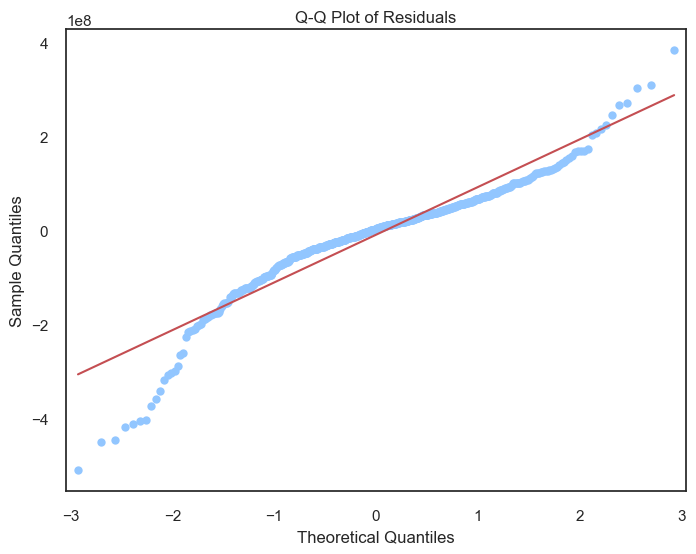

In [81]:
import statsmodels.api as sm
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))
sm.qqplot(test_resids, line='s', ax=ax)
plt.title('Q-Q Plot of Residuals')
plt.show()


From both the previous plots we can see that the residuals are close to decently close to a normal distribution.

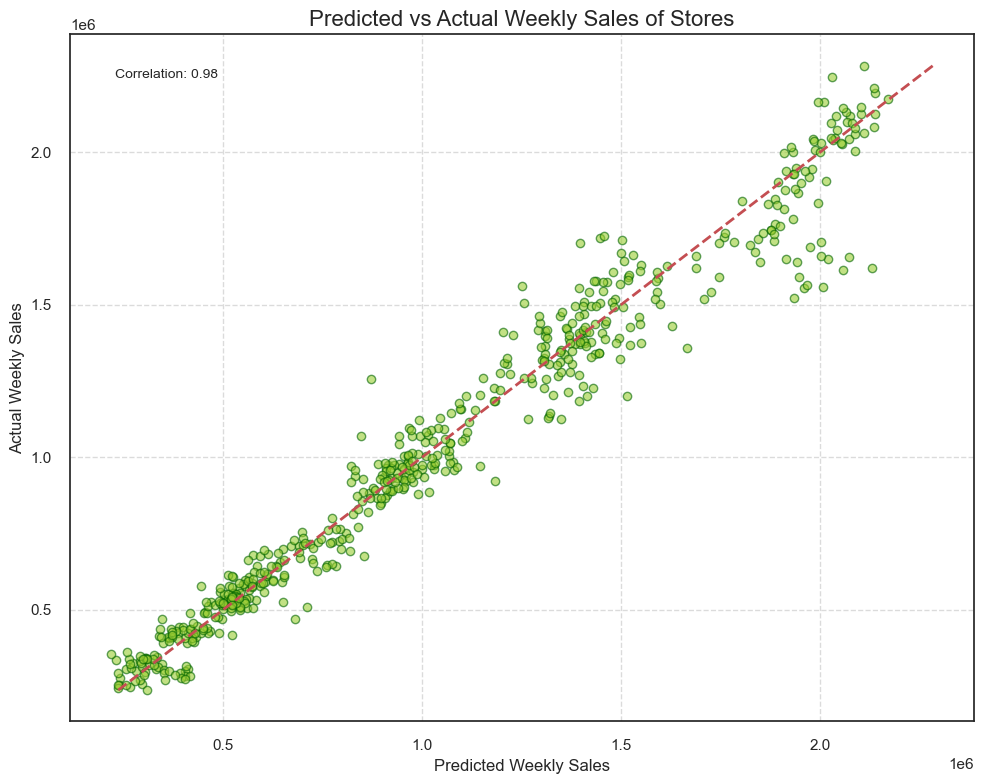

Mean Squared Error: 10355448056.46
R-squared Score: 0.96


In [82]:
fig, ax = plt.subplots(figsize=(10, 8))

# Scatter plot
scatter = ax.scatter(lasso_yhat, y_test, c='yellowgreen', alpha=0.6, edgecolors='darkgreen')

# Add diagonal line
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)

# Customize the plot
ax.set_xlabel('Predicted Weekly Sales', fontsize=12)
ax.set_ylabel('Actual Weekly Sales', fontsize=12)
ax.set_title('Predicted vs Actual Weekly Sales of Stores', fontsize=16)

# Add grid
ax.grid(True, linestyle='--', alpha=0.7)

# Add correlation coefficient
correlation = np.corrcoef(lasso_yhat, y_test)[0, 1]
ax.text(0.05, 0.95, f'Correlation: {correlation:.2f}', transform=ax.transAxes, 
        verticalalignment='top', fontsize=10)

# Adjust layout and display the plot
plt.tight_layout()
plt.show()

# Print additional metrics
from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(y_test, lasso_yhat)
r2 = r2_score(y_test, lasso_yhat)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R-squared Score: {r2:.2f}")


Lasso Model works well giving me a good adjusted R2 and low residual. The residual is also form a normal distribution.

In [83]:
#I'm using the predictors I got from lasso for my next model this reduces the dimensionality
actual_predictors=lasso_feat[lasso_feat.coef != 0.].feature.values

In [84]:
X_train = X_train[actual_predictors]
X_test = X_test[actual_predictors]

X_train_s=ss.fit_transform(X_train)
X_test_s=ss.fit_transform(X_test)

Trying another model

### GRADIENT BOOSTING REGRESSOR

In [85]:
gb = GradientBoostingRegressor(n_estimators=100,max_depth=10,learning_rate=0.1)

In [86]:
gb.fit(X_train_s, y_train)
gb_scores = cross_val_score(gb, X_train_s, y_train, cv=6)
np.mean(gb_scores)

0.9796694490075057

In [87]:
gb_yhat=gb.predict(X_test_s)
gb_score=gb.score(X_test_s,y_test)

print("R2: ",gb_score)
gb_adj_r2 = 1 - (len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)*(1-gb_score)
print("Adjusted R2: ",gb_adj_r2)

R2:  0.9274173783440577
Adjusted R2:  0.9120575704417628


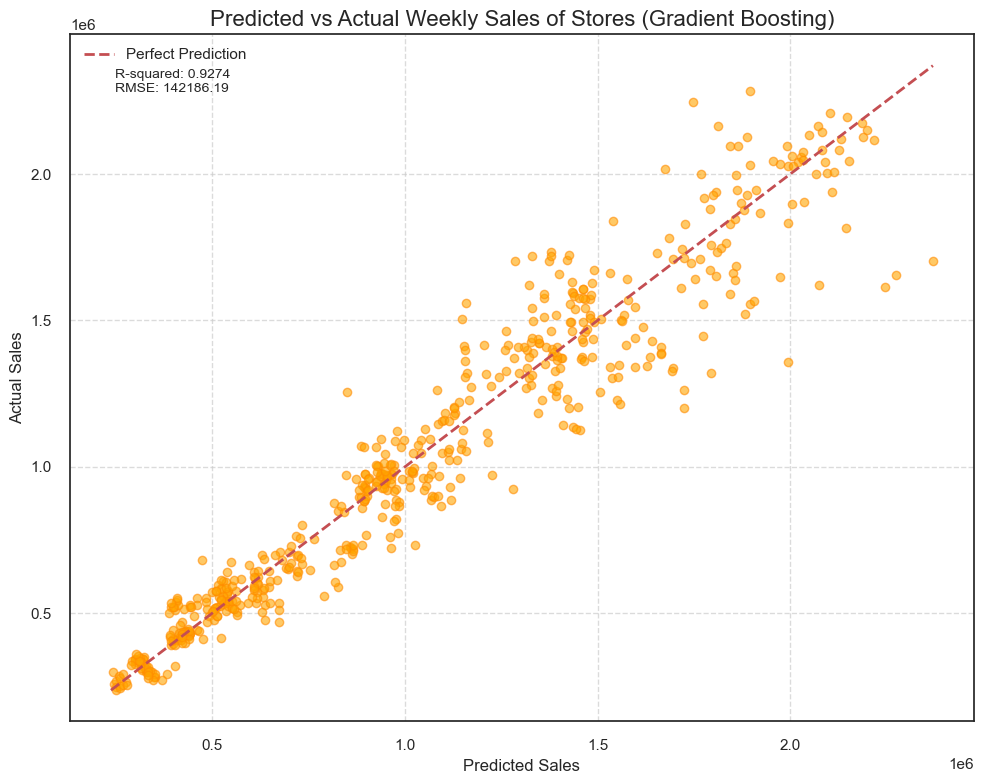

R-squared Score: 0.9274
Root Mean Squared Error: 142186.19


In [88]:
# Create the scatter plot
plt.figure(figsize=(10, 8))
plt.scatter(gb_yhat, y_test, c='orange', alpha=0.6, edgecolors='darkorange')

# Add a diagonal line for perfect predictions
min_val = min(gb_yhat.min(), y_test.min())
max_val = max(gb_yhat.max(), y_test.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')

# Customize the plot
plt.xlabel('Predicted Sales', fontsize=12)
plt.ylabel('Actual Sales', fontsize=12)
plt.title('Predicted vs Actual Weekly Sales of Stores (Gradient Boosting)', fontsize=16)

# Add grid
plt.grid(True, linestyle='--', alpha=0.7)

# Calculate and display R-squared and RMSE
r2 = r2_score(y_test, gb_yhat)
rmse = np.sqrt(mean_squared_error(y_test, gb_yhat))
plt.text(0.05, 0.95, f'R-squared: {r2:.4f}\nRMSE: {rmse:.2f}', transform=plt.gca().transAxes, 
         verticalalignment='top', fontsize=10)

# Add legend
plt.legend()

# Adjust layout and display the plot
plt.tight_layout()
plt.show()

# Print additional metrics
print(f"R-squared Score: {r2:.4f}")
print(f"Root Mean Squared Error: {rmse:.2f}")


In [89]:
train_resids = y_train*1000 - gb.predict(X_train_s)*1000
test_resids = y_test*1000 - gb_yhat*1000
gb_residue = np.abs(test_resids).sum()

# Calculate scaled residuals
train_scaled_residual = np.abs(train_resids).sum() / len(y_train)
test_scaled_residual = np.abs(test_resids).sum() / len(y_test)

print(f"Train Residual: ${np.abs(train_resids).sum():.2f}")
print(f"Test Residual: ${gb_residue:.2f}")
print(f"Scaled Train Residual: ${train_scaled_residual:.2f}")
print(f"Scaled Test Residual: ${test_scaled_residual:.2f}")
print(f"Ratio of Scaled Test Residual to Scaled Train Residual: {test_scaled_residual / train_scaled_residual:.4f}")


Train Residual: $75552916174.12
Test Residual: $56469192213.87
Scaled Train Residual: $12990528.92
Scaled Test Residual: $96528533.70
Ratio of Scaled Test Residual to Scaled Train Residual: 7.4307


Here we can see the model is overfitting as its performing better on training data than test.

So out of both the models the best comes with Lasso regression

## UNDERSTANDING THE PERFORMANCE

In [90]:
Residual_graph=pd.DataFrame()
Residual_graph["Store"]=range(1,46)
Residual_graph['actual_y']=0
Residual_graph['predicted_lasso_y']=0

count=0
for x in y_test:
    count+=1
    Residual_graph['actual_y'][count%45]+=x

count=0
for x in lasso_yhat:
    count+=1
    Residual_graph['predicted_lasso_y'][count%45]+=x  

Residual_graph["actual_y"]=Residual_graph["actual_y"]/13
Residual_graph["predicted_lasso_y"]=Residual_graph["predicted_lasso_y"]/13

Residual_graph["Residual_lasso"]=np.abs(Residual_graph["actual_y"] - Residual_graph["predicted_lasso_y"])
Residual_graph["Residual_lasso_percentage"]=(Residual_graph["Residual_lasso"]/Residual_graph["actual_y"])*100

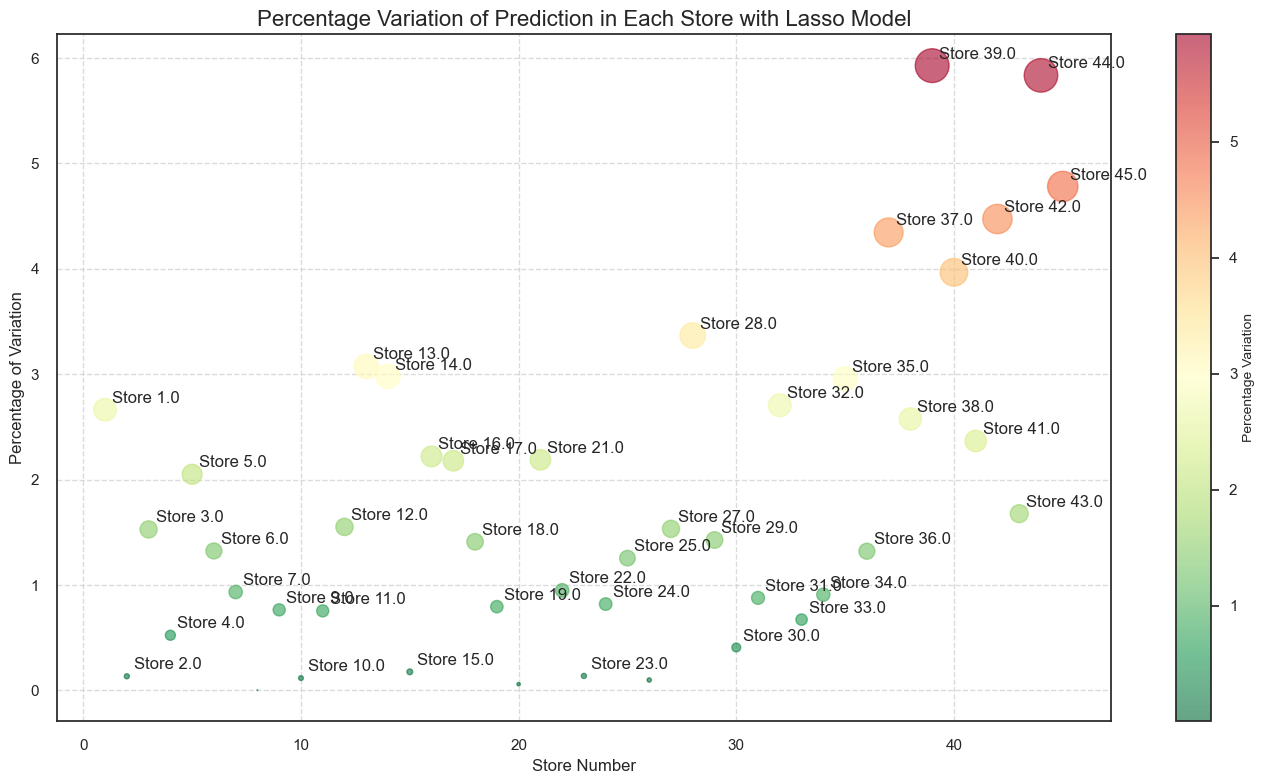

Summary of Percentage Variations:
count    45.000000
mean      1.840705
std       1.535883
min       0.003121
25%       0.765103
50%       1.427366
75%       2.663699
max       5.927532
Name: Residual_lasso_percentage, dtype: float64


In [91]:
fig, ax = plt.subplots(figsize=(14, 8))

# Create bubble plot
scatter = ax.scatter(Residual_graph.Store, 
                     Residual_graph.Residual_lasso_percentage, 
                     s=np.abs(Residual_graph.Residual_lasso_percentage) * 100, 
                     c=Residual_graph.Residual_lasso_percentage, 
                     cmap='RdYlGn_r', 
                     alpha=0.6)

# Customize the plot
ax.set_xlabel('Store Number', fontsize=12)
ax.set_ylabel('Percentage of Variation', fontsize=12)
ax.set_title('Percentage Variation of Prediction in Each Store with Lasso Model', fontsize=16)

# Add colorbar
cbar = plt.colorbar(scatter)
cbar.set_label('Percentage Variation', fontsize=10)

# Add grid
ax.grid(True, linestyle='--', alpha=0.7)

# Annotate some points
for i, row in Residual_graph.iterrows():
    if abs(row.Residual_lasso_percentage) > 0.1:  # Annotate points with >10% variation
        ax.annotate(f'Store {row.Store}', 
                    (row.Store, row.Residual_lasso_percentage),
                    xytext=(5, 5), 
                    textcoords='offset points')

# Adjust layout and display the plot
plt.tight_layout()
plt.show()

# Print summary statistics
print("Summary of Percentage Variations:")
print(Residual_graph.Residual_lasso_percentage.describe())


This plot shows the variation of prediction or the percentage residual change for each store.
Here the bigger the bubble is the higher the variation in prediction. So we can see that stores 39 and 44 have more than 5% variation in prediction( which is the highest).

This can be used to futher improve our model because some other model might be doing good with the store which is doing bad in this model.

## INSIGHTS AND CONCLUSION

From the modeling we have found Lasso method works the best by itself with an ajusted R^2 of ~ 0.96.

I have plotted a percentage residual change with bubbles to check how good is the prediction for each store.This is a good method to look into each store and see which stores are doing good with this model and which are not.


In [92]:
# Create a dataframe to compare different models
Score=pd.DataFrame()
Score["Model_Name"]=('Lasso','GradientBoosting')
Score["Test_Score"]=(lasso_score,gb_score)
Score["Adj_R2"]=(lasso_adj_r2,gb_adj_r2)
Score["Test_Residual"]=(lasso_residue,gb_residue)

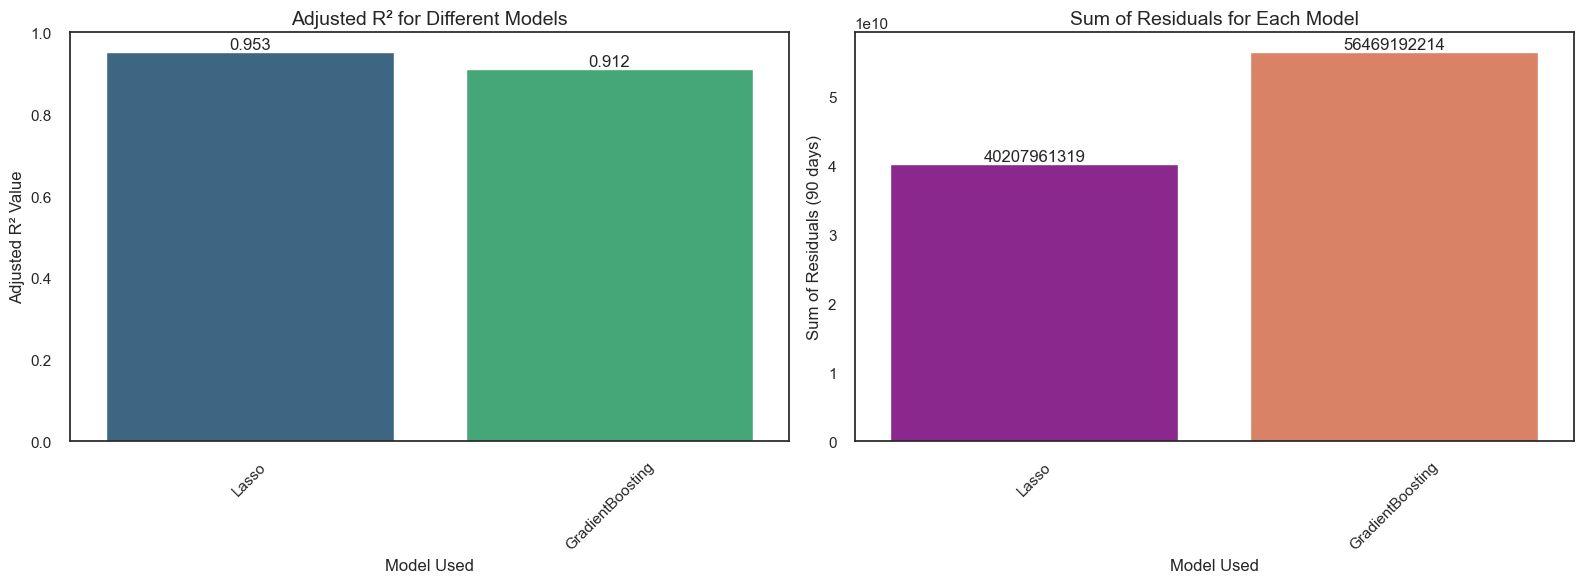

Model Performance Summary:

Lasso:
  Adjusted R²: 0.9531
  Test Residual: 40207961318.84

GradientBoosting:
  Adjusted R²: 0.9121
  Test Residual: 56469192213.87


In [93]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the matplotlib figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot R2 scores
sns.barplot(x="Model_Name", y="Adj_R2", data=Score, ax=ax1, palette='viridis')
ax1.set_xlabel('Model Used', fontsize=12)
ax1.set_ylabel('Adjusted R² Value', fontsize=12)
ax1.set_title('Adjusted R² for Different Models', fontsize=14)
ax1.tick_params(axis='x', rotation=45)

# Add value labels on the bars
for i, v in enumerate(Score['Adj_R2']):
    ax1.text(i, v, f'{v:.3f}', ha='center', va='bottom')

# Plot Residuals
sns.barplot(x="Model_Name", y="Test_Residual", data=Score, ax=ax2, palette='plasma')
ax2.set_xlabel('Model Used', fontsize=12)
ax2.set_ylabel('Sum of Residuals (90 days)', fontsize=12)
ax2.set_title('Sum of Residuals for Each Model', fontsize=14)
ax2.tick_params(axis='x', rotation=45)

# Add value labels on the bars
for i, v in enumerate(Score['Test_Residual']):
    ax2.text(i, v, f'{v:.0f}', ha='center', va='bottom')

# Adjust layout and display the plot
plt.tight_layout()
plt.show()

# Print additional statistics
print("Model Performance Summary:")
for _, row in Score.iterrows():
    print(f"\n{row['Model_Name']}:")
    print(f"  Adjusted R²: {row['Adj_R2']:.4f}")
    print(f"  Test Residual: {row['Test_Residual']:.2f}")


#### Conclusion

Finally, after building multiple models to predict the weekly sales of 45 stores, we got the R^2 of around 0.96 for 3 months(90 Days).

Out of the 2 models, we select the Lasso Regressor as our predictive Model since due to it's highest prediction accuracy with the lowest residual(error). But, Here we saw earlier that linear Regression is performing similar( or maybe even better). Hence, I would prefer the linear regression Model keeping in mind the computational costs.

### Recommendations for the company

- **Optimize Store Layouts**  
  Leverage the insights from store type and size analysis to optimize store layouts. Type A stores, which showed a significant positive coefficient, could serve as a model for other stores to improve sales performance.

- **Implement Dynamic Pricing**  
  Utilize the markdown data to develop a more sophisticated dynamic pricing strategy. This would help in managing inventory more effectively and maximizing revenue during different seasons and events.

- **Focus on High-Performing Stores**  
  Pay special attention to high-performing stores, like Store 10, which showed a strong positive coefficient. Analyze these stores' practices and replicate successful strategies across the chain.

- **Seasonal Adjustments**  
  Use insights from weekly sales patterns to adjust inventory, staffing, and marketing efforts according to seasonal trends. This could help in better resource allocation throughout the year.

- **Economic Indicator Monitoring**  
  Closely monitor economic indicators such as CPI and unemployment rates, as they have shown to impact sales. This can help in proactive decision-making and strategy adjustments.


### Improvements and Extensions for the Analysis

- **Time Series Forecasting**  
  Implement more advanced time series models such as ARIMA or Prophet to capture complex temporal patterns in the sales data.

- **Machine Learning Integration**  
  Explore ensemble methods or deep learning models to potentially improve prediction accuracy. Consider using techniques like XGBoost or LSTM networks for sales forecasting.

- **Feature Engineering**  
  Develop more sophisticated features, such as lagged variables or rolling averages, to capture more complex relationships in the data.

- **Granular Analysis**  
  Conduct department-level analysis to understand which product categories drive sales in different store types and regions.

- **External Data Integration**  
  Incorporate additional external data sources such as local events, weather patterns, or competitor actions to enhance the predictive power of your models.


## REFRENCES

https://medium.datadriveninvestor.com/walmart-sales-data-analysis-sales-prediction-using-multiple-linear-regression-in-r-programming-adb14afd56fb

Other projects related to this data set on kaggle : https://www.kaggle.com/competitions/walmart-recruiting-store-sales-forecasting/code